# DIMER Guided Notebook: Can Synthetic Defects Improve Visual Inspection?

**Profile:** `E2E` · **Mode:** `GUIDED` · **Notebook spec:** DIMER Notebook Specification 2.2 · **Status:** candidate (the combined Colab T4 run has not yet been recorded)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/flux-schnell-generation-pipeline/blob/main/tutorials/DIMER_Bosch_Synthetic_Defect_Augmentation_Capstone.ipynb)

This notebook runs a controlled experiment. You will take a small, fixed set of labelled photographs of manufactured surfaces from the Bosch Surface Defect Inspection (SDI) dataset, ask **Phi-4-multimodal-instruct** to describe what it sees, compile those descriptions into bounded text prompts, let **FLUX.1 [schnell]** generate candidate *scratch* and *spot* images from the prompts, and then test whether substituting those generated images into training improves a simple classifier on **real held-out photographs**, compared with conventional augmentation.

Success means a reproducible, interpretable comparison. A negative or null result is a valid outcome: the notebook does not require the synthetic images to help.

**Run all:** the default path downloads and verifies the dataset, audits it, freezes a grouped split, fits a majority baseline and a real-only classifier, describes training exemplars with Phi-4, generates 64 candidates with FLUX, fits three matched classifier arms with three seeds, freezes the experiment, scores the real test set once, exports the selected classifier, and rebuilds it in a fresh process to prove the export reproduces the same outputs. It needs no token, login, upload, restart, repository clone or DIMER service.

**Bring Your Own Data:** after the sample run, you can repeat the whole experiment on your own labelled images (Section 13). The same validation, split, generation, fitting, evaluation and export stages apply.

**By the end of this notebook you will be able to:**

- **explain** why accuracy misleads under class imbalance and **compare** classifiers with macro-F1;
- **identify** which parts of a model-written description are observed and which are guessed;
- **distinguish** a generated image's *intended* label from a verified annotation, and visual plausibility from measured usefulness;
- **diagnose** leakage risks: duplicate images across partitions, test-set peeking, and unequal training budgets;
- **interpret** a paired contrast between augmentation strategies with its bootstrap interval, per seed and on average;
- **apply** the same protocol to your own data and **write** a conclusion that stays within the evidence.

**This notebook does not demonstrate:** defect localisation or masks, dimensional measurement, material or severity inference, fine-tuning of Phi-4 or FLUX, physical defect simulation, certification, or a production inspection system. FLUX generates new images from text; it does not edit a supplied specimen and does not guarantee a physically valid defect.


## Before you start

**Who this is for.** You can open a Colab notebook, run cells, and read basic Python. You have met image classification before. Class imbalance, augmentation, held-out evaluation and macro-F1 are introduced here. The dataset is an international manufacturing dataset; any local relevance is by analogy, not because it contains Philippine observations.

**Runtime.** A Colab **T4 GPU** runtime (Runtime → Change runtime type → T4 GPU) with at least 15 GB of GPU memory. The runtime check in Section 1 stops with an instruction if no suitable GPU is attached.

**Resource budget (estimates, not measurements).** About 53 GB of downloads (dataset 1.6 GB, Phi-4 11.2 GB, FLUX 33.7 GB, ResNet-18 0.05 GB, Python wheels about 6 GB) and about 55 GB of free disk with the default of deleting each model's weights after use. Model time is expected to be well under 90 minutes on a T4, excluding downloads. The notebook measures and records the actual download bytes, stage times, peak host memory and peak GPU memory; a later hosted run replaces these estimates.

### How to use this notebook

1. Select the T4 runtime, then choose **Runtime → Run all**. Nothing needs editing.
2. Cells titled **Infrastructure: …** set up environments, locks and helpers. Run them; you do not need to study them. Cells that begin with `%%writefile` save a stage script into `work/sdi_capstone/`; the *next* code cell runs it. The scripts are the experiment's actual logic, so read the ones a section discusses.
3. Form fields (the configuration cell in Section 1) are the only values you might change, and only for the optional activities. Every field has a safe default.
4. Each stage prints what it did. After each stage, read **What to notice**, answer the **Check your reasoning** question, then open the sample answer.
5. Outputs go to `outputs/bosch_sdi_capstone/` (or `outputs/byod_capstone/` for your own data). Nothing is uploaded anywhere.

### Why two Python environments?

Phi-4-multimodal needs `transformers 4.48.2` and `torch 2.6`; the FLUX pipeline needs `transformers 5.17`, `diffusers 0.40` and `torch 2.14`. They cannot share one interpreter. Section 1 creates two isolated environments from exact dependency locks, and each heavy stage runs as a separate process in the right environment. A process that exits returns all of its GPU and host memory, which is also how the notebook keeps Phi-4, the FLUX text encoders, the FLUX transformer and the feature extractor from ever occupying the GPU together.


## Roadmap

| § | Stage | Kind |
|---|---|---|
| 1 | Runtime check, locked environments, shared core | infrastructure |
| 2 | Dataset card, acquisition, digest verification, quality audit, frozen grouped split | data practice |
| 3 | Majority baseline and a real-only classifier (validation only) | core concept |
| 4 | Phi-4 descriptions of training exemplars: observed versus guessed | core concept |
| 5 | Bounded prompt compilation | engineering |
| 6 | FLUX generation, contact sheets, intended labels | core concept |
| 7 | Synthetic features and the synthetic-to-training audit | evaluation practice |
| 8 | Three matched arms, validation selection, frozen experiment | evaluation practice |
| 9 | One final real-test comparison | evaluation practice |
| 10 | Error analysis, uncertainty and an evidence-based conclusion | interpretation |
| 11 | Export, fresh-process reload parity, new-image inference | engineering |
| 12 | Records: environment, run summary, limitations, attribution | engineering |
| 13 | Optional: change one thing, human review, bring your own data, troubleshooting | optional |

**Fast path.** If you are short of time, run everything and read Sections 3, 6, 9 and 10.


## The question, and your prediction

> Under a fixed real-data budget, classifier, class-sampling policy and training budget, does substituting synthetic defect examples into training improve **real-test macro-F1** compared with conventional augmentation?

The experiment trains a small classifier on top of frozen image features in three **arms**, each with the same number of optimiser updates, the same batch composition and the same random draws per seed:

| Arm | Training source | Purpose |
|---|---|---|
| Majority baseline | always predicts `normal` | shows why accuracy misleads under imbalance |
| **A** real-only | 128 normal, 64 scratch, 32 spot real images, unaugmented | reference classifier |
| **B** conventional augmentation | the same real images, each drawn as one of four fixed flip/brightness/contrast views | primary practical comparator |
| **C** synthetic augmentation | as B, but each defect slot draws a generated image with probability 0.5 | tests the generated pool |

The **primary contrast is C − B**; B − A is context.

**Make a prediction now, before any model runs.** Write down (1) whether C − B will be positive, zero or negative, (2) roughly how large, and (3) which class you expect synthetic images to help most. You will compare against the evidence in Section 10.

### Input → System → Output

```
labelled Bosch training images (product A: normal / scratches / spots)
   │  audit, group duplicates, freeze a 60/20/20 grouped split, pick 128/64/32 training images
   ├─► Phi-4-multimodal (frozen, 4-bit) ─► descriptions of 3 exemplars per class
   │        └─► deterministic, bounded prompt template ─► 6 prompts
   │                 └─► FLUX.1 [schnell] (frozen, 4-bit) ─► 32 candidates per defect class (intended labels)
   ├─► ResNet-18 (frozen, ImageNet) ─► 512-d features for real + synthetic images
   └─► linear head fitted per arm × seed ─► validation selects epochs ─► FREEZE
                                             └─► real test photographs, scored once
Output: per-image predictions, macro-F1 per arm/seed, paired C − B contrast with a bootstrap interval,
        an exported classifier that a fresh process reproduces, and an evidence record.
```

**Two ideas carry the whole notebook.** First, a generated image's label is *intended* (it is the label in the prompt), not verified by anyone. Second, only held-out *real* photographs can say whether generated images were useful; how realistic they look is a different question.


<details><summary><b>Glossary (open when a term is unfamiliar)</b></summary>

- **Class imbalance** — one class (here `normal`, about 93% of images) vastly outnumbers others. A classifier that always says `normal` scores high accuracy while finding no defects.
- **Macro-F1** — compute F1 (the harmonic mean of precision and recall) separately for each class, then average the classes with equal weight. A missed rare class hurts it as much as a missed common one (Sokolova & Lapalme, 2009).
- **Balanced accuracy** — the average of per-class recall.
- **Augmentation** — label-preserving transformations of training images (here: horizontal flip, mild brightness and contrast) that add variation without new photographs.
- **Synthetic augmentation** — adding generated images to training (Trabucco et al., 2023; Wang et al., 2023).
- **Intended label** — the class named in the prompt that produced a generated image. Nobody has checked that the image shows that defect.
- **Held-out evaluation** — scoring on images that were never used for fitting or for any choice. **Validation** images are used for choices (epoch, exported arm); **test** images are used once, after everything is frozen.
- **Group / leakage** — near-identical images (duplicates, consecutive frames) must stay in the same partition; otherwise the test set contains near-copies of training images and scores are inflated.
- **Frozen features / linear head** — ResNet-18 (He et al., 2016), pretrained on ImageNet (Deng et al., 2009), turns each image into a 512-number vector and is never updated. Only a small linear layer (3 × 512 weights + 3 biases) is fitted.
- **NF4 / 4-bit** — a 4-bit weight format that lets Phi-4 and FLUX fit a 16 GB GPU (Dettmers et al., 2023). Every number from these models is the 4-bit model's.
- **Seed** — the number that fixes random draws. Three seeds show how much results move for reasons unrelated to the method.
- **Paired group bootstrap** — resample the test groups with replacement many times, re-score every arm on each resample, and read the spread of the C − B difference (Efron & Tibshirani, 1993).

</details>


## 1 · Runtime, locked environments and the shared core  <sub>(infrastructure)</sub>

The configuration cell holds every value a reader can change. The defaults run the canonical experiment; the optional fields are explained in Section 13. The Phi-4 checkpoint ships its model code as Python files inside the model repository, which `transformers` executes. `ALLOW_PHI4_REMOTE_CODE` is set to `True` so that Run all proceeds; that code is pinned to one immutable revision and each file's SHA-256 is verified before it is imported (Section 4 explains the boundary). Set it to `False` to stop before Phi-4 runs.

**BYOD contract (read before choosing `byod`).** A zip containing `manifest.csv` with columns `image_id`, `path`, `class` and optional `group`, plus the images (`.jpg`, `.jpeg`, `.png`, sides 64–4096 px). Exactly three classes: one named `normal` and two defect classes (lowercase names such as `dent`, `stain`). Paths are relative to the manifest, without `..`. A `group` (for example a specimen or session id) must never span two classes. After grouping, each class needs at least 128 / 64 / 32 independent training groups (normal / more frequent defect / less frequent defect) and at least 5 images in each of validation and test. Data stays inside this runtime; the only transmission is the images you upload to the runtime yourself. **Do not upload confidential, restricted, personal or regulated images unless you are authorised to process them in Colab.**


In [1]:
# @title Configuration: form fields (the defaults run the canonical experiment)
DATA_SOURCE = 'bosch'  # @param ["bosch", "byod"]
BYOD_ZIP_PATH = ''  # @param {type:"string"}
NEW_IMAGE_DIR = ''  # @param {type:"string"}
ALLOW_PHI4_REMOTE_CODE = True  # @param {type:"boolean"}
SEEDS = '17,29,43'  # @param {type:"string"}
DELETE_MODEL_WEIGHTS_AFTER_USE = True  # @param {type:"boolean"}
RUN_SYNTHETIC_FRACTION_EXERCISE = True  # @param {type:"boolean"}
EXERCISE_SYNTHETIC_PROBABILITY = 0.25  # @param {type:"number"}
RUN_HUMAN_REVIEW_EXTENSION = False  # @param {type:"boolean"}
HUMAN_REVIEW_CSV = ''  # @param {type:"string"}
BYOD_CHECK_ZIP = ''  # @param {type:"string"}

import json
import time
from pathlib import Path

NOTEBOOK_STARTED = time.time()
BASE = Path.cwd()
WORK_ROOT = BASE / 'work' / 'sdi_capstone'  # scripts, locks, environments (shared by both data sources)
WORK = WORK_ROOT / DATA_SOURCE  # data, weights, features and heads for this data source
OUT = BASE / 'outputs' / ('bosch_sdi_capstone' if DATA_SOURCE == 'bosch' else 'byod_capstone')
for folder in (WORK_ROOT / 'locks', WORK / 'state', OUT / 'figures'):
    folder.mkdir(parents=True, exist_ok=True)
if DATA_SOURCE not in ('bosch', 'byod'):
    raise ValueError("DATA_SOURCE must be 'bosch' or 'byod'")
seeds = [int(s) for s in SEEDS.replace(' ', '').split(',') if s]
if not seeds or len(set(seeds)) != len(seeds):
    raise ValueError('SEEDS must be distinct integers separated by commas, for example 17,29,43')
if DATA_SOURCE == 'byod':
    print('BYOD: images stay in this runtime. Do not upload confidential, restricted, personal or regulated data '
          'unless you are authorised to process it here.')
    if not BYOD_ZIP_PATH:
        from google.colab import files  # optional interactive branch; the default path never reaches this line

        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError('upload exactly one zip file (manifest.csv + images)')
        BYOD_ZIP_PATH = str(WORK / 'byod_upload.zip')
        Path(BYOD_ZIP_PATH).write_bytes(next(iter(uploaded.values())))
RUN_CONFIG = WORK / 'run_config.json'
RUN_CONFIG.write_text(json.dumps({
    'base_dir': str(BASE), 'work_dir': str(WORK), 'out_dir': str(OUT), 'data_source': DATA_SOURCE,
    'byod_zip': BYOD_ZIP_PATH, 'new_image_dir': NEW_IMAGE_DIR, 'seeds': seeds,
    'allow_phi4_remote_code': bool(ALLOW_PHI4_REMOTE_CODE),
    'delete_model_weights_after_use': bool(DELETE_MODEL_WEIGHTS_AFTER_USE), 'delete_archive_after_extract': True,
}, indent=2))
print(f'data source: {DATA_SOURCE}; seeds: {seeds}' + ('' if len(seeds) >= 3 else ' (fewer than three seeds: a SMOKE run, not the canonical comparison)'))
print(f'working files: {WORK}\noutputs: {OUT}')


data source: bosch; seeds: [17, 29, 43]
working files: /content/work/sdi_capstone/bosch
outputs: /content/outputs/bosch_sdi_capstone


The runtime check records the GPU, driver, host memory and free disk, and stops early with an instruction if the run cannot fit.


In [2]:
# @title Infrastructure: runtime check (GPU, disk, host memory)
import platform
import shutil
import subprocess


def _smi(query):
    try:
        result = subprocess.run(['nvidia-smi', f'--query-gpu={query}', '--format=csv,noheader,nounits'], capture_output=True, text=True, timeout=30)
    except (OSError, subprocess.TimeoutExpired):
        return ''
    return result.stdout.strip().splitlines()[0] if result.returncode == 0 and result.stdout.strip() else ''


with open('/proc/meminfo') as handle:
    MEMINFO = {line.split(':')[0]: int(line.split()[1]) for line in handle}
REQUIRED_DISK_GB = 55 if DELETE_MODEL_WEIGHTS_AFTER_USE else 70
RUNTIME = {
    'python_kernel': platform.python_version(),
    'platform': platform.platform(),
    'gpu': _smi('name') or 'none',
    'gpu_memory_mib': int(_smi('memory.total') or 0),
    'driver': _smi('driver_version') or 'none',
    'host_memory_gib': round(MEMINFO['MemTotal'] / 2**20, 1),
    'disk_free_gb_at_start': round(shutil.disk_usage(BASE).free / 1e9, 1),
    'required_disk_gb': REQUIRED_DISK_GB,
}
print(json.dumps(RUNTIME, indent=2))
if RUNTIME['gpu_memory_mib'] < 15000:
    raise RuntimeError('This notebook needs a CUDA GPU with at least 15 GB. In Colab: Runtime > Change runtime type > T4 GPU, then Run all again.')
if RUNTIME['disk_free_gb_at_start'] < REQUIRED_DISK_GB:
    raise RuntimeError(f"Only {RUNTIME['disk_free_gb_at_start']} GB of disk is free; the run needs about {REQUIRED_DISK_GB} GB. Start a fresh runtime (Runtime > Disconnect and delete runtime) and Run all again.")
if RUNTIME['host_memory_gib'] < 12:
    print('WARNING: less than 12 GiB of host memory; the 4-bit model loads may run out of memory (see Troubleshooting).')


{
  "python_kernel": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "gpu": "Tesla T4",
  "gpu_memory_mib": 15360,
  "driver": "580.82.07",
  "host_memory_gib": 12.7,
  "disk_free_gb_at_start": 202.2,
  "required_disk_gb": 55
}


Both environments are created from exact locks: every transitive package is pinned, and `uv` installs with `--no-deps`, so nothing floats. Reruns reuse an environment whose lock digest matches.


In [3]:
# @title Infrastructure: exact dependency locks (every transitive package pinned)
# Resolved with `uv pip compile` for CPython 3.12 on x86_64 manylinux from tools/capstone/locks/*.in.
# The lab lock takes torch/torchvision from the CUDA 12.6 wheel index (these run on any CUDA 12.x or newer driver).
LOCKS = {
    'lab': """
accelerate==1.15.0
annotated-doc==0.0.5
anyio==4.15.1
bitsandbytes==0.50.2
certifi==2026.7.22
charset-normalizer==3.5.1
click==8.5.0
contourpy==1.4.0
cuda-bindings==12.9.9
cuda-pathfinder==1.8.2
cuda-toolkit==12.6.3
cycler==0.12.1
diffusers==0.40.0
filelock==4.0.5
fonttools==4.66.0
fsspec==2026.9.0
h11==0.16.0
hf-xet==1.6.0
httpcore==1.0.9
httpx==0.28.1
huggingface-hub==1.32.0
idna==3.20
importlib-metadata==9.0.1
jinja2==3.1.6
kiwisolver==1.5.1
markdown-it-py==4.2.0
markupsafe==3.0.3
matplotlib==3.11.2
mdurl==0.1.2
mpmath==1.3.0
networkx==3.7
numpy==2.5.3
nvidia-cublas-cu12==12.6.4.1
nvidia-cuda-cupti-cu12==12.6.80
nvidia-cuda-nvrtc-cu12==12.6.85
nvidia-cuda-runtime-cu12==12.6.77
nvidia-cudnn-cu12==9.10.2.21
nvidia-cufft-cu12==11.3.0.4
nvidia-cufile-cu12==1.11.1.6
nvidia-curand-cu12==10.3.7.77
nvidia-cusolver-cu12==11.7.1.2
nvidia-cusparse-cu12==12.5.4.2
nvidia-cusparselt-cu12==0.7.1
nvidia-nccl-cu12==2.29.3
nvidia-nvjitlink-cu12==12.9.86
nvidia-nvshmem-cu12==3.4.5
nvidia-nvtx-cu12==12.6.77
packaging==26.3
pillow==11.3.0
protobuf==7.36.2
psutil==7.2.2
pygments==2.21.0
pyparsing==3.3.3
python-dateutil==2.9.0.post0
pyyaml==6.0.3
regex==2026.9.10
requests==2.34.2
rich==15.0.0
safetensors==0.8.0
sentencepiece==0.2.2
setuptools==84.0.0
shellingham==1.5.4
six==1.17.0
sympy==1.14.0
tokenizers==0.23.2
torch==2.14.0+cu126
torchvision==0.29.0+cu126
tqdm==4.70.1
transformers==5.17.0
triton==3.8.0
typer==0.27.2
typing-extensions==4.16.0
urllib3==2.8.0
zipp==4.1.0
""",
    'phi4': """
accelerate==1.3.0
backoff==2.2.1
bitsandbytes==0.45.5
certifi==2026.7.22
cffi==2.1.1
charset-normalizer==3.5.1
filelock==4.0.5
fsspec==2026.9.0
hf-xet==1.6.0
huggingface-hub==0.36.2
idna==3.20
jinja2==3.1.6
markupsafe==3.0.3
mpmath==1.3.0
networkx==3.7
numpy==1.26.4
nvidia-cublas-cu12==12.4.5.8
nvidia-cuda-cupti-cu12==12.4.127
nvidia-cuda-nvrtc-cu12==12.4.127
nvidia-cuda-runtime-cu12==12.4.127
nvidia-cudnn-cu12==9.1.0.70
nvidia-cufft-cu12==11.2.1.3
nvidia-curand-cu12==10.3.5.147
nvidia-cusolver-cu12==11.6.1.9
nvidia-cusparse-cu12==12.3.1.170
nvidia-cusparselt-cu12==0.6.2
nvidia-nccl-cu12==2.21.5
nvidia-nvjitlink-cu12==12.4.127
nvidia-nvtx-cu12==12.4.127
packaging==26.3
peft==0.13.2
pillow==11.1.0
psutil==7.2.2
pycparser==3.0
pyyaml==6.0.3
regex==2026.9.10
requests==2.34.2
safetensors==0.5.3
scipy==1.15.2
setuptools==84.0.0
soundfile==0.13.1
sympy==1.13.1
tokenizers==0.21.4
torch==2.6.0
torchaudio==2.6.0
torchvision==0.21.0
tqdm==4.70.1
transformers==4.48.2
triton==3.2.0
typing-extensions==4.16.0
urllib3==2.8.0
""",
}
for _name, _text in LOCKS.items():
    (WORK_ROOT / 'locks' / f'{_name}.lock').write_text(_text.strip() + '\n')
print({name: len(text.split()) for name, text in LOCKS.items()}, 'pinned packages')


{'lab': 74, 'phi4': 51} pinned packages


In [4]:
# @title Infrastructure: create the two locked environments (about 5-8 minutes on first run)
import hashlib
import sys
import sysconfig

UV_VERSION = '0.12.19'
PYTHON_REQUEST = '3.12'
INDEX_ARGS = {
    'lab': ['--index-url', 'https://download.pytorch.org/whl/cu126', '--extra-index-url', 'https://pypi.org/simple', '--index-strategy', 'unsafe-best-match'],
    'phi4': ['--index-url', 'https://pypi.org/simple'],
}
PROBE = """
import importlib.metadata as md, json, platform, sys
out = {'python': platform.python_version()}
for d in ('torch', 'torchvision', 'transformers', 'diffusers', 'bitsandbytes', 'accelerate', 'peft', 'huggingface-hub', 'safetensors', 'numpy', 'pillow', 'matplotlib'):
    try:
        out[d] = md.version(d)
    except md.PackageNotFoundError:
        pass
import torch
out['cuda_available'] = torch.cuda.is_available()
out['torch_cuda'] = torch.version.cuda
out['device'] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'
print(json.dumps(out))
"""
# uv is a standalone installer binary; installing it does not touch any module this kernel has loaded.
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', f'uv=={UV_VERSION}'], check=True)
UV = shutil.which('uv') or str(Path(sysconfig.get_path('scripts')) / 'uv')
ENV_PYTHON, ENVIRONMENTS = {}, {}
for name in ('lab', 'phi4'):
    lock = WORK_ROOT / 'locks' / f'{name}.lock'
    root = WORK_ROOT / 'envs' / name
    python = root / 'bin' / 'python'
    digest = hashlib.sha256(lock.read_bytes()).hexdigest()
    marker = root / '.lock_sha256'
    started = time.time()
    if not (python.exists() and marker.exists() and marker.read_text() == digest):
        shutil.rmtree(root, ignore_errors=True)
        subprocess.run([UV, 'venv', '--quiet', '--python', PYTHON_REQUEST, str(root)], check=True)
        subprocess.run([UV, 'pip', 'install', '--quiet', '--python', str(python), '--no-deps', '--no-cache', '--link-mode', 'copy', '-r', str(lock), *INDEX_ARGS[name]], check=True)
        marker.write_text(digest)
    probe = json.loads(subprocess.run([str(python), '-c', PROBE], capture_output=True, text=True, check=True).stdout)
    if not probe['cuda_available']:
        raise RuntimeError(f"the {name} environment cannot see the GPU (torch {probe['torch']}, CUDA {probe['torch_cuda']}, driver {RUNTIME['driver']}); see Troubleshooting")
    ENVIRONMENTS[name] = {**probe, 'lock_sha256': digest, 'uv': UV_VERSION, 'install_seconds': round(time.time() - started, 1)}
    ENV_PYTHON[name] = str(python)
    print(f"{name}: Python {probe['python']}, torch {probe['torch']} (CUDA {probe['torch_cuda']}), transformers {probe.get('transformers')}, "
          f"diffusers {probe.get('diffusers', '-')}, bitsandbytes {probe.get('bitsandbytes')} on {probe['device']} ({ENVIRONMENTS[name]['install_seconds']} s)")
(WORK / 'state' / 'environments.json').write_text(json.dumps(ENVIRONMENTS, indent=2))


lab: Python 3.12.3, torch 2.14.0+cu126 (CUDA 12.6), transformers 5.17.0, diffusers 0.40.0, bitsandbytes 0.50.2 on Tesla T4 (145.7 s)
phi4: Python 3.12.3, torch 2.6.0 (CUDA 12.4), transformers 4.48.2, diffusers -, bitsandbytes 0.45.5 on Tesla T4 (146.7 s)


1099

### The shared core

The next cells save `sdi_core.py`, the small library every stage imports: acquisition and archive safety, image validation, duplicate grouping, the split, prompt compilation, candidate eligibility, preprocessing and augmentation views, the matched slot schedule, metrics, the bootstrap, the frozen record and the classifier artifact. It uses only the Python standard library, NumPy and Pillow, so the same code runs in both environments. Each section is one cell; later sections of this notebook point back to the parts they use. You may run these cells without reading them now.


In [5]:
%%writefile work/sdi_capstone/sdi_core.py
"""Shared helpers for the Bosch synthetic-defect capstone notebook (standard library + NumPy + Pillow only).

The notebook writes this file into its working directory and every stage script imports it, so acquisition,
validation, grouping, splitting, prompt compilation, slot schedules, metrics, the bootstrap and the classifier
artifact are implemented once and used identically by every stage. Nothing here imports a model library.
"""
# ruff: noqa: E501
from __future__ import annotations

import csv
import hashlib
import io
import json
import os
import re
import shutil
import stat
import time
import urllib.error
import urllib.request
import zipfile
from collections.abc import Callable, Iterable, Mapping, Sequence
from pathlib import Path
from typing import Any

import numpy as np
from PIL import Image, ImageDraw, ImageEnhance, ImageOps


Writing work/sdi_capstone/sdi_core.py


In [6]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Source, constants and errors

CORE_VERSION = "sdi-core/1"
SOURCE_REPOSITORY = "https://github.com/boschresearch/The-Surface-Defect-Inspection-Dataset"
SOURCE_COMMIT = "c6e0afe66e9dbd9d99326c986ea884ddf2aad9f8"
ARCHIVE_NAME = "SDI_DATASET_v1.zip"
ARCHIVE_URL = f"https://media.githubusercontent.com/media/boschresearch/The-Surface-Defect-Inspection-Dataset/{SOURCE_COMMIT}/{ARCHIVE_NAME}"
ARCHIVE_BYTES = 1_647_097_112
ARCHIVE_SHA256 = "d33ea340151cdf909f3807a37e00d335c66eb8960b0c2eb568fd9fc75d96fa7c"
DATASET_LICENSE = "CC BY-SA 4.0"
DATASET_NOTES_URL = f"{SOURCE_REPOSITORY}/blob/{SOURCE_COMMIT}/DT_GAN_BMVC_SDI_dataset.pdf"
# Counts published in the dataset notes: expectations, not measurements. The notebook measures the archive.
DOCUMENTED_COUNTS = {
    "A": {"normal": 6250, "scratches": 340, "spots": 108},
    "B": {"normal": 6250, "scratches": 167, "spots": 670},
    "C": {"normal": 6250, "scratches": 121, "spots": 258},
}
# Extraction ceilings set from the inspected archive (18,841 entries, 1,644,493,674 expanded bytes,
# largest member 232,910 bytes) with a small margin; anything larger is refused rather than extracted.
MAX_ARCHIVE_ENTRIES = 19_000
MAX_EXPANDED_BYTES = 1_700_000_000
MAX_MEMBER_BYTES = 4_000_000
IMAGE_SUFFIXES = (".jpg", ".jpeg", ".png")
MIN_IMAGE_SIDE = 64
MAX_IMAGE_SIDE = 4096
SIGNATURE_SIDE = 32
# Perceptual grouping threshold: Pearson correlation of 32x32 grayscale thumbnails. In product A the exact-pixel
# duplicates score >= 0.99 and the 18 pairs between 0.98 and 0.99 are consecutive capture frames, but the distribution
# has no gap here: hundreds of pairs sit between 0.97 and 0.98 and ~32,000 exceed 0.95 because the surfaces share
# one texture. 0.98 is a declared cut, not a natural boundary; the data stage reports how many pairs sit just below
# it and how many similar pairs cross partitions.
NEAR_DUPLICATE_THRESHOLD = 0.98
AUDIT_SIMILARITY = 0.95
SPLIT_VERSION = "sdi-a-grouped-602020-v1"
SPLIT_FRACTIONS = (("train", 0.6), ("val", 0.2), ("test", 0.2))
BUDGET_BY_ROLE = (128, 64, 32)  # normal, more frequent defect, less frequent defect
MIN_HELDOUT_PER_CLASS = 5
EXEMPLARS_PER_CLASS = 3
NORMAL = "normal"
CLASS_NAME_RE = re.compile(r"^[a-z][a-z0-9_]{0,31}$")
IMAGE_ID_RE = re.compile(r"^[A-Za-z0-9._-]{1,128}$")


class ContractError(ValueError):
    """A validation failure that names the broken contract and the corrective action."""


def run_main(entry: Callable[..., None], *args: Any) -> None:
    """Run a stage entry point; a ContractError is printed as one actionable line and exits with status 2."""
    try:
        entry(*args)
    except ContractError as exc:
        print(f"\nCONTRACT FAILURE: {exc}", flush=True)
        raise SystemExit(2) from None


def sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def sha256_file(path: str | Path, chunk: int = 8 << 20) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while block := handle.read(chunk):
            digest.update(block)
    return digest.hexdigest()


def canonical_json(obj: Any) -> str:
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), ensure_ascii=True)


def write_json(path: str | Path, obj: Any) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    os.replace(tmp, path)
    return path


def read_json(path: str | Path) -> Any:
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_jsonl(path: str | Path, rows: Iterable[Mapping[str, Any]]) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    with open(tmp, "w", encoding="utf-8") as handle:
        for row in rows:
            handle.write(json.dumps(row, sort_keys=True) + "\n")
    os.replace(tmp, path)
    return path


def read_jsonl(path: str | Path) -> list[dict[str, Any]]:
    return [json.loads(line) for line in Path(path).read_text(encoding="utf-8").splitlines() if line.strip()]


Appending to work/sdi_capstone/sdi_core.py


In [7]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Acquisition and archive safety


def fetch_archive(
    url: str,
    dest: str | Path,
    *,
    expected_bytes: int,
    expected_sha256: str,
    timeout: float = 60.0,
    retries: int = 4,
    chunk: int = 8 << 20,
    log: Callable[[str], None] = print,
    opener: Callable[..., Any] | None = None,
) -> dict[str, Any]:
    """Stream `url` to `dest` with timeouts, bounded resumable retries and atomic completion, then verify size and
    SHA-256 before the file is given its final name. A mismatch is refused; nothing substitutes another dataset."""
    dest = Path(dest)
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.is_file() and dest.stat().st_size == expected_bytes and sha256_file(dest) == expected_sha256:
        return {"reused": True, "downloaded_bytes": 0, "attempts": 0, "sha256": expected_sha256, "bytes": expected_bytes}
    part = dest.with_name(dest.name + ".part")
    urlopen = opener or urllib.request.urlopen
    downloaded, attempts, complete = 0, 0, False
    started = time.time()
    for attempt in range(1, retries + 2):
        attempts = attempt
        have = part.stat().st_size if part.exists() else 0
        if have > expected_bytes:
            part.unlink()
            have = 0
        headers = {"Range": f"bytes={have}-"} if have else {}
        try:
            with urlopen(urllib.request.Request(url, headers=headers), timeout=timeout) as response:
                resumed = bool(have) and getattr(response, "status", 200) == 206
                mode = "ab" if resumed else "wb"
                have = have if resumed else 0
                next_report = have + (256 << 20)
                with open(part, mode) as handle:
                    while block := response.read(chunk):
                        handle.write(block)
                        downloaded += len(block)
                        have += len(block)
                        if have >= next_report:
                            log(f"  {have / 1e9:.2f} / {expected_bytes / 1e9:.2f} GB")
                            next_report += 256 << 20
        except (urllib.error.URLError, TimeoutError, ConnectionError, OSError) as exc:
            wait = min(2**attempt, 30)
            log(f"  attempt {attempt} interrupted ({type(exc).__name__}: {exc}); retrying in {wait} s")
            time.sleep(wait)
            continue
        size = part.stat().st_size
        if size == expected_bytes:
            complete = True
            break
        if size < 1024 and expected_bytes > 1024:
            text = part.read_bytes()[:200].decode("utf-8", "replace")
            if "git-lfs" in text:
                part.unlink()
                raise ContractError(f"{url} returned a Git LFS pointer, not the archive; the LFS media host must serve the object")
        log(f"  attempt {attempt} ended at {size} of {expected_bytes} bytes; resuming")
    if not complete:
        raise ContractError(
            f"download of {url} did not complete after {attempts} attempts. A timeout is an access problem, not "
            "evidence of a corrupt dataset: re-run this cell (completed bytes are kept and resumed)."
        )
    digest = sha256_file(part)
    if digest != expected_sha256:
        part.unlink()
        raise ContractError(f"archive SHA-256 {digest} differs from the pinned {expected_sha256}; refusing to extract it")
    os.replace(part, dest)
    return {"reused": False, "downloaded_bytes": downloaded, "attempts": attempts, "sha256": digest, "bytes": expected_bytes, "seconds": round(time.time() - started, 1)}


def check_zip_members(
    archive: zipfile.ZipFile,
    *,
    allowed_suffixes: Sequence[str],
    allowed_names: Sequence[str] = (),
    max_entries: int = MAX_ARCHIVE_ENTRIES,
    max_total: int = MAX_EXPANDED_BYTES,
    max_member: int = MAX_MEMBER_BYTES,
) -> list[zipfile.ZipInfo]:
    """Refuse absolute paths, traversal, symlinks, encrypted or duplicate entries, unsupported file types and
    archives whose declared expanded size exceeds the ceiling. Returns the file entries to extract."""
    infos = archive.infolist()
    if len(infos) > max_entries:
        raise ContractError(f"archive has {len(infos)} entries; the ceiling is {max_entries}")
    seen: set[str] = set()
    files: list[zipfile.ZipInfo] = []
    total = 0
    for info in infos:
        name = info.filename
        if stat.S_ISLNK((info.external_attr >> 16) & 0xFFFF):
            raise ContractError(f"symlink entry refused: {name!r}")
        if name.startswith(("/", "\\")) or re.match(r"^[A-Za-z]:", name) or "\\" in name or "\x00" in name:
            raise ContractError(f"absolute or non-POSIX path refused: {name!r}")
        if any(part == ".." for part in name.split("/")):
            raise ContractError(f"path traversal refused: {name!r}")
        if name in seen:
            raise ContractError(f"duplicate archive entry refused: {name!r}")
        seen.add(name)
        if info.is_dir():
            continue
        if info.flag_bits & 0x1:
            raise ContractError(f"encrypted entry refused: {name!r}")
        base = name.rsplit("/", 1)[-1]
        if base not in allowed_names and Path(base).suffix.lower() not in allowed_suffixes:
            raise ContractError(f"unsupported file refused: {name!r}; allowed: {sorted(allowed_suffixes) + sorted(allowed_names)} (remove OS metadata such as __MACOSX/ or .DS_Store and re-zip)")
        if info.file_size > max_member:
            raise ContractError(f"entry {name!r} expands to {info.file_size} bytes; the per-file ceiling is {max_member}")
        total += info.file_size
        if total > max_total:
            raise ContractError(f"archive expands beyond the {max_total}-byte ceiling")
        files.append(info)
    return files


def safe_extract(zip_path: str | Path, root: str | Path, **limits: Any) -> dict[str, Any]:
    """Extract into `<root>.partial` with every member checked, count the bytes actually written against the
    ceilings, and rename to `root` only when everything succeeded."""
    root = Path(root)
    staging = root.with_name(root.name + ".partial")
    shutil.rmtree(staging, ignore_errors=True)
    staging.mkdir(parents=True)
    base = staging.resolve()
    max_total = limits.get("max_total", MAX_EXPANDED_BYTES)
    written = 0
    with zipfile.ZipFile(zip_path) as archive:
        files = check_zip_members(archive, **limits)
        for info in files:
            target = (staging / info.filename).resolve()
            if not target.is_relative_to(base):
                raise ContractError(f"entry {info.filename!r} resolves outside the extraction root")
            target.parent.mkdir(parents=True, exist_ok=True)
            count = 0
            with archive.open(info) as source, open(target, "wb") as sink:
                while block := source.read(1 << 20):
                    count += len(block)
                    if count > info.file_size or written + count > max_total:
                        raise ContractError(f"entry {info.filename!r} expanded beyond its declared size")
                    sink.write(block)
            written += count
    shutil.rmtree(root, ignore_errors=True)
    os.replace(staging, root)
    return {"files": len(files), "bytes": written}


Appending to work/sdi_capstone/sdi_core.py


In [8]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Inventory and image validation

BOSCH_OK = re.compile(r"^SDI_DATASET_v1/([ABC])_ok/([ABC])_ok_(\d{5})\.jpg$")
BOSCH_NOK = re.compile(r"^SDI_DATASET_v1/([ABC])_nok/(train|val|test)/(scratches|spots)/([ABC])_(sc|sp)_(train|val|test)_(\d{5})\.jpg$")


def parse_bosch_path(relpath: str) -> dict[str, str]:
    """Map an archive path to product, label and the source's own split assignment (defects only)."""
    match = BOSCH_OK.match(relpath)
    if match and match.group(1) == match.group(2):
        return {"product": match.group(1), "label": NORMAL, "official_split": ""}
    match = BOSCH_NOK.match(relpath)
    if match:
        product, split, folder, product2, abbrev, split2, _ = match.groups()
        if product == product2 and split == split2 and abbrev == folder[:2]:
            return {"product": product, "label": folder, "official_split": split}
    raise ContractError(f"unexpected archive path {relpath!r}; the documented layout is <P>_ok/*.jpg and <P>_nok/<split>/<class>/*.jpg")


def load_gray(path: str | Path) -> tuple[Image.Image, str]:
    """Decode an image and return it as 8-bit grayscale plus its original mode (conversions are reported)."""
    with Image.open(path) as image:
        image.load()
        mode = image.mode
        if mode == "L":
            return image.copy(), mode
        if mode in ("RGB", "RGBA", "P", "LA", "I;16", "I", "F"):
            if mode in ("I;16", "I", "F"):
                array = np.asarray(image, dtype=np.float64)
                if not np.isfinite(array).all():
                    raise ContractError(f"{path}: non-finite pixel values")
                return Image.fromarray(np.clip(array, 0, 255).astype(np.uint8)), mode
            return image.convert("L"), mode
    raise ContractError(f"{path}: unsupported image mode {mode!r}")


def load_verified_gray(path: str | Path, row: Mapping[str, Any]) -> Image.Image:
    """Load a manifest-listed image only if its file bytes and decoded pixels still match the digests recorded in the
    frozen split manifest. Every stage that consumes a listed image goes through here, so a changed or substituted
    file is refused before it can be scored under its old label."""
    data = Path(path).read_bytes()
    if sha256_bytes(data) != row["file_sha256"]:
        raise ContractError(f"{row['image_id']}: the file at {path} no longer matches the SHA-256 recorded in split_manifest.csv; restore the original file or start a new experiment from Section 2")
    image, _ = load_gray(io.BytesIO(data))
    if pixel_digest(np.asarray(image)) != row["pixel_sha256"]:
        raise ContractError(f"{row['image_id']}: decoded pixels differ from split_manifest.csv; restore the original file or start a new experiment from Section 2")
    return image


def signature(image: Image.Image) -> np.ndarray:
    """32x32 grayscale thumbnail, zero mean, unit norm: the dot product of two signatures is their Pearson correlation."""
    thumb = np.asarray(image.convert("L").resize((SIGNATURE_SIDE, SIGNATURE_SIDE), Image.BILINEAR), dtype=np.float32).ravel()
    thumb = thumb - thumb.mean()
    norm = float(np.linalg.norm(thumb))
    return thumb / norm if norm > 1e-6 else np.zeros_like(thumb)


def inspect_image(path: str | Path) -> dict[str, Any]:
    """File digest, decodability, size, mode, decoded-pixel digest and signature. Never raises for a bad image:
    failures are recorded so the inventory can report them."""
    path = Path(path)
    record: dict[str, Any] = {"bytes": path.stat().st_size, "file_sha256": sha256_file(path)}
    try:
        image, mode = load_gray(path)
        array = np.asarray(image)
        if not (min(image.size) >= MIN_IMAGE_SIDE and max(image.size) <= MAX_IMAGE_SIDE):
            raise ContractError(f"side {image.size} outside {MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE}")
        record.update(
            decode_ok=True,
            width=image.size[0],
            height=image.size[1],
            mode=mode,
            pixel_sha256=sha256_bytes(f"{array.shape}|".encode() + array.tobytes()),
            signature=signature(image),
            error="",
        )
    except Exception as exc:  # corrupt files are data to report, not a crash
        record.update(decode_ok=False, width=0, height=0, mode="", pixel_sha256="", signature=None, error=f"{type(exc).__name__}: {exc}"[:200])
    return record


Appending to work/sdi_capstone/sdi_core.py


In [9]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Duplicate grouping, split and budget


class _UnionFind:
    def __init__(self, n: int) -> None:
        self.parent = list(range(n))

    def find(self, i: int) -> int:
        while self.parent[i] != i:
            self.parent[i] = self.parent[self.parent[i]]
            i = self.parent[i]
        return i

    def union(self, a: int, b: int) -> None:
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[max(ra, rb)] = min(ra, rb)


def near_duplicate_pairs(signatures: np.ndarray, threshold: float = NEAR_DUPLICATE_THRESHOLD, block: int = 2048) -> list[tuple[int, int, float]]:
    """All pairs i < j whose signature correlation is >= threshold (blockwise, so memory stays bounded)."""
    pairs: list[tuple[int, int, float]] = []
    n = len(signatures)
    for start in range(0, n, block):
        sims = signatures[start : start + block] @ signatures.T
        rows, cols = np.nonzero(sims >= threshold)
        for r, c in zip(rows.tolist(), cols.tolist(), strict=True):
            i = start + r
            if i < c:
                pairs.append((i, c, round(float(sims[r, c]), 5)))
    return pairs


def max_similarity(queries: np.ndarray, references: np.ndarray, block: int = 2048) -> tuple[np.ndarray, np.ndarray]:
    """For each query signature, the highest correlation with any reference signature and its index."""
    if len(references) == 0 or len(queries) == 0:
        return np.full(len(queries), -1.0, dtype=np.float32), np.full(len(queries), -1)
    best = np.empty(len(queries), dtype=np.float32)
    where = np.empty(len(queries), dtype=np.int64)
    for start in range(0, len(queries), block):
        sims = queries[start : start + block] @ references.T
        where[start : start + block] = sims.argmax(axis=1)
        best[start : start + block] = sims.max(axis=1)
    return best, where


def assign_groups(records: Sequence[Mapping[str, Any]], signatures: np.ndarray, *, threshold: float = NEAR_DUPLICATE_THRESHOLD) -> dict[str, Any]:
    """Union exact decoded-pixel duplicates, perceptual near duplicates and any user-declared groups. Returns the
    group id of every record plus the evidence. Groups approximate shared origin; they do not prove independent
    physical specimens."""
    n = len(records)
    uf = _UnionFind(n)
    by_pixels: dict[str, int] = {}
    exact = 0
    for i, rec in enumerate(records):
        key = rec["pixel_sha256"]
        if key in by_pixels:
            uf.union(by_pixels[key], i)
            exact += 1
        else:
            by_pixels[key] = i
    declared: dict[str, int] = {}
    for i, rec in enumerate(records):
        user = rec.get("declared_group") or ""
        if user:
            if user in declared:
                uf.union(declared[user], i)
            else:
                declared[user] = i
    pairs = near_duplicate_pairs(signatures, threshold)
    for i, j, _ in pairs:
        uf.union(i, j)
    members: dict[int, list[int]] = {}
    for i in range(n):
        members.setdefault(uf.find(i), []).append(i)
    group_of = [""] * n
    for idx in members.values():
        gid = "g_" + min(records[i]["pixel_sha256"] for i in idx)[:16]
        for i in idx:
            group_of[i] = gid
    return {"group_of": group_of, "exact_duplicate_links": exact, "near_duplicate_pairs": pairs, "groups": len(members)}


def _rank(*parts: Any) -> str:
    return sha256_bytes("|".join(str(p) for p in parts).encode())


def assign_split(groups: Mapping[str, Mapping[str, Any]], *, version: str = SPLIT_VERSION, fractions: Sequence[tuple[str, float]] = SPLIT_FRACTIONS) -> dict[str, str]:
    """Deterministic, approximately class-stratified group assignment: within each class, groups are visited in a
    hash order and each goes to the partition with the largest relative shortfall against its target."""
    out: dict[str, str] = {}
    labels = sorted({g["label"] for g in groups.values()})
    for label in labels:
        gids = sorted((gid for gid, g in groups.items() if g["label"] == label), key=lambda gid: _rank(version, "split", gid))
        total = sum(groups[gid]["size"] for gid in gids)
        counts = {name: 0 for name, _ in fractions}
        for gid in gids:
            name = max(fractions, key=lambda item: ((item[1] * total - counts[item[0]]) / (item[1] * total), -[f[0] for f in fractions].index(item[0])))[0]
            out[gid] = name
            counts[name] += groups[gid]["size"]
    return out


def check_group_leakage(rows: Sequence[Mapping[str, Any]]) -> None:
    """Every group must sit in exactly one partition; raises naming the groups that cross."""
    seen: dict[str, set[str]] = {}
    for row in rows:
        if row["split"] in ("train", "val", "test"):
            seen.setdefault(row["group_id"], set()).add(row["split"])
    crossing = sorted(gid for gid, splits in seen.items() if len(splits) > 1)
    if crossing:
        raise ContractError(f"{len(crossing)} group(s) cross partitions, e.g. {crossing[:5]}; the split is invalid")


def class_order_from_counts(counts: Mapping[str, int]) -> list[str]:
    """normal first, then defect classes by descending count (ties by name)."""
    if NORMAL not in counts:
        raise ContractError(f"a class named {NORMAL!r} is required; found {sorted(counts)}")
    defects = sorted((c for c in counts if c != NORMAL), key=lambda c: (-counts[c], c))
    if len(defects) != 2:
        raise ContractError(f"exactly two defect classes are supported besides {NORMAL!r}; found {defects}")
    return [NORMAL, *defects]


def build_split_rows(records: Sequence[dict[str, Any]], *, version: str = SPLIT_VERSION, budgets: Sequence[int] = BUDGET_BY_ROLE) -> dict[str, Any]:
    """Exclude undecodable images and label-conflict groups, assign groups to partitions, check leakage, then
    select the fixed real-data training budget (one image per group) and the captioning exemplars."""
    groups: dict[str, dict[str, Any]] = {}
    for rec in records:
        if not rec["decode_ok"]:
            rec["split"], rec["exclusion_reason"] = "excluded", "decode-failure"
            continue
        g = groups.setdefault(rec["group_id"], {"labels": set(), "size": 0, "members": []})
        g["labels"].add(rec["label"])
        g["size"] += 1
        g["members"].append(rec)
    conflicts = sorted(gid for gid, g in groups.items() if len(g["labels"]) > 1)
    usable = {}
    for gid, g in groups.items():
        if gid in conflicts:
            for rec in g["members"]:
                rec["split"], rec["exclusion_reason"] = "excluded", "label-conflict-duplicate"
        else:
            usable[gid] = {"label": next(iter(g["labels"])), "size": g["size"], "members": g["members"]}
    assignment = assign_split(usable, version=version)
    for gid, g in usable.items():
        for rec in g["members"]:
            rec["split"], rec["exclusion_reason"] = assignment[gid], ""
    check_group_leakage(records)
    counts = {}
    for rec in records:
        if rec["split"] != "excluded":
            counts[rec["label"]] = counts.get(rec["label"], 0) + 1
    order = class_order_from_counts(counts)
    budget = dict(zip(order, budgets, strict=True))
    for rec in records:
        rec["selected"] = False
        rec["exemplar"] = False
        rec["budget_rank"] = -1
    shortfalls = []
    for label in order:
        train_groups = sorted((gid for gid, g in usable.items() if g["label"] == label and assignment[gid] == "train"), key=lambda gid: _rank(version, "budget", gid))
        if len(train_groups) < budget[label]:
            shortfalls.append(f"{label}: {len(train_groups)} training groups for a budget of {budget[label]}")
            continue
        for rank, gid in enumerate(train_groups[: budget[label]]):
            rep = min(usable[gid]["members"], key=lambda r: _rank(version, "representative", r["file_sha256"]))
            rep["selected"], rep["budget_rank"], rep["exemplar"] = True, rank, rank < EXEMPLARS_PER_CLASS
        for split in ("val", "test"):
            n = sum(1 for r in records if r["label"] == label and r["split"] == split)
            if n < MIN_HELDOUT_PER_CLASS:
                shortfalls.append(f"{label}: {n} {split} images (minimum {MIN_HELDOUT_PER_CLASS})")
    if shortfalls:
        raise ContractError("insufficient independent examples under the grouped split: " + "; ".join(shortfalls) + ". Revise the versioned split design explicitly; held-out images are never borrowed and grouping is never relaxed silently.")
    return {"class_order": order, "budget": budget, "label_conflict_groups": conflicts, "counts": counts}


SPLIT_COLUMNS = ("image_id", "relpath", "product", "label", "official_split", "group_id", "split", "selected", "budget_rank", "exemplar", "exclusion_reason", "file_sha256", "pixel_sha256", "width", "height", "mode")


def write_split_manifest(path: str | Path, records: Sequence[Mapping[str, Any]]) -> str:
    """Deterministic CSV (sorted by image id, fixed columns, LF endings); returns its SHA-256."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8", newline="") as handle:
        writer = csv.writer(handle, lineterminator="\n")
        writer.writerow(SPLIT_COLUMNS)
        for rec in sorted(records, key=lambda r: r["image_id"]):
            writer.writerow([int(rec[c]) if isinstance(rec[c], bool) else rec[c] for c in SPLIT_COLUMNS])
    return sha256_file(path)


def read_split_manifest(path: str | Path) -> list[dict[str, Any]]:
    with open(path, encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    for row in rows:
        row["selected"] = row["selected"] == "1"
        row["exemplar"] = row["exemplar"] == "1"
        row["budget_rank"] = int(row["budget_rank"])
    return rows


Appending to work/sdi_capstone/sdi_core.py


In [10]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Bring-your-own-data manifest

BYOD_MANIFEST = "manifest.csv"
BYOD_REQUIRED = ("image_id", "path", "class")


def load_byod_manifest(root: str | Path) -> list[dict[str, Any]]:
    """Validate a BYOD folder: manifest.csv with image_id, path, class and an optional group column; safe relative
    paths to existing images; exactly one `normal` class and two defect classes; groups that never span classes."""
    root = Path(root)
    manifest = root / BYOD_MANIFEST
    if not manifest.is_file():
        candidates = sorted(root.glob(f"*/{BYOD_MANIFEST}"))
        if len(candidates) == 1:
            root, manifest = candidates[0].parent, candidates[0]
        else:
            raise ContractError(f"{BYOD_MANIFEST} not found at the top of the BYOD folder (or one level down)")
    with open(manifest, encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        header = [h.strip() for h in (reader.fieldnames or [])]
        rows = list(reader)
    if len(set(header)) != len(header):
        raise ContractError(f"{BYOD_MANIFEST} has duplicate column names: {header}")
    missing = [c for c in BYOD_REQUIRED if c not in header]
    if missing:
        raise ContractError(f"{BYOD_MANIFEST} is missing required column(s) {missing}; expected {list(BYOD_REQUIRED)} plus optional 'group'")
    out, ids, group_labels = [], set(), {}
    base = root.resolve()
    for n, raw in enumerate(rows, start=2):
        row = {k.strip(): (v or "").strip() for k, v in raw.items() if k}
        image_id, rel, label, group = row["image_id"], row["path"], row["class"], row.get("group", "")
        if not IMAGE_ID_RE.match(image_id):
            raise ContractError(f"line {n}: image_id {image_id!r} must match {IMAGE_ID_RE.pattern}")
        if image_id in ids:
            raise ContractError(f"line {n}: duplicate image_id {image_id!r}")
        ids.add(image_id)
        if not CLASS_NAME_RE.match(label):
            raise ContractError(f"line {n}: class {label!r} must match {CLASS_NAME_RE.pattern}")
        if rel.startswith(("/", "\\")) or ".." in rel.split("/") or "\\" in rel:
            raise ContractError(f"line {n}: path {rel!r} must be relative to the manifest without '..'")
        target = (root / rel).resolve()
        if not target.is_relative_to(base) or not target.is_file():
            raise ContractError(f"line {n}: image {rel!r} not found inside the BYOD folder")
        if target.suffix.lower() not in IMAGE_SUFFIXES:
            raise ContractError(f"line {n}: {rel!r} is not one of {IMAGE_SUFFIXES}")
        if group:
            if not IMAGE_ID_RE.match(group):
                raise ContractError(f"line {n}: group {group!r} must match {IMAGE_ID_RE.pattern}")
            if group_labels.setdefault(group, label) != label:
                raise ContractError(f"line {n}: group {group!r} spans classes {group_labels[group]!r} and {label!r}; a specimen/session group must carry one label")
        out.append({"image_id": image_id, "path": target, "relpath": rel, "label": label, "declared_group": group, "product": "byod", "official_split": ""})
    if not out:
        raise ContractError(f"{BYOD_MANIFEST} has no rows")
    counts: dict[str, int] = {}
    for row in out:
        counts[row["label"]] = counts.get(row["label"], 0) + 1
    class_order_from_counts(counts)
    return out


Appending to work/sdi_capstone/sdi_core.py


In [11]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Descriptions to bounded prompts

VOCABULARY = {
    "texture": ("horizontal lines", "horizontal stripes", "vertical lines", "parallel lines", "striped", "grooves", "grainy", "granular", "fine texture", "rough", "smooth", "brushed", "uniform", "noisy"),
    "illumination": ("even lighting", "uniform lighting", "low contrast", "high contrast", "bright", "dark", "shadow", "reflective", "glossy", "matte"),
    "shape": ("thin", "thick", "long", "short", "straight", "curved", "diagonal", "linear", "elongated", "small", "large", "round", "circular", "oval", "irregular", "blob", "dot", "speck", "cluster", "streak", "line", "patch"),
}
TERM_LIMITS = {"texture": 2, "illumination": 1, "shape": 3}
MAX_DESCRIPTION_CHARS = 1500
MAX_PROMPT_CHARS = 300
PROMPT_BASE = "close-up grayscale industrial inspection photograph of a flat manufactured surface"
SINGULAR = {"scratches": "scratch", "spots": "spot"}
PROMPT_CHARSET = re.compile(r"^[a-z0-9 ,.\-]+$")


def extract_terms(text: str) -> dict[str, list[str]]:
    """Whitelisted descriptor terms found in a description, in vocabulary order, capped per category. Only these
    terms can reach a prompt: model output is treated as evidence to match, never as text to paste or execute."""
    lowered = text.lower()
    found: dict[str, list[str]] = {}
    for category, terms in VOCABULARY.items():
        hits = [t for t in terms if re.search(rf"(?<![a-z]){re.escape(t)}(?![a-z])", lowered)]
        found[category] = hits[: TERM_LIMITS[category]]
    return found


def description_problems(text: Any, *, need: Sequence[str]) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return ["empty description"]
    problems = []
    if len(text) > MAX_DESCRIPTION_CHARS:
        problems.append(f"longer than {MAX_DESCRIPTION_CHARS} characters")
    terms = extract_terms(text)
    if not any(terms[c] for c in need):
        problems.append(f"no whitelisted {'/'.join(need)} term")
    return problems


def defect_word(label: str) -> str:
    return SINGULAR.get(label, label.replace("_", " "))


def compile_prompts(caption_records: Sequence[Mapping[str, Any]], class_order: Sequence[str]) -> list[dict[str, Any]]:
    """One bounded prompt per (defect class, exemplar k): background terms from normal exemplar k, mark terms from
    defect exemplar k. A description that fails validation falls back to the neutral class template, recorded as
    such and never presented as Phi-4-guided."""
    by_class: dict[str, list[Mapping[str, Any]]] = {}
    for rec in sorted(caption_records, key=lambda r: (r["label"], r["exemplar_rank"])):
        by_class.setdefault(rec["label"], []).append(rec)
    normals = by_class.get(class_order[0], [])
    prompts = []
    for label in class_order[1:]:
        defects = by_class.get(label, [])
        if not defects:
            raise ContractError(f"no caption records for class {label!r}")
        for k, defect in enumerate(defects):
            normal = normals[k] if k < len(normals) else None
            defect_text, normal_text = defect.get("response", ""), (normal or {}).get("response", "")
            problems = description_problems(defect_text, need=("shape", "texture"))
            background = extract_terms(normal_text) if normal and not description_problems(normal_text, need=("texture", "illumination")) else {"texture": [], "illumination": []}
            mark = extract_terms(defect_text) if not problems else {"texture": [], "illumination": [], "shape": []}
            texture = background["texture"] or mark["texture"]
            illumination = background["illumination"] or mark["illumination"]
            if problems:
                text = f"{PROMPT_BASE}, showing one {defect_word(label)} defect, sharp focus, no text"
            else:
                parts = [PROMPT_BASE, *texture, *illumination]
                shape = " ".join(mark["shape"])
                parts.append(f"showing one {defect_word(label)} defect" + (f" as a {shape} mark" if shape else ""))
                parts += ["sharp focus", "no text"]
                text = ", ".join(parts)
            if len(text) > MAX_PROMPT_CHARS or not PROMPT_CHARSET.match(text):
                raise ContractError(f"compiled prompt violates the bound: {text!r}")
            prompts.append({
                "prompt_id": f"{label}-{k}",
                "label": label,
                "exemplar_rank": k,
                "text": text,
                "phi4_guided": not problems,
                "fallback_reason": "; ".join(problems),
                "terms": {"texture": texture, "illumination": illumination, "shape": mark["shape"]},
                "source_image_ids": [defect["image_id"]] + ([normal["image_id"]] if normal else []),
            })
    return prompts


Appending to work/sdi_capstone/sdi_core.py


In [12]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Synthetic candidate eligibility

GENERATION_CANDIDATES = 32
MIN_USABLE_CANDIDATES = 24


def pixel_digest(array: np.ndarray) -> str:
    return sha256_bytes(f"{array.shape}|".encode() + np.ascontiguousarray(array).tobytes())


def candidate_eligibility(pixels: np.ndarray | None, *, side: int, seen: set[str], real: set[str]) -> tuple[str, str, str]:
    """Default eligibility checks only decoding, dimensions, finite values and exact duplicates: never classifier
    confidence, CLIP score, test performance or model approval. Returns (status, reason, digest of the uint8 image)."""
    if pixels is None:
        return "rejected", "decode-failure", ""
    if pixels.shape[:2] != (side, side) or pixels.ndim not in (2, 3):
        return "rejected", f"dimensions {tuple(pixels.shape)}", ""
    if not np.isfinite(pixels).all():
        return "rejected", "non-finite pixel values", ""
    gray = np.asarray(Image.fromarray(to_uint8(pixels)).convert("L"))
    digest = pixel_digest(gray)
    if digest in real:
        return "rejected", "exact duplicate of a real image", digest
    if digest in seen:
        return "rejected", "exact duplicate of an earlier candidate", digest
    return "eligible", "", digest


def to_uint8(pixels: np.ndarray) -> np.ndarray:
    """[-1, 1] float (VAE output) or already-uint8 pixels to uint8."""
    if pixels.dtype == np.uint8:
        return pixels
    return np.clip((pixels.astype(np.float32) + 1.0) * 127.5, 0, 255).round().astype(np.uint8)


def generation_status(rows: Sequence[Mapping[str, Any]], defect_classes: Sequence[str], *, expected: int = GENERATION_CANDIDATES, minimum: int = MIN_USABLE_CANDIDATES) -> dict[str, Any]:
    usable = {c: sum(1 for r in rows if r["intended_label"] == c and r["status"] == "eligible") for c in defect_classes}
    attempted = {c: sum(1 for r in rows if r["intended_label"] == c) for c in defect_classes}
    shortfall = [f"{c}: {usable[c]} usable of {attempted[c]} attempts (minimum {minimum})" for c in defect_classes if usable[c] < minimum or attempted[c] != expected]
    return {"complete": not shortfall, "usable": usable, "attempted": attempted, "shortfall": shortfall}


Appending to work/sdi_capstone/sdi_core.py


In [13]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Preprocessing and fixed augmentation views

INPUT_SIDE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
N_VIEWS = 4
AUGMENT = {"hflip_probability": 0.5, "brightness": (0.9, 1.1), "contrast": (0.9, 1.1)}
PREPROCESSING = {
    "input": "8-bit grayscale (RGB inputs converted with PIL 'L')",
    "letterbox": f"resize the longer side to {INPUT_SIDE} px (bilinear, antialiased), centre on a {INPUT_SIDE}x{INPUT_SIDE} black canvas",
    "channels": "grayscale replicated to 3 channels",
    "normalisation": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD, "scale": "pixel / 255"},
}


def letterbox(image: Image.Image, side: int = INPUT_SIDE) -> Image.Image:
    image = image.convert("L")
    scale = side / max(image.size)
    size = (max(1, round(image.size[0] * scale)), max(1, round(image.size[1] * scale)))
    resized = image.resize(size, Image.BILINEAR, reducing_gap=None)
    canvas = Image.new("L", (side, side), 0)
    canvas.paste(resized, ((side - size[0]) // 2, (side - size[1]) // 2))
    return canvas


def to_model_array(image: Image.Image) -> np.ndarray:
    """(3, 224, 224) float32 normalised array from a letterboxed grayscale image."""
    gray = np.asarray(letterbox(image), dtype=np.float32) / 255.0
    return np.stack([(gray - m) / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD, strict=True)]).astype(np.float32)


def view_params(key: str, aug_seed: int, n_views: int = N_VIEWS) -> list[dict[str, Any]]:
    """Fixed, recorded label-preserving transforms for one image: horizontal flip and mild brightness/contrast.
    No crop, so a defect cannot be cut out of the frame."""
    rng = np.random.default_rng([aug_seed, int(key[:15], 16)])
    params = []
    for view in range(n_views):
        params.append({
            "view": view,
            "hflip": bool(rng.random() < AUGMENT["hflip_probability"]),
            "brightness": round(float(rng.uniform(*AUGMENT["brightness"])), 4),
            "contrast": round(float(rng.uniform(*AUGMENT["contrast"])), 4),
        })
    return params


def apply_view(image: Image.Image, params: Mapping[str, Any]) -> Image.Image:
    out = image.convert("L")
    if params["hflip"]:
        out = ImageOps.mirror(out)
    out = ImageEnhance.Brightness(out).enhance(params["brightness"])
    return ImageEnhance.Contrast(out).enhance(params["contrast"])


Appending to work/sdi_capstone/sdi_core.py


In [14]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Matched training schedule

HEAD = {"optimizer": "AdamW", "learning_rate": 1e-3, "weight_decay": 1e-4, "batch_size": 32, "epochs": 30, "updates_per_epoch": 32}
SEEDS = (17, 29, 43)
CANONICAL_SEED = 17
SYNTHETIC_PROBABILITY = 0.5
ARMS = ("A", "B", "C")
ARM_NAMES = {"majority": "majority baseline", "A": "A: real-only", "B": "B: conventional augmentation", "C": "C: synthetic augmentation"}


def slot_schedule(seed: int, class_sizes: Sequence[int], synth_sizes: Sequence[int], *, n_views: int = N_VIEWS, epochs: int = HEAD["epochs"], updates: int = HEAD["updates_per_epoch"], batch: int = HEAD["batch_size"]) -> dict[str, np.ndarray]:
    """Every random draw the three arms need, made once per seed so the arms differ only by where a slot's image
    comes from. Each batch is class-balanced (11/11/10, rotating which class gets 10)."""
    k = len(class_sizes)
    rng = np.random.default_rng([seed, 5107])
    total_updates = epochs * updates
    base, extra = divmod(batch, k)
    cls = np.empty((total_updates, batch), dtype=np.int64)
    for u in range(total_updates):
        per_class = [base + (1 if ((c - u) % k) < extra else 0) for c in range(k)]
        cls[u] = np.repeat(np.arange(k), per_class)
    cls = cls.ravel()
    uniform = rng.random(cls.shape)
    real_idx = np.floor(uniform * np.asarray(class_sizes)[cls]).astype(np.int64)
    view = rng.integers(0, n_views, size=cls.shape)
    coin = rng.random(cls.shape)
    synth_uniform = rng.random(cls.shape)
    synth_idx = np.floor(synth_uniform * np.maximum(np.asarray(synth_sizes), 1)[cls]).astype(np.int64)
    return {"cls": cls, "real_idx": real_idx, "view": view, "coin": coin, "synth_idx": synth_idx, "updates": np.int64(total_updates), "batch": np.int64(batch)}


def arm_sources(schedule: Mapping[str, np.ndarray], arm: str, *, synth_probability: float = SYNTHETIC_PROBABILITY, synth_sizes: Sequence[int] | None = None) -> dict[str, np.ndarray]:
    """Resolve each slot to (is_synthetic, index, view); view -1 means the deterministic (unaugmented) features.
    Normal slots (class 0) always draw real images; a defect slot in arm C draws its synthetic pool with probability
    `synth_probability`."""
    cls = schedule["cls"]
    if arm == "A":
        return {"synthetic": np.zeros_like(cls, dtype=bool), "index": schedule["real_idx"], "view": np.full_like(cls, -1)}
    if arm == "B":
        return {"synthetic": np.zeros_like(cls, dtype=bool), "index": schedule["real_idx"], "view": schedule["view"]}
    if arm == "C":
        available = np.asarray(synth_sizes if synth_sizes is not None else [0] * (int(cls.max()) + 1)) > 0
        synthetic = (cls > 0) & available[cls] & (schedule["coin"] < synth_probability)
        index = np.where(synthetic, schedule["synth_idx"], schedule["real_idx"])
        return {"synthetic": synthetic, "index": index, "view": schedule["view"]}
    raise ValueError(f"unknown arm {arm!r}")


Appending to work/sdi_capstone/sdi_core.py


In [15]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Metrics and the paired group bootstrap


def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> np.ndarray:
    return np.bincount(np.asarray(y_true) * k + np.asarray(y_pred), minlength=k * k).reshape(k, k)


def metrics_from_confusion(cm: np.ndarray, class_names: Sequence[str]) -> dict[str, Any]:
    """Per-class precision/recall/F1/support with undefined values reported as None, plus accuracy, balanced
    accuracy and macro-F1 over the classes present in the evaluation set (missing classes are listed)."""
    cm = np.asarray(cm, dtype=np.int64)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    per_class, f1s, recalls = {}, [], []
    for i, name in enumerate(class_names):
        precision = float(tp[i] / predicted[i]) if predicted[i] else None
        recall = float(tp[i] / support[i]) if support[i] else None
        denominator = 2 * tp[i] + (predicted[i] - tp[i]) + (support[i] - tp[i])
        f1 = float(2 * tp[i] / denominator) if support[i] else None
        per_class[name] = {"precision": precision, "recall": recall, "f1": f1, "support": int(support[i]), "predicted": int(predicted[i])}
        if support[i]:
            f1s.append(f1 if denominator else 0.0)
            recalls.append(recall)
    total = int(cm.sum())
    return {
        "macro_f1": float(np.mean(f1s)) if f1s else None,
        "balanced_accuracy": float(np.mean(recalls)) if recalls else None,
        "accuracy": float(tp.sum() / total) if total else None,
        "per_class": per_class,
        "missing_classes": [n for i, n in enumerate(class_names) if not support[i]],
        "undefined": [f"{n}.precision" for n, v in per_class.items() if v["precision"] is None],
        "confusion": cm.tolist(),
        "n": total,
    }


def macro_f1_batch(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
    return metrics_from_confusion(confusion_matrix(y_true, y_pred, k), [str(i) for i in range(k)])["macro_f1"]


def group_bootstrap_indices(labels: np.ndarray, groups: Sequence[str], *, n_resamples: int, seed: int) -> list[np.ndarray]:
    """Class-stratified group bootstrap: within each class stratum, resample its groups with replacement (same
    group count) and take all their members. Every arm is scored on the same resamples."""
    labels = np.asarray(labels)
    strata: dict[int, dict[str, list[int]]] = {}
    for i, (label, gid) in enumerate(zip(labels.tolist(), groups, strict=True)):
        strata.setdefault(label, {}).setdefault(gid, []).append(i)
    rng = np.random.default_rng([seed, 9091])
    ordered = [(label, [np.asarray(v) for _, v in sorted(g.items())]) for label, g in sorted(strata.items())]
    out = []
    for _ in range(n_resamples):
        parts = []
        for _, members in ordered:
            picks = rng.integers(0, len(members), size=len(members))
            parts.extend(members[p] for p in picks)
        out.append(np.concatenate(parts))
    return out


def paired_contrast(predictions: Mapping[tuple[str, int], np.ndarray], y_true: np.ndarray, groups: Sequence[str], *, arm: str, reference: str, seeds: Sequence[int], k: int, n_resamples: int = 1000, seed: int = 2026) -> dict[str, Any]:
    """Mean over seeds of macro-F1(arm) - macro-F1(reference), with an approximate percentile interval from the
    paired, class-stratified group bootstrap. Conditional on this split and this generated pool."""
    per_seed = {s: macro_f1_batch(y_true, predictions[(arm, s)], k) - macro_f1_batch(y_true, predictions[(reference, s)], k) for s in seeds}
    observed = float(np.mean(list(per_seed.values())))
    draws = []
    for idx in group_bootstrap_indices(y_true, groups, n_resamples=n_resamples, seed=seed):
        yt = y_true[idx]
        draws.append(np.mean([macro_f1_batch(yt, predictions[(arm, s)][idx], k) - macro_f1_batch(yt, predictions[(reference, s)][idx], k) for s in seeds]))
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return {"contrast": f"{arm} - {reference}", "mean_difference": observed, "per_seed": {str(s): float(v) for s, v in per_seed.items()}, "interval_95": [float(lo), float(hi)], "resamples": n_resamples, "bootstrap_seed": seed, "fraction_above_zero": float(np.mean(np.asarray(draws) > 0))}


def softmax(logits: np.ndarray) -> np.ndarray:
    z = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


Appending to work/sdi_capstone/sdi_core.py


In [16]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Frozen experiment record and classifier artifact

ARTIFACT_FORMAT = "org.valcorza.bosch-sdi-capstone.linear-head.v1"
ARTIFACT_WEIGHTS = "head.safetensors"
ARTIFACT_MANIFEST = "manifest.json"
FEATURE_DIM = 512
PARITY_TOLERANCE = 1e-5


STAGE_SOURCES = ("sdi_core.py", "stage_data.py", "stage_features.py", "stage_fit.py", "stage_phi4.py", "stage_prompts.py", "stage_flux.py", "stage_evaluate.py", "stage_export.py", "stage_reload.py")
DECISION_RULE = "argmax over logits; softmax scores are uncalibrated"


def source_files(script_dir: str | Path) -> dict[str, Path]:
    """The stage code and shared core that define preprocessing, fitting, evaluation and export. Frozen with the
    experiment so that changing any of them after the freeze is detected rather than silently mixed in."""
    root = Path(script_dir)
    missing = [n for n in STAGE_SOURCES if not (root / n).is_file()]
    if missing:
        raise ContractError(f"stage sources missing from {root}: {missing}")
    return {f"source/{n}": root / n for n in STAGE_SOURCES}


def freeze_record(path: str | Path, record: Mapping[str, Any], referenced: Mapping[str, str | Path], base: str | Path) -> dict[str, Any]:
    """Write the experiment record with the SHA-256 of every file it depends on and of itself. Nothing downstream
    may change after this point without `verify_frozen` failing."""
    base = Path(base)
    files = {}
    for name, p in sorted(referenced.items()):
        p = Path(p)
        files[name] = {"path": os.path.relpath(p, base), "sha256": sha256_file(p), "bytes": p.stat().st_size}
    body = dict(record)
    body["frozen_files"] = files
    body["record_sha256"] = sha256_bytes(canonical_json(body).encode())
    write_json(path, body)
    return body


def verify_frozen(path: str | Path, base: str | Path) -> dict[str, Any]:
    body = read_json(path)
    claimed = body.pop("record_sha256", None)
    if claimed != sha256_bytes(canonical_json(body).encode()):
        raise ContractError(f"{path}: the frozen experiment record was modified after freezing")
    for name, entry in body["frozen_files"].items():
        p = Path(base) / entry["path"]
        if not p.is_file():
            raise ContractError(f"frozen input {name} ({entry['path']}) is missing")
        if sha256_file(p) != entry["sha256"]:
            raise ContractError(f"frozen input {name} ({entry['path']}) changed after the experiment was frozen")
    body["record_sha256"] = claimed
    return body


def write_artifact(out_dir: str | Path, weight: np.ndarray, bias: np.ndarray, manifest: Mapping[str, Any]) -> dict[str, Any]:
    from safetensors.numpy import save_file

    out = Path(out_dir)
    shutil.rmtree(out, ignore_errors=True)
    out.mkdir(parents=True)
    save_file({"weight": np.ascontiguousarray(weight, dtype=np.float32), "bias": np.ascontiguousarray(bias, dtype=np.float32)}, str(out / ARTIFACT_WEIGHTS))
    body = dict(manifest)
    body["format"] = ARTIFACT_FORMAT
    body["format_version"] = "1.0"
    body["files"] = {ARTIFACT_WEIGHTS: {"sha256": sha256_file(out / ARTIFACT_WEIGHTS), "bytes": (out / ARTIFACT_WEIGHTS).stat().st_size}}
    write_json(out / ARTIFACT_MANIFEST, body)
    return body


def load_artifact(artifact_dir: str | Path) -> tuple[np.ndarray, np.ndarray, dict[str, Any]]:
    """Reconstruct the head from files only: manifest format, exact file set, byte counts, digests, tensor names,
    shapes, dtype and finiteness are all checked before the tensors are used. safetensors holds plain arrays, so
    nothing is unpickled."""
    from safetensors.numpy import load_file

    root = Path(artifact_dir)
    manifest_path = root / ARTIFACT_MANIFEST
    if not manifest_path.is_file():
        raise ContractError(f"{manifest_path} is missing")
    manifest = read_json(manifest_path)
    if manifest.get("format") != ARTIFACT_FORMAT:
        raise ContractError(f"artifact format {manifest.get('format')!r} is not {ARTIFACT_FORMAT!r}")
    present = sorted(p.name for p in root.iterdir())
    expected = sorted([ARTIFACT_MANIFEST, *manifest.get("files", {})])
    if present != expected:
        raise ContractError(f"artifact files {present} differ from the manifest's {expected}")
    for name, entry in manifest["files"].items():
        p = root / name
        if p.stat().st_size != entry["bytes"] or sha256_file(p) != entry["sha256"]:
            raise ContractError(f"{name} does not match its manifest digest; the artifact was modified or truncated")
    classes = manifest.get("classes")
    if not isinstance(classes, list) or not classes or len(set(classes)) != len(classes):
        raise ContractError(f"artifact classes {classes!r} must be a non-empty list of unique names")
    if manifest.get("class_index") != {c: i for i, c in enumerate(classes)}:
        raise ContractError(f"artifact class_index {manifest.get('class_index')} is inconsistent with its class list")
    tensors = load_file(str(root / ARTIFACT_WEIGHTS))
    if sorted(tensors) != ["bias", "weight"]:
        raise ContractError(f"{ARTIFACT_WEIGHTS} holds {sorted(tensors)}; expected ['bias', 'weight']")
    k = len(manifest["classes"])
    weight, bias = tensors["weight"], tensors["bias"]
    if weight.shape != (k, FEATURE_DIM) or bias.shape != (k,) or weight.dtype != np.float32 or bias.dtype != np.float32:
        raise ContractError(f"head tensors have shapes {weight.shape}/{bias.shape} and dtypes {weight.dtype}/{bias.dtype}; expected ({k}, {FEATURE_DIM})/({k},) float32")
    if not (np.isfinite(weight).all() and np.isfinite(bias).all()):
        raise ContractError("head tensors contain non-finite values")
    return weight, bias, manifest


def _normalised(obj: Any) -> str:
    return canonical_json(json.loads(json.dumps(obj)))


def check_artifact_semantics(manifest: Mapping[str, Any], *, record: Mapping[str, Any], preprocessing: Mapping[str, Any], backbone: Mapping[str, Any]) -> None:
    """The artifact means what the frozen experiment evaluated: same class names in the same order with consistent
    indices, the same decision rule, preprocessing and backbone, and the same selected head. Numeric parity alone
    cannot show this, because a relabelled class list leaves every logit unchanged."""
    classes = manifest.get("classes")
    if not isinstance(classes, list) or not all(isinstance(c, str) for c in classes) or len(set(classes)) != len(classes):
        raise ContractError(f"artifact classes {classes!r} must be a list of unique names")
    if classes != list(record["class_order"]):
        raise ContractError(f"artifact classes {classes} differ from the frozen experiment's class order {record['class_order']}")
    if manifest.get("class_index") != {c: i for i, c in enumerate(classes)}:
        raise ContractError(f"artifact class_index {manifest.get('class_index')} is inconsistent with its class list")
    if manifest.get("decision_rule") != DECISION_RULE:
        raise ContractError(f"artifact decision rule {manifest.get('decision_rule')!r} is not {DECISION_RULE!r}")
    if _normalised(manifest.get("preprocessing")) != _normalised(preprocessing):
        raise ContractError("artifact preprocessing differs from the preprocessing this notebook applies; reconstruction would not reproduce the evaluated classifier")
    if _normalised(manifest.get("backbone")) != _normalised(backbone):
        raise ContractError("artifact backbone identity differs from the pinned backbone")
    if manifest.get("experiment_record_sha256") != record["record_sha256"]:
        raise ContractError("artifact was exported from a different frozen experiment record")
    selected = record["selection"]
    got = manifest.get("selection") or {}
    if (got.get("arm"), got.get("seed"), got.get("epoch")) != (selected["arm"], selected["seed"], selected["epoch"]):
        raise ContractError(f"artifact selection {got} differs from the frozen selection {selected}")
    frozen_head = record["frozen_files"].get(f"heads/{selected['arm']}_s{selected['seed']}", {})
    if manifest["files"][ARTIFACT_WEIGHTS]["sha256"] != frozen_head.get("sha256"):
        raise ContractError("artifact head tensors differ from the frozen head of the selected arm and seed")


def replay_check(logits: np.ndarray, expected_logits: np.ndarray, expected_labels: Sequence[str], classes: Sequence[str]) -> dict[str, Any]:
    """Parity passes only if every logit is within tolerance AND every replayed decision names the same class."""
    diff = float(np.abs(np.asarray(logits) - np.asarray(expected_logits)).max()) if len(expected_labels) else 0.0
    labels = [classes[int(i)] for i in np.asarray(logits).argmax(1)] if len(expected_labels) else []
    same = labels == list(expected_labels)
    return {"examples": len(expected_labels), "max_abs_logit_difference": diff, "tolerance": PARITY_TOLERANCE, "same_predictions": same, "replayed_labels": labels, "expected_labels": list(expected_labels), "passed": diff <= PARITY_TOLERANCE and same and len(expected_labels) > 0}


NEW_IMAGE_FIELDS = ("image_id", "source", "known_label", "input_mode", "input_size", "predicted_label")


def write_new_predictions(path: str | Path, rows: Sequence[Mapping[str, Any]], classes: Sequence[str]) -> Path:
    """Fixed header (identifiers, then one uncalibrated score per class in artifact order), so an empty cohort still
    yields a valid, header-only CSV."""
    path = Path(path)
    with open(path, "w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=[*NEW_IMAGE_FIELDS, *[f"score_{c}" for c in classes]], lineterminator="\n")
        writer.writeheader()
        writer.writerows(rows)
    return path


def head_logits(features: np.ndarray, weight: np.ndarray, bias: np.ndarray) -> np.ndarray:
    return (np.asarray(features, dtype=np.float32) @ weight.T + bias).astype(np.float32)


Appending to work/sdi_capstone/sdi_core.py


In [17]:
%%writefile -a work/sdi_capstone/sdi_core.py

# %% [section] Contact sheets


def contact_sheet(items: Sequence[tuple[Image.Image, str]], *, columns: int = 8, thumb: int = 160, title: str = "") -> Image.Image:
    """Grid of labelled thumbnails (each caption drawn under its image) for quick visual inspection."""
    rows = max(1, -(-len(items) // columns))
    caption_h, title_h = 28, (24 if title else 0)
    sheet = Image.new("RGB", (columns * thumb, title_h + rows * (thumb + caption_h)), "white")
    draw = ImageDraw.Draw(sheet)
    if title:
        draw.text((6, 5), title, fill="black")
    for n, (image, caption) in enumerate(items):
        x, y = (n % columns) * thumb, title_h + (n // columns) * (thumb + caption_h)
        sheet.paste(image.convert("RGB").resize((thumb - 4, thumb - 4), Image.BILINEAR), (x + 2, y + 2))
        for line_no, line in enumerate(caption.split("\n")[:2]):
            draw.text((x + 3, y + thumb + 1 + 12 * line_no), line[:26], fill="black")
    return sheet


Appending to work/sdi_capstone/sdi_core.py


The stage runner starts each script in its environment, streams its output, and measures time and memory.


In [18]:
# @title Infrastructure: stage runner and display helpers (run it; no need to study it)
import os
import threading

from IPython.display import Image as IPImage
from IPython.display import Markdown, display

STAGE_LOG = {}
CHILD_ENV = {k: v for k, v in os.environ.items() if k not in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH')}  # the default path uses no credential
CHILD_ENV.update(MPLBACKEND='Agg', PYTHONHASHSEED='0', HF_HOME=str(WORK_ROOT / 'hf_home'), HF_HUB_DISABLE_TELEMETRY='1', HF_HUB_DISABLE_PROGRESS_BARS='1',
                 TOKENIZERS_PARALLELISM='false', CUBLAS_WORKSPACE_CONFIG=':4096:8', PYTHONUNBUFFERED='1',
                 HF_XET_CHUNK_CACHE_SIZE_BYTES='0')  # no hidden multi-GB download cache: weights live only where the stages put them


def _gpu_used_mib():
    value = _smi('memory.used')
    return int(value) if value else None


def _mem_available_mib():
    with open('/proc/meminfo') as handle:
        for line in handle:
            if line.startswith('MemAvailable:'):
                return int(line.split()[1]) // 1024
    return None


def run_stage(name, env, script, *args):
    """Run one stage script in its locked environment, stream its output, and record wall time, the child's peak
    resident memory, peak GPU memory in use and the lowest available host memory while it ran."""
    cmd = [ENV_PYTHON[env], '-u', str(WORK_ROOT / script), str(RUN_CONFIG), *map(str, args)]
    peaks = {'peak_gpu_used_mib': 0, 'min_host_available_mib': None}
    stop = threading.Event()

    def sample():
        while not stop.is_set():
            gpu, mem = _gpu_used_mib(), _mem_available_mib()
            if gpu is not None:
                peaks['peak_gpu_used_mib'] = max(peaks['peak_gpu_used_mib'], gpu)
            if mem is not None:
                low = peaks['min_host_available_mib']
                peaks['min_host_available_mib'] = mem if low is None else min(low, mem)
            stop.wait(1.0)

    disk_before = shutil.disk_usage(BASE).free
    started = time.time()
    monitor = threading.Thread(target=sample, daemon=True)
    monitor.start()
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, env=CHILD_ENV, cwd=BASE)
    for line in proc.stdout:
        print(line, end='')
    _, status, usage = os.wait4(proc.pid, 0)
    proc.returncode = os.waitstatus_to_exitcode(status)
    stop.set()
    monitor.join()
    record = {'env': env, 'script': script, 'args': list(map(str, args)), 'exit_code': proc.returncode, 'seconds': round(time.time() - started, 1),
              'peak_child_rss_mib': usage.ru_maxrss // 1024, **peaks,
              'disk_free_gb_before': round(disk_before / 1e9, 1), 'disk_free_gb_after': round(shutil.disk_usage(BASE).free / 1e9, 1)}
    STAGE_LOG[name] = record
    (WORK / 'state' / 'stage_log.json').write_text(json.dumps(STAGE_LOG, indent=2))
    print(f"\n[{name}] {record['seconds']} s | peak child RSS {record['peak_child_rss_mib']} MiB | peak GPU in use {record['peak_gpu_used_mib']} MiB | "
          f"lowest host memory available {record['min_host_available_mib']} MiB | disk free {record['disk_free_gb_after']} GB")
    if proc.returncode != 0:
        raise RuntimeError(f"stage '{name}' failed with exit code {proc.returncode}. Read the last lines above, then see Troubleshooting in Section 13.")
    return record


def load(name):
    path = OUT / name
    return json.loads(path.read_text()) if name.endswith('.json') else [json.loads(x) for x in path.read_text().splitlines() if x.strip()]


def table(headers, rows):
    lines = ['| ' + ' | '.join(map(str, headers)) + ' |', '|' + '---|' * len(headers)]
    lines += ['| ' + ' | '.join('—' if v is None else str(v) for v in row) + ' |' for row in rows]
    display(Markdown('\n'.join(lines)))


def fmt(value, digits=3):
    return '—' if value is None else f'{value:.{digits}f}'


def show(name, width=None):
    path = OUT / 'figures' / name
    if path.exists():
        display(IPImage(filename=str(path), width=width))
    else:
        print(f'(no figure {name})')


## 2 · The dataset: acquisition, audit and a frozen grouped split  <sub>(data practice)</sub>

**Dataset card.** The Bosch Surface Defect Inspection (SDI) dataset (source repository pinned at commit `c6e0afe6…`) contains grayscale photographs of three products (A, B, C), each labelled `normal`, `scratches` or `spots`. It was released with the DT-GAN study (Wang et al., 2023); this notebook is a new experiment, not a reproduction of that paper's results. The repository declares **CC BY-SA 4.0**: attribution is required and adapted dataset material you redistribute must carry the same licence. The dataset's licence does not automatically apply to the notebook code, the models, or generated images; Section 12 records each separately.

**Acquisition.** The archive is a 1,647,097,112-byte Git LFS object. The data stage streams it with timeouts, resumes on interruption, verifies its byte count and SHA-256 before extraction, and refuses path traversal, symlinks, non-image files and anything beyond an expanded-size ceiling set from the inspected archive. It never substitutes another dataset.

**Audit and split.** Before any model sees an image, the stage inventories every file, compares the counts with the published notes (documented counts are expectations, measured counts are facts), finds exact decoded-pixel duplicates and near duplicates, and forms groups. Groups, not images, are assigned to train / validation / test (60/20/20, approximately class-stratified, deterministic). The source supplies no specimen or session identifiers, so groups approximate shared capture and this is an **exploratory image-group benchmark**, not a claim about independent physical specimens. Only product A is used. From the training partition, a fixed budget of 128 normal, 64 scratch and 32 spot images is selected (one per group); the rest of the training partition stays unused.

**Question for this stage:** do the measured counts match the documentation, and could the same picture end up in both training and test?


The next cell saves the data stage: acquisition, extraction, inventory, grouping, the split and the budget (with a `--check-byod` dry-run mode used in Section 13). The cell after it runs the stage.


In [19]:
%%writefile work/sdi_capstone/stage_data.py
"""Stage 1 (lab environment): acquire, verify, extract, inventory, audit, group, split and select the real-data budget."""
# ruff: noqa: E501
from __future__ import annotations

import argparse
import shutil
import sys
import time
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402

# Digest of split_manifest.csv produced from the pinned archive when this notebook was written (Pillow 11.3.0,
# NumPy 2.5.3). A different digest means grouping or assignment changed; the run records it rather than hiding it.
REFERENCE_SPLIT_SHA256 = "8b5ef942a82bdacdabf98f2a0b3ab5d3b5adb60ce02dc57831f73147323e65aa"


def acquire_bosch(cfg: dict, work: Path) -> tuple[Path, dict]:
    root = work / "data" / "sdi"
    marker = root / ".extracted.json"
    if marker.is_file() and core.read_json(marker).get("archive_sha256") == core.ARCHIVE_SHA256:
        info = core.read_json(marker)
        info["reused_extraction"] = True
        print(f"reusing verified extraction at {root} ({info['files']} files)")
        return root, info
    zip_path = work / "downloads" / core.ARCHIVE_NAME
    print(f"downloading {core.ARCHIVE_URL}\n  expected {core.ARCHIVE_BYTES:,} bytes, SHA-256 {core.ARCHIVE_SHA256}")
    fetched = core.fetch_archive(core.ARCHIVE_URL, zip_path, expected_bytes=core.ARCHIVE_BYTES, expected_sha256=core.ARCHIVE_SHA256)
    print(f"verified: {fetched}")
    extracted = core.safe_extract(zip_path, root, allowed_suffixes=(".jpg",))
    info = {"archive_sha256": core.ARCHIVE_SHA256, "archive_bytes": core.ARCHIVE_BYTES, "download": fetched, **extracted}
    core.write_json(marker, info)
    if cfg["delete_archive_after_extract"]:
        zip_path.unlink()
        info["archive_deleted_after_extract"] = True
    print(f"extracted {extracted['files']:,} files, {extracted['bytes']:,} bytes (every entry checked before writing)")
    return root, info


def inventory_bosch(root: Path) -> list[dict]:
    records = []
    files = sorted(p for p in root.rglob("*") if p.is_file() and not p.name.startswith("."))
    for n, path in enumerate(files, 1):
        rel = path.relative_to(root).as_posix()
        rec = {"image_id": path.stem, "relpath": rel, "path": path, **core.parse_bosch_path(rel), **core.inspect_image(path)}
        records.append(rec)
        if n % 5000 == 0:
            print(f"  inspected {n:,} / {len(files):,}")
    ids = [r["image_id"] for r in records]
    if len(set(ids)) != len(ids):
        raise core.ContractError("image ids are not unique across the archive")
    return records


def acquire_byod(cfg: dict, work: Path) -> tuple[list[dict], dict]:
    source = Path(cfg["byod_zip"])
    if not source.is_file():
        raise core.ContractError(f"BYOD_ZIP_PATH {source} does not exist; upload a zip with manifest.csv and images")
    root = work / "data" / "byod"
    extracted = core.safe_extract(source, root, allowed_suffixes=core.IMAGE_SUFFIXES, allowed_names=(core.BYOD_MANIFEST,), max_entries=50_000, max_total=8_000_000_000, max_member=50_000_000)
    rows = core.load_byod_manifest(root)
    records = []
    for row in rows:
        rec = {**row, **core.inspect_image(row["path"])}
        rec["relpath"] = Path(row["path"]).relative_to(root.resolve()).as_posix()
        records.append(rec)
    return records, {"byod_zip_sha256": core.sha256_file(source), **extracted}


def check_byod(cfg: dict, work: Path, zip_path: str) -> None:
    """Dry run for a BYOD zip: the same extraction, manifest, image, grouping, split and budget rules, no models."""
    cfg = {**cfg, "byod_zip": zip_path}
    scratch = work / "byod_check"
    records, _ = acquire_byod(cfg, scratch)
    bad = [r["relpath"] for r in records if not r["decode_ok"]]
    ok = [r for r in records if r["decode_ok"]]
    grouping = core.assign_groups(ok, np.stack([r["signature"] for r in ok]).astype(np.float32))
    for r, gid in zip(ok, grouping["group_of"], strict=True):
        r["group_id"] = gid
    for r in records:
        if not r["decode_ok"]:
            r["group_id"] = "x_" + r["file_sha256"][:16]
    split = core.build_split_rows(records)
    counts: dict = {}
    for r in records:
        counts.setdefault(r["split"], {}).setdefault(r["label"], 0)
        counts[r["split"]][r["label"]] += 1
    shutil.rmtree(scratch, ignore_errors=True)
    print(core.canonical_json({"byod_check": "PASS", "images": len(records), "undecodable": bad, "groups": grouping["groups"], "class_order": split["class_order"], "split_counts": counts}))


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("config")
    parser.add_argument("--check-byod", default=None, help="validate a BYOD zip without running the experiment")
    args = parser.parse_args()
    cfg = core.read_json(args.config)
    if args.check_byod:
        check_byod(cfg, Path(cfg["work_dir"]), args.check_byod)
        return
    work, out = Path(cfg["work_dir"]), Path(cfg["out_dir"])
    started = time.time()
    if cfg["data_source"] == "bosch":
        root, acquisition = acquire_bosch(cfg, work)
        records = inventory_bosch(root)
        measured: dict = {}
        for r in records:
            measured.setdefault(r["product"], {}).setdefault(r["label"], 0)
            measured[r["product"]][r["label"]] += 1
        official: dict = {}
        for r in records:
            if r["official_split"]:
                key = f"{r['product']}/{r['label']}/{r['official_split']}"
                official[key] = official.get(key, 0) + 1
        inventory = {
            "entries": len(records),
            "measured_counts": measured,
            "documented_counts": core.DOCUMENTED_COUNTS,
            "differences": {p: {c: measured.get(p, {}).get(c, 0) - n for c, n in cls.items()} for p, cls in core.DOCUMENTED_COUNTS.items()},
            "official_split_counts": official,
            "official_split_note": "the source assigns only defect images to train/val/test; normal images carry no official split",
            "modes": sorted({f"{r['mode']} {r['width']}x{r['height']}" for r in records if r["decode_ok"]}),
            "undecodable": [r["relpath"] for r in records if not r["decode_ok"]],
            "specimen_or_session_metadata": "none supplied by the source (unknown, not inferred)",
        }
        experiment = [r for r in records if r["product"] == "A"]
    else:
        experiment, acquisition = acquire_byod(cfg, work)
        inventory = {"entries": len(experiment), "undecodable": [r["relpath"] for r in experiment if not r["decode_ok"]], "declared_groups": sum(1 for r in experiment if r.get("declared_group"))}
    print(f"inventory: {inventory['entries']:,} images, {len(inventory['undecodable'])} undecodable")

    ok = [r for r in experiment if r["decode_ok"]]
    signatures = np.stack([r["signature"] for r in ok]).astype(np.float32)
    grouping = core.assign_groups(ok, signatures)
    for r, gid in zip(ok, grouping["group_of"], strict=True):
        r["group_id"] = gid
    for r in experiment:
        if not r["decode_ok"]:
            r["group_id"] = "x_" + r["file_sha256"][:16]
            r.update(width=0, height=0, mode="", pixel_sha256="")
    split = core.build_split_rows(experiment)
    split_sha = core.write_split_manifest(out / "split_manifest.csv", experiment)
    by_split: dict = {}
    for r in experiment:
        by_split.setdefault(r["split"], {}).setdefault(r["label"], 0)
        by_split[r["split"]][r["label"]] += 1
    selected = {c: sum(1 for r in experiment if r["selected"] and r["label"] == c) for c in split["class_order"]}
    pairs = grouping["near_duplicate_pairs"]
    ids = [r["image_id"] for r in ok]
    conflict_members = sorted(r["image_id"] for r in experiment if r["exclusion_reason"] == "label-conflict-duplicate")
    split_of = [r["split"] for r in ok]
    label_of = [r["label"] for r in ok]
    similar = core.near_duplicate_pairs(signatures, core.AUDIT_SIMILARITY)
    crossing: dict = {}
    for i, j, _ in similar:
        if split_of[i] != split_of[j] and "excluded" not in (split_of[i], split_of[j]):
            key = "/".join(sorted((label_of[i], label_of[j])))
            crossing[key] = crossing.get(key, 0) + 1
    below = sum(1 for _, _, s in similar if core.NEAR_DUPLICATE_THRESHOLD - 0.005 <= s < core.NEAR_DUPLICATE_THRESHOLD)
    official_vs_custom: dict = {}
    for r in experiment:
        if r["official_split"]:
            key = f"official {r['official_split']} -> {r['split']}"
            official_vs_custom[key] = official_vs_custom.get(key, 0) + 1
    manifest = {
        "data_source": cfg["data_source"],
        "source": {"repository": core.SOURCE_REPOSITORY, "commit": core.SOURCE_COMMIT, "archive": core.ARCHIVE_NAME, "url": core.ARCHIVE_URL, "bytes": core.ARCHIVE_BYTES, "sha256": core.ARCHIVE_SHA256, "license": core.DATASET_LICENSE, "notes": core.DATASET_NOTES_URL} if cfg["data_source"] == "bosch" else {"byod": True},
        "acquisition": acquisition,
        "inventory": inventory,
        "experiment_scope": "product A, classes normal / scratches / spots" if cfg["data_source"] == "bosch" else "user-supplied manifest",
        "grouping": {
            "rule": "union of exact decoded-pixel duplicates, 32x32 signature correlation >= threshold, and declared groups",
            "threshold": core.NEAR_DUPLICATE_THRESHOLD,
            "groups": grouping["groups"],
            "exact_duplicate_links": grouping["exact_duplicate_links"],
            "near_duplicate_pairs": len(pairs),
            "example_pairs": [[ids[i], ids[j], s] for i, j, s in pairs[:25]],
            "label_conflict_groups": len(split["label_conflict_groups"]),
            "label_conflict_images": conflict_members,
            "pairs_just_below_threshold": {"range": [core.NEAR_DUPLICATE_THRESHOLD - 0.005, core.NEAR_DUPLICATE_THRESHOLD], "count": below},
            "similar_pairs_crossing_partitions": {"correlation_at_least": core.AUDIT_SIMILARITY, "by_label_pair": crossing},
            "interpretation": "exploratory image-group benchmark: duplicate groups approximate shared capture; they do not prove independent physical specimens, and similar images below the threshold can sit in different partitions",
        },
        "split": {
            "version": core.SPLIT_VERSION,
            "design": "deterministic, approximately class-stratified 60/20/20 group assignment (custom; not the source's split)",
            "fractions": dict(core.SPLIT_FRACTIONS),
            "counts": by_split,
            "official_vs_custom": official_vs_custom,
            "manifest_sha256": split_sha,
            "reference_sha256": REFERENCE_SPLIT_SHA256 if cfg["data_source"] == "bosch" else None,
            "matches_reference": (split_sha == REFERENCE_SPLIT_SHA256) if cfg["data_source"] == "bosch" else None,
        },
        "class_order": split["class_order"],
        "budget": split["budget"],
        "selected": selected,
        "unused_training_images": sum(1 for r in experiment if r["split"] == "train" and not r["selected"]),
        "new_image_candidates": {c: sum(1 for r in experiment if r["split"] == "train" and not r["selected"] and r["label"] == c) for c in split["class_order"]},
        "exemplars": sorted((r["label"], r["budget_rank"], r["image_id"]) for r in experiment if r["exemplar"]),
        "core_version": core.CORE_VERSION,
        "seconds": round(time.time() - started, 1),
    }
    core.write_json(out / "data_manifest.json", manifest)
    if not all(manifest["new_image_candidates"].values()):
        print(f"NOTE: unused training images per class {manifest['new_image_candidates']}: Section 11's new-image preview needs spare images or NEW_IMAGE_DIR; without them it is recorded as not run")
    audit = work / "audit"
    audit.mkdir(parents=True, exist_ok=True)
    np.savez(audit / "signatures.npz", image_id=np.array(ids), signature=signatures.astype(np.float16))
    # Training-only views: selected budget images, and near-duplicate pairs whose members are both training images.
    from PIL import Image

    items = []
    for label in split["class_order"]:
        chosen = sorted((r for r in experiment if r["selected"] and r["label"] == label), key=lambda r: r["budget_rank"])[:8]
        items += [(Image.open(r["path"]), f"{label}\n{r['image_id']}") for r in chosen]
    figures = out / "figures"
    figures.mkdir(parents=True, exist_ok=True)
    core.contact_sheet(items, title="Selected TRAINING images only (held-out images are never previewed)").save(figures / "training_examples.png")
    by_id = {r["image_id"]: r for r in experiment}
    train_pairs = [(ids[i], ids[j], s) for i, j, s in pairs if by_id[ids[i]]["split"] == "train" and by_id[ids[j]]["split"] == "train"][:4]
    pair_items = []
    for a, b, s in train_pairs:
        pair_items += [(Image.open(by_id[a]["path"]), f"{a}\ncorr {s}"), (Image.open(by_id[b]["path"]), f"{b}\nsame group")]
    if pair_items:
        core.contact_sheet(pair_items, columns=4, title="Near-duplicate training pairs grouped together").save(figures / "near_duplicate_pairs.png")
    print(core.canonical_json({"split_counts": by_split, "selected": selected, "split_sha256": split_sha, "matches_reference": manifest["split"]["matches_reference"], "label_conflict_images": len(conflict_members), "near_duplicate_pairs": len(pairs), "similar_pairs_crossing": crossing, "just_below_threshold": below, "seconds": manifest["seconds"]}))


if __name__ == "__main__":
    core.run_main(main)


Writing work/sdi_capstone/stage_data.py


downloading https://media.githubusercontent.com/media/boschresearch/The-Surface-Defect-Inspection-Dataset/c6e0afe66e9dbd9d99326c986ea884ddf2aad9f8/SDI_DATASET_v1.zip
  expected 1,647,097,112 bytes, SHA-256 d33ea340151cdf909f3807a37e00d335c66eb8960b0c2eb568fd9fc75d96fa7c
  0.27 / 1.65 GB
  0.54 / 1.65 GB
  0.81 / 1.65 GB
  1.07 / 1.65 GB
  1.34 / 1.65 GB
  1.61 / 1.65 GB
verified: {'reused': False, 'downloaded_bytes': 1647097112, 'attempts': 1, 'sha256': 'd33ea340151cdf909f3807a37e00d335c66eb8960b0c2eb568fd9fc75d96fa7c', 'bytes': 1647097112, 'seconds': 43.4}
extracted 18,807 files, 1,644,493,674 bytes (every entry checked before writing)
  inspected 5,000 / 18,807
  inspected 10,000 / 18,807
  inspected 15,000 / 18,807
inventory: 18,807 images, 0 undecodable
{"just_below_threshold":73,"label_conflict_images":10,"matches_reference":true,"near_duplicate_pairs":23,"seconds":135.0,"selected":{"normal":128,"scratches":64,"spots":32},"similar_pairs_crossing":{"normal/normal":18080,"normal/scr

| product | class | documented | measured | difference |
|---|---|---|---|---|
| A | normal | 6250 | 6184 | -66 |
| A | scratches | 340 | 340 | 0 |
| A | spots | 108 | 108 | 0 |
| B | normal | 6250 | 6199 | -51 |
| B | scratches | 167 | 167 | 0 |
| B | spots | 670 | 670 | 0 |
| C | normal | 6250 | 4760 | -1490 |
| C | scratches | 121 | 121 | 0 |
| C | spots | 258 | 258 | 0 |

image formats: ['L 301x301', 'L 423x423', 'L 680x680', 'RGB 256x256'] | undecodable: 0 | none supplied by the source (unknown, not inferred)
official split of product A defects -> this notebook's split: {'official test -> excluded': 2, 'official test -> test': 19, 'official test -> train': 37, 'official test -> val': 14, 'official train -> excluded': 6, 'official train -> test': 63, 'official train -> train': 209, 'official train -> val': 70, 'official val -> excluded': 2, 'official val -> test': 6, 'official val -> train': 16, 'official val -> val': 4}
groups: 6,610; exact-duplicate links: 5; near-duplicate pairs (corr >= 0.98): 23; pairs just below the threshold: 73
label-conflict duplicates excluded: 5 groups (10 images): ['A_sc_test_00029', 'A_sc_train_00202', 'A_sc_train_00203', 'A_sc_train_00242', 'A_sc_val_00007', 'A_sp_test_00007', 'A_sp_train_00009', 'A_sp_train_00014', 'A_sp_train_00032', 'A_sp_val_00008']
similar pairs (corr >= 0.95) that cross partitions, by label pair: {'n

| partition | normal | scratches | spots |
|---|---|---|---|
| train | 3710 | 201 | 61 |
| val | 1237 | 67 | 21 |
| test | 1237 | 67 | 21 |
| excluded | 0 | 5 | 5 |

selected training budget: {'normal': 128, 'scratches': 64, 'spots': 32}; unused training images: 3,748
split manifest SHA-256 8b5ef942a82bdacd...; matches the reference audit: True


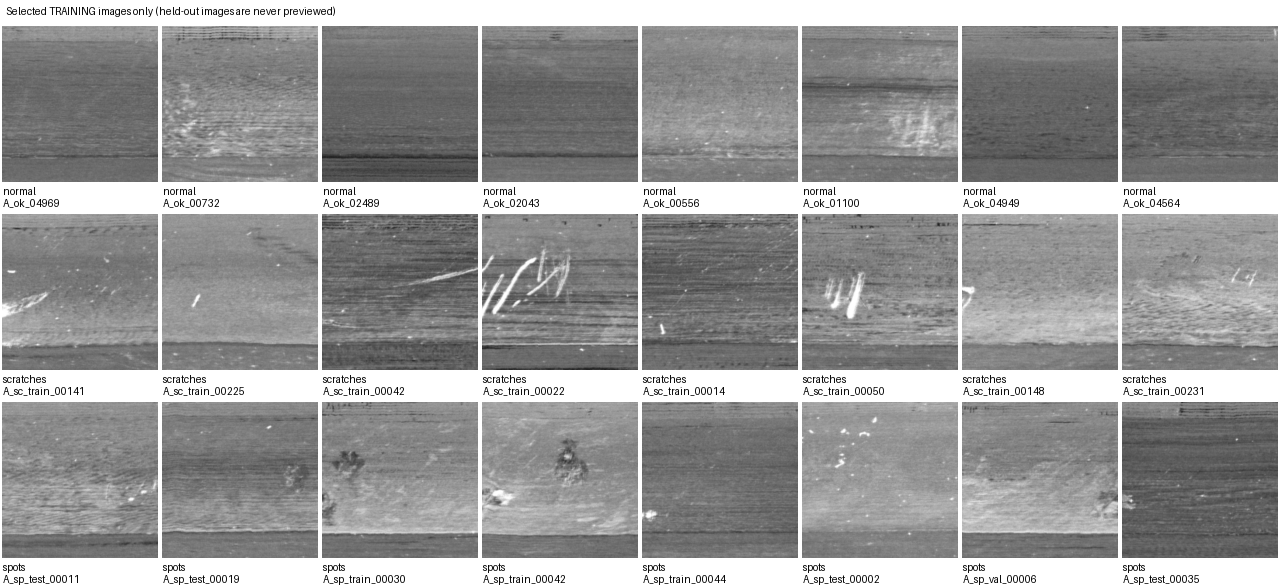

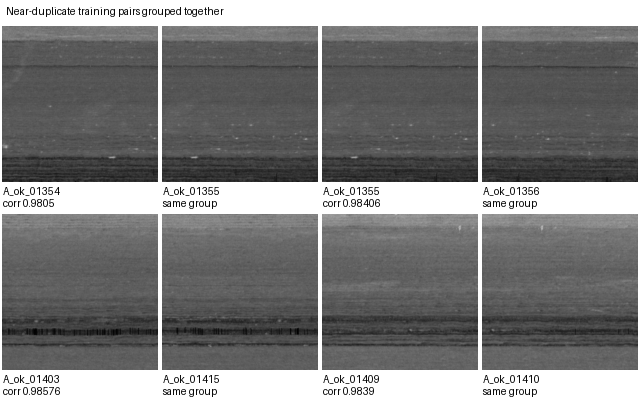

In [20]:
run_stage('data', 'lab', 'stage_data.py')
DATA = load('data_manifest.json')
if DATA_SOURCE == 'bosch':
    inv = DATA['inventory']
    table(['product', 'class', 'documented', 'measured', 'difference'],
          [[p, c, n, inv['measured_counts'].get(p, {}).get(c, 0), inv['differences'][p][c]] for p, cls in inv['documented_counts'].items() for c, n in cls.items()])
    print('image formats:', inv['modes'], '| undecodable:', len(inv['undecodable']), '|', inv['specimen_or_session_metadata'])
    print('official split of product A defects -> this notebook\'s split:', DATA['split']['official_vs_custom'])
g = DATA['grouping']
print(f"groups: {g['groups']:,}; exact-duplicate links: {g['exact_duplicate_links']}; near-duplicate pairs (corr >= {g['threshold']}): {g['near_duplicate_pairs']}; "
      f"pairs just below the threshold: {g['pairs_just_below_threshold']['count']}")
print(f"label-conflict duplicates excluded: {g['label_conflict_groups']} groups ({len(g['label_conflict_images'])} images): {g['label_conflict_images']}")
print('similar pairs (corr >= 0.95) that cross partitions, by label pair:', g['similar_pairs_crossing_partitions']['by_label_pair'])
order = DATA['class_order']
table(['partition', *order], [[s, *[DATA['split']['counts'].get(s, {}).get(c, 0) for c in order]] for s in ('train', 'val', 'test', 'excluded')])
print(f"selected training budget: {DATA['selected']}; unused training images: {DATA['unused_training_images']:,}")
print(f"split manifest SHA-256 {DATA['split']['manifest_sha256'][:16]}...; matches the reference audit: {DATA['split']['matches_reference']}")
show('training_examples.png')
show('near_duplicate_pairs.png')


**What to notice.**

- The defect counts match the published notes, but the normal counts do not (product A has 66 fewer normal images than documented; product C about 1,490 fewer). The notebook reports this; it does not guess why.
- Five pairs of images are pixel-for-pixel identical yet labelled `scratches` in one copy and `spots` in the other, and several of those pairs sit in *different* official partitions. Those ten images are excluded as label conflicts: neither label can be trusted, and keeping them would put the same picture in two partitions.
- The near-duplicate threshold (correlation 0.98 of 32 × 32 thumbnails) is a declared cut, not a natural boundary; the printout shows how many pairs sit just below it and how many similar pairs cross partitions. Most crossing pairs are normal/normal, because these surfaces share one texture.
- The test set has only about 21 spot images. Every spot metric later rests on those few pictures.
- `matches the reference audit: True` means your split is byte-identical to the one this notebook was written against. `False` means grouping or assignment changed (for example a different image decoder); the run continues with its own frozen manifest and records the difference.


> **Check your reasoning.** Why is a random image-level split risky for this dataset, and what does grouping by duplicates not protect against?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Consecutive capture frames and duplicated files are near-copies. With an image-level random split, a near-copy of a test image can sit in training, so the classifier is partly tested on what it memorised and scores look better than they would on new parts. Grouping keeps each detected cluster in one partition. It cannot detect similarity below the threshold, and it cannot tell whether two dissimilar images come from the same physical part, line or session, because the source supplies no such metadata. That is why the notebook calls this an image-group benchmark and not a specimen-level one.

</details>


## 3 · Baselines first: majority class and a real-only classifier  <sub>(core concept)</sub>

Before any generated image exists, it is worth knowing what "good" looks like. The feature stage turns each selected training image into a 512-number vector with a frozen ImageNet ResNet-18 (He et al., 2016), plus four fixed augmented views of each image for the conventional arm; validation images get one deterministic vector each. Preprocessing is the same everywhere: grayscale, letterbox to 224 × 224 without cropping, replicate to three channels, ImageNet normalisation.

Then a **preview** fits the linear head for arm A only (real images, no augmentation) and scores it on **validation**. The majority baseline always predicts `normal`.

**Predict first:** the majority baseline's accuracy on validation will be around what number? Its macro-F1?


The next cell saves the feature stage. `--part real` handles the training budget and validation; `--part synthetic` (Section 7) handles generated candidates.


In [21]:
%%writefile work/sdi_capstone/stage_features.py
"""Stage 3 / 7 (lab environment): frozen ResNet-18 features.

`--part real` (before any generation): the selected training budget (deterministic + four fixed views) and validation.
`--part synthetic` (after generation): the eligible synthetic pool and the synthetic-to-training near-duplicate audit.
"""
# ruff: noqa: E501
from __future__ import annotations

import argparse
import sys
import time
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402

BACKBONE = {
    "id": "timm/resnet18.tv_in1k",
    "revision": "bbd144b3e5565108aad885f145491d11bc6ce807",
    "file": "model.safetensors",
    "bytes": 46_807_446,
    "sha256": "694f673df6520a3158624e8a89af086f59923ee4cd7436fe5bc3bc71d295ad81",
    "license": "bsd-3-clause",
    "architecture": "torchvision.models.resnet18 (the torchvision ImageNet-1k weights, repackaged as safetensors)",
    "feature": "512-d global-average-pooled output of layer4; the ImageNet classifier (fc) is replaced by identity",
}
AUG_SEED = 20260929
BATCH = 64


def stage_backbone(work: Path) -> Path:
    from huggingface_hub import hf_hub_download

    root = work / "weights" / "resnet18-tv-in1k"
    path = root / BACKBONE["file"]
    if not path.is_file() or path.stat().st_size != BACKBONE["bytes"]:
        hf_hub_download(BACKBONE["id"], BACKBONE["file"], revision=BACKBONE["revision"], local_dir=str(root))
    if core.sha256_file(path) != BACKBONE["sha256"]:
        raise core.ContractError(f"{path} fails its pinned digest; refusing to load it")
    return path


def build_backbone(weights: Path, device: str):
    import torch
    import torchvision
    from safetensors.torch import load_file

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    model = torchvision.models.resnet18(weights=None)
    model.load_state_dict(load_file(str(weights)), strict=True)
    model.fc = torch.nn.Identity()
    for p in model.parameters():
        p.requires_grad_(False)
    return model.eval().to(device)


def embed(model, images, device: str) -> np.ndarray:
    import torch

    out = []
    for start in range(0, len(images), BATCH):
        batch = np.stack([core.to_model_array(im) for im in images[start : start + BATCH]])
        with torch.inference_mode():
            out.append(model(torch.from_numpy(batch).to(device)).float().cpu().numpy())
    return np.concatenate(out) if out else np.zeros((0, core.FEATURE_DIM), dtype=np.float32)


def features_with_views(model, items, device: str, log: list) -> tuple[np.ndarray, np.ndarray]:
    """items: (key, grayscale image). Deterministic features plus the fixed four-view bank."""
    det = embed(model, [im for _, im in items], device)
    views = np.zeros((len(items), core.N_VIEWS, core.FEATURE_DIM), dtype=np.float32)
    params = [core.view_params(key, AUG_SEED) for key, _ in items]
    for v in range(core.N_VIEWS):
        views[:, v] = embed(model, [core.apply_view(im, params[n][v]) for n, (_, im) in enumerate(items)], device)
    log.extend({"key": key, "views": p} for (key, _), p in zip(items, params, strict=True))
    return det, views


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("config")
    parser.add_argument("--part", choices=("real", "synthetic"), required=True)
    args = parser.parse_args()
    cfg = core.read_json(args.config)
    work, out = Path(cfg["work_dir"]), Path(cfg["out_dir"])
    started = time.time()
    import torch
    from PIL import Image

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = build_backbone(stage_backbone(work), device)
    order = core.read_json(out / "data_manifest.json")["class_order"]
    rows = core.read_split_manifest(out / "split_manifest.csv")
    data_root = work / "data" / ("sdi" if cfg["data_source"] == "bosch" else "byod")
    feat_dir = work / "features"
    feat_dir.mkdir(parents=True, exist_ok=True)
    figures = out / "figures"
    figures.mkdir(parents=True, exist_ok=True)
    aug_log: list = []
    train = sorted((r for r in rows if r["selected"]), key=lambda r: (order.index(r["label"]), r["budget_rank"]))

    if args.part == "real":
        train_items = [(r["file_sha256"], core.load_verified_gray(data_root / r["relpath"], r)) for r in train]
        det, views = features_with_views(model, train_items, device, aug_log)
        np.savez(feat_dir / "train.npz", image_id=np.array([r["image_id"] for r in train]), label=np.array([order.index(r["label"]) for r in train]), det=det, views=views)
        print(f"training budget: {len(train)} images x (1 deterministic + {core.N_VIEWS} views)")
        val = sorted((r for r in rows if r["split"] == "val"), key=lambda r: r["image_id"])
        vdet = embed(model, [core.load_verified_gray(data_root / r["relpath"], r) for r in val], device)
        np.savez(feat_dir / "val.npz", image_id=np.array([r["image_id"] for r in val]), label=np.array([order.index(r["label"]) for r in val]), group=np.array([r["group_id"] for r in val]), det=vdet)
        print(f"validation: {len(val)} images (deterministic preprocessing only)")
        core.write_jsonl(out / "augmentation_views.jsonl", aug_log)
        sheet = []
        for label in order:
            r = next(x for x in train if x["label"] == label)
            image = core.load_verified_gray(data_root / r["relpath"], r)
            params = core.view_params(r["file_sha256"], AUG_SEED)
            sheet.append((image, f"{label} original"))
            sheet += [(core.apply_view(image, p), f"view {p['view']} flip={int(p['hflip'])}\nb{p['brightness']} c{p['contrast']}") for p in params]
        core.contact_sheet(sheet, columns=5, title="Conventional augmentation views of TRAINING images (label must survive every view)").save(figures / "augmentation_views.png")
        state = {"backbone": BACKBONE, "device": device, "aug_seed": AUG_SEED, "augment": core.AUGMENT, "n_views": core.N_VIEWS, "preprocessing": core.PREPROCESSING, "seconds": round(time.time() - started, 1), "torch": torch.__version__}
        core.write_json(work / "state" / "features_stage.json", state)
        print(core.canonical_json({"device": device, "train": len(train), "val": len(val), "seconds": state["seconds"]}))
        return

    generated = [r for r in core.read_jsonl(out / "generation_manifest.jsonl") if r["status"] == "eligible"]
    synth_items = [(r["pixel_sha256"], Image.open(out / r["file"]).convert("L")) for r in generated]
    sdet, sviews = features_with_views(model, synth_items, device, aug_log)
    np.savez(feat_dir / "synthetic.npz", candidate_id=np.array([r["candidate_id"] for r in generated]), label=np.array([order.index(r["intended_label"]) for r in generated], dtype=np.int64), det=sdet, views=sviews)
    core.write_jsonl(out / "synthetic_augmentation_views.jsonl", aug_log)
    print(f"synthetic pool: {len(generated)} eligible candidates (converted to grayscale, letterboxed from 512 px)")
    # Synthetic-to-training near-duplicate audit (before fitting): training partition only.
    sig = np.load(work / "audit" / "signatures.npz")
    split_of = {r["image_id"]: r["split"] for r in rows}
    keep = np.array([split_of.get(i) == "train" for i in sig["image_id"]])
    train_sigs, train_ids = sig["signature"][keep].astype(np.float32), sig["image_id"][keep]
    synth_sigs = np.stack([core.signature(im) for _, im in synth_items]) if synth_items else np.zeros((0, core.SIGNATURE_SIDE**2), np.float32)
    best, where = core.max_similarity(synth_sigs, train_sigs)
    audit = {
        "threshold": core.NEAR_DUPLICATE_THRESHOLD,
        "reference": "all training-partition real images",
        "max_correlation": float(best.max()) if len(best) else None,
        "flagged": [{"candidate_id": generated[n]["candidate_id"], "closest_training_image": str(train_ids[where[n]]), "correlation": round(float(best[n]), 4)} for n in np.nonzero(best >= core.NEAR_DUPLICATE_THRESHOLD)[0]],
        "per_candidate": {generated[n]["candidate_id"]: round(float(best[n]), 4) for n in range(len(generated))},
        "policy": "reported, not used to filter candidates",
    }
    core.write_json(out / "synthetic_training_overlap.json", audit)
    print(f"synthetic-to-training audit: max correlation {audit['max_correlation']}, {len(audit['flagged'])} flagged at >= {core.NEAR_DUPLICATE_THRESHOLD}")
    print(core.canonical_json({"device": device, "synthetic": len(generated), "seconds": round(time.time() - started, 1)}))


if __name__ == "__main__":
    core.run_main(main)


Writing work/sdi_capstone/stage_features.py


The next cell saves the fitting stage. It is used three ways: `--preview` (below), the canonical fit and freeze (Section 8), and validation-only extensions (Section 13). It never reads test images.


In [22]:
%%writefile work/sdi_capstone/stage_fit.py
"""Stage 6 (lab environment): fit the linear heads for arms A/B/C on matched slot schedules, select epochs on
validation, and freeze the experiment. The test partition is not read here.

Modes: canonical (default); `--preview` (majority baseline and arm A on validation, before any generation);
`--synthetic-probability P --tag NAME` (change-one-thing exercise, validation only);
`--review CSV --tag NAME` (optional human-reviewed pool, validation only). Only the canonical mode freezes.
"""
# ruff: noqa: E501
from __future__ import annotations

import argparse
import csv
import sys
import time
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402


def load_features(work: Path, *, with_synthetic: bool = True) -> dict:
    f = work / "features"
    feats = {name: dict(np.load(f / f"{name}.npz")) for name in ("train", "val")}
    empty = {"candidate_id": np.array([], dtype=str), "label": np.array([], dtype=np.int64), "det": np.zeros((0, core.FEATURE_DIM), np.float32), "views": np.zeros((0, core.N_VIEWS, core.FEATURE_DIM), np.float32)}
    feats["synthetic"] = dict(np.load(f / "synthetic.npz")) if with_synthetic else empty
    return feats


def pools(labels: np.ndarray, k: int) -> tuple[list[int], list[int]]:
    sizes = [int((labels == c).sum()) for c in range(k)]
    offsets = [int(sum(sizes[:c])) for c in range(k)]
    if any(np.any(labels[offsets[c] : offsets[c] + sizes[c]] != c) for c in range(k)):
        raise core.ContractError("feature rows are not grouped by class")
    return sizes, offsets


def slot_features(feats: dict, sched: dict, src: dict, real_off: list[int], synth_off: list[int]) -> np.ndarray:
    cls, index, view, synthetic = sched["cls"], src["index"], src["view"], src["synthetic"]
    x = np.empty((len(cls), core.FEATURE_DIM), dtype=np.float32)
    real = ~synthetic
    rows = np.asarray(real_off)[cls] + index
    det = view < 0
    x[real & det] = feats["train"]["det"][rows[real & det]]
    x[real & ~det] = feats["train"]["views"][rows[real & ~det], view[real & ~det]]
    if synthetic.any():
        srows = np.asarray(synth_off)[cls[synthetic]] + index[synthetic]
        x[synthetic] = feats["synthetic"]["views"][srows, view[synthetic]]
    return x


def train_head(x: np.ndarray, y: np.ndarray, init: dict, val_x: np.ndarray, val_y: np.ndarray, k: int) -> dict:
    import torch

    torch.use_deterministic_algorithms(True)
    head = torch.nn.Linear(core.FEATURE_DIM, k)
    head.load_state_dict({n: t.clone() for n, t in init.items()})
    opt = torch.optim.AdamW(head.parameters(), lr=core.HEAD["learning_rate"], weight_decay=core.HEAD["weight_decay"])
    xt, yt, vx = torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(val_x)
    batch, updates = core.HEAD["batch_size"], core.HEAD["updates_per_epoch"]
    curve, best = [], None
    for epoch in range(1, core.HEAD["epochs"] + 1):
        losses = []
        for u in range(updates):
            start = ((epoch - 1) * updates + u) * batch
            loss = torch.nn.functional.cross_entropy(head(xt[start : start + batch]), yt[start : start + batch])
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
        with torch.no_grad():
            pred = head(vx).argmax(1).numpy()
        m = core.metrics_from_confusion(core.confusion_matrix(val_y, pred, k), [str(i) for i in range(k)])
        curve.append({"epoch": epoch, "train_loss": round(float(np.mean(losses)), 5), "val_macro_f1": m["macro_f1"], "val_balanced_accuracy": m["balanced_accuracy"]})
        if best is None or m["macro_f1"] > best["val_macro_f1"]:  # strict: the earlier epoch wins a tie
            best = {"epoch": epoch, "val_macro_f1": m["macro_f1"], "weight": head.weight.detach().numpy().copy(), "bias": head.bias.detach().numpy().copy()}
    return {**best, "curve": curve}


def read_review(path: Path, candidates: list[str]) -> set[str]:
    with open(path, encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    known, accepted = set(candidates), set()
    for n, row in enumerate(rows, start=2):
        cid, decision = row.get("candidate_id", "").strip(), row.get("decision", "").strip().lower()
        if cid not in known:
            continue  # the template lists every attempt; rejected attempts have no features
        if decision not in ("accept", "reject", "uncertain"):
            raise core.ContractError(f"{path} line {n}: decision {decision!r} must be accept, reject or uncertain")
        if decision == "accept":
            accepted.add(cid)
    return accepted


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("config")
    parser.add_argument("--synthetic-probability", type=float, default=None)
    parser.add_argument("--review", default=None)
    parser.add_argument("--tag", default=None)
    parser.add_argument("--preview", action="store_true")
    args = parser.parse_args()
    cfg = core.read_json(args.config)
    base, work, out = Path(cfg["base_dir"]), Path(cfg["work_dir"]), Path(cfg["out_dir"])
    canonical = args.synthetic_probability is None and args.review is None and not args.preview
    if args.preview:
        args.tag = "real_only_preview"
    started = time.time()
    import torch

    data = core.read_json(out / "data_manifest.json")
    order = data["class_order"]
    k = len(order)
    seeds = [int(s) for s in cfg["seeds"]]
    feats = load_features(work, with_synthetic=not args.preview)
    real_sizes, real_off = pools(feats["train"]["label"], k)
    gen_status = core.read_json(out / "generation_status.json") if not args.preview else {"complete": False, "shortfall": ["not generated yet (preview)"]}
    synth = feats["synthetic"]
    if args.review:
        accepted = read_review(Path(args.review), list(synth["candidate_id"]))
        keep = np.array([c in accepted for c in synth["candidate_id"]], dtype=bool)
        synth = {key: value[keep] for key, value in synth.items()}
        feats["synthetic"] = synth
        print(f"human-review extension: {int(keep.sum())} accepted candidates of {len(keep)}")
    synth_sizes = [int((synth["label"] == c).sum()) for c in range(k)]
    synth_off = [int(sum(synth_sizes[:c])) for c in range(k)]
    if len(synth["label"]) and np.any(np.diff(synth["label"]) < 0):
        raise core.ContractError("synthetic feature rows are not grouped by class")
    probability = core.SYNTHETIC_PROBABILITY if args.synthetic_probability is None else args.synthetic_probability
    run_c = gen_status["complete"] or not canonical
    arms = list(core.ARMS if canonical else ("A",) if args.preview else ("C",))
    if canonical and not run_c:
        arms.remove("C")
        print("generation shortfall: " + "; ".join(gen_status["shortfall"]) + " -> arm C is not run and no synthetic comparison is reported")
    val_x, val_y = feats["val"]["det"], feats["val"]["label"]
    results: dict = {"majority": {}}
    majority = int(np.argmax(real_sizes))
    majority_metrics = core.metrics_from_confusion(core.confusion_matrix(val_y, np.full_like(val_y, majority), k), order)
    heads_dir = work / "heads" / (args.tag or "canonical")
    heads_dir.mkdir(parents=True, exist_ok=True)
    from safetensors.numpy import save_file

    for seed in seeds:
        sched = core.slot_schedule(seed, real_sizes, synth_sizes)
        torch.manual_seed(seed)
        init = {n: t.detach().clone() for n, t in torch.nn.Linear(core.FEATURE_DIM, k).state_dict().items()}
        results["majority"][str(seed)] = {"class": order[majority], "val": majority_metrics}
        for arm in arms:
            src = core.arm_sources(sched, arm, synth_probability=probability, synth_sizes=synth_sizes)
            x = slot_features(feats, sched, src, real_off, synth_off)
            fit = train_head(x, sched["cls"], init, val_x, val_y, k)
            pred = (val_x @ fit["weight"].T + fit["bias"]).argmax(1)
            val_metrics = core.metrics_from_confusion(core.confusion_matrix(val_y, pred, k), order)
            path = heads_dir / f"{arm}_s{seed}.safetensors"
            save_file({"weight": fit["weight"].astype(np.float32), "bias": fit["bias"].astype(np.float32)}, str(path))
            results.setdefault(arm, {})[str(seed)] = {
                "selected_epoch": fit["epoch"], "val": val_metrics, "curve": fit["curve"], "head": str(path.relative_to(base)),
                "synthetic_slot_fraction": float(src["synthetic"].mean()), "synthetic_share_of_defect_slots": float(src["synthetic"][sched["cls"] > 0].mean()),
            }
            print(f"seed {seed} arm {arm}: epoch {fit['epoch']:>2} val macro-F1 {val_metrics['macro_f1']:.4f} (synthetic share of defect slots {results[arm][str(seed)]['synthetic_share_of_defect_slots']:.3f})")
    if not canonical:
        body = {"tag": args.tag, "arms": arms, "synthetic_probability": None if args.preview else probability, "review_csv": args.review, "synthetic_sizes": synth_sizes, "evidence": "validation only; exploratory; does not alter the canonical frozen results", "results": results}
        core.write_json(out / "extensions" / f"{args.tag}.json", body)
        print(core.canonical_json({"tag": args.tag, "val_macro_f1": {a: {s: v["val"]["macro_f1"] for s, v in results[a].items()} for a in arms}, "majority_val_macro_f1": majority_metrics["macro_f1"]}))
        return
    # Export choice: canonical seed, arm with the best validation macro-F1, ties to A, then B, then C.
    canon = str(core.CANONICAL_SEED if core.CANONICAL_SEED in seeds else seeds[0])
    ranked = sorted(arms, key=lambda a: (-results[a][canon]["val"]["macro_f1"], core.ARMS.index(a)))
    selection = {"seed": int(canon), "arm": ranked[0], "val_macro_f1": results[ranked[0]][canon]["val"]["macro_f1"], "epoch": results[ranked[0]][canon]["selected_epoch"], "rule": "canonical seed; highest validation macro-F1; ties favour A, then B, then C"}
    record = {
        "question": "Under a fixed real-data budget, classifier, class-sampling policy and training budget, does substituting synthetic defect examples into training improve real-test macro-F1 compared with conventional augmentation?",
        "primary_contrast": "C - B", "contextual_contrast": "B - A", "primary_metric": "macro-F1 on the test partition",
        "class_order": order, "budget": data["budget"], "split_version": data["split"]["version"], "split_sha256": data["split"]["manifest_sha256"],
        "seeds": seeds, "smoke_run": len(seeds) < 3, "head": core.HEAD, "synthetic_probability": probability,
        "slot_policy": "class-balanced batches (11/11/10 rotating); normal slots always real; in arm C each defect slot draws its synthetic pool with the stated probability; A uses deterministic features, B and C draw one of four fixed views",
        "arms_run": arms, "generation_status": gen_status, "real_pool_sizes": real_sizes, "synthetic_pool_sizes": synth_sizes,
        "preprocessing": core.PREPROCESSING, "augment": core.AUGMENT, "features": core.read_json(work / "state" / "features_stage.json"),
        "validation": results, "selection": selection, "majority_class": order[majority], "core_version": core.CORE_VERSION,
    }
    referenced = {name: out / name for name in ("data_manifest.json", "split_manifest.csv", "caption_records.jsonl", "prompts.json", "generation_manifest.jsonl", "generation_status.json", "synthetic_training_overlap.json", "augmentation_views.jsonl", "synthetic_augmentation_views.jsonl")}
    referenced.update({f"features/{n}": work / "features" / f"{n}.npz" for n in ("train", "synthetic", "val")})
    referenced.update({f"heads/{p.stem}": p for p in sorted(heads_dir.glob("*.safetensors"))})
    # The thumbnail signatures used by the post-freeze overlap audit, and the code that defines preprocessing,
    # fitting, evaluation and export, are bound too: changing any of them after this point fails verify_frozen.
    referenced["audit/signatures"] = work / "audit" / "signatures.npz"
    referenced.update(core.source_files(Path(__file__).resolve().parent))
    frozen = core.freeze_record(out / "experiment_config.json", record, referenced, base)
    print(f"experiment frozen: record SHA-256 {frozen['record_sha256'][:16]}..., {len(frozen['frozen_files'])} inputs pinned; export choice {selection} ({time.time() - started:.1f} s)")


if __name__ == "__main__":
    core.run_main(main)


Writing work/sdi_capstone/stage_fit.py


training budget: 224 images x (1 deterministic + 4 views)
validation: 1325 images (deterministic preprocessing only)
{"device":"cuda","seconds":49.9,"train":224,"val":1325}

[features_real] 55.5 s | peak child RSS 1386 MiB | peak GPU in use 841 MiB | lowest host memory available 9004 MiB | disk free 187.2 GB


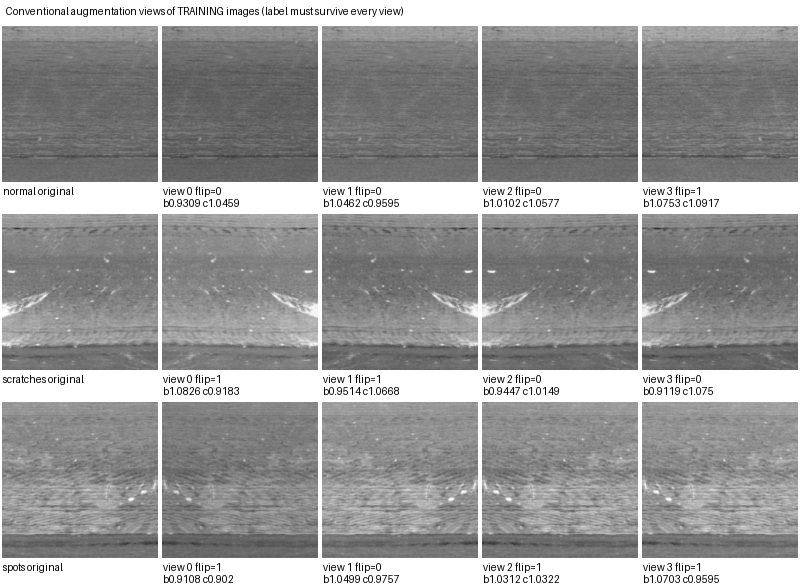

seed 17 arm A: epoch 26 val macro-F1 0.6393 (synthetic share of defect slots 0.000)
seed 29 arm A: epoch 13 val macro-F1 0.6295 (synthetic share of defect slots 0.000)
seed 43 arm A: epoch 20 val macro-F1 0.6349 (synthetic share of defect slots 0.000)
{"majority_val_macro_f1":0.3218839448347645,"tag":"real_only_preview","val_macro_f1":{"A":{"17":0.6392781084191178,"29":0.6295125008282351,"43":0.6348517040789184}}}

[preview] 7.6 s | peak child RSS 944 MiB | peak GPU in use 105 MiB | lowest host memory available 9298 MiB | disk free 187.2 GB


| arm | seed | val accuracy | val balanced acc. | val macro-F1 | recall normal | recall scratches | recall spots |
|---|---|---|---|---|---|---|---|
| majority | 17 | 0.934 | 0.333 | 0.322 | 1.000 | 0.000 | 0.000 |
| majority | 29 | 0.934 | 0.333 | 0.322 | 1.000 | 0.000 | 0.000 |
| majority | 43 | 0.934 | 0.333 | 0.322 | 1.000 | 0.000 | 0.000 |
| A | 17 | 0.909 | 0.810 | 0.639 | 0.915 | 0.896 | 0.619 |
| A | 29 | 0.915 | 0.781 | 0.630 | 0.922 | 0.896 | 0.524 |
| A | 43 | 0.912 | 0.795 | 0.635 | 0.918 | 0.896 | 0.571 |

In [23]:
run_stage('features_real', 'lab', 'stage_features.py', '--part', 'real')
show('augmentation_views.png')
run_stage('preview', 'lab', 'stage_fit.py', '--preview')
PREVIEW = load('extensions/real_only_preview.json')
rows = []
for arm in ('majority', 'A'):
    for seed, r in PREVIEW['results'][arm].items():
        v = r['val']
        rows.append([arm, seed, fmt(v['accuracy']), fmt(v['balanced_accuracy']), fmt(v['macro_f1']), *[fmt(v['per_class'][c]['recall']) for c in order]])
table(['arm', 'seed', 'val accuracy', 'val balanced acc.', 'val macro-F1', *[f'recall {c}' for c in order]], rows)


**What to notice.** The majority baseline's accuracy is about 0.93 while its macro-F1 is about 0.32 (F1 of roughly 0.96 for `normal` and 0 for both defects, averaged). High accuracy with zero defect recall is exactly the failure an inspection system cannot afford. The real-only head trades some `normal` accuracy for defect recall. Look at the augmentation sheet: a flip or a ±10% brightness/contrast change leaves every scratch and spot visible, which is the evidence that these transforms preserve labels. The three seeds of arm A differ only in the head's initial weights and the order of training draws, so their spread is a first look at noise that has nothing to do with the method.

These are validation numbers from the preview. The canonical arms are fitted again in Section 8 with identical settings, and only Section 9 touches the test set.


> **Check your reasoning.** A colleague reports 94% accuracy for a defect classifier on this dataset. What would you ask before being impressed?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Ask for per-class recall and macro-F1, the class distribution of the evaluation set, and whether the evaluation images were held out by group. At about 93% `normal`, a classifier that finds no defects already scores 93% accuracy, so 94% could mean almost nothing.

</details>


## 4 · Phi-4 describes training exemplars: observed versus guessed  <sub>(core concept)</sub>

Phi-4-multimodal-instruct (Abouelenin et al., 2025) is a 5.6 B-parameter model that reads images and text. Here it is **frozen** and loaded 4-bit (NF4, float16 compute; the vision encoder, projector, embeddings and the checkpoint's own LoRA stay float16). It sees three exemplars per class, all drawn from the selected training images, and it is **not told the label**. Decoding is greedy, at most 96 new tokens per image.

The fixed instruction asks for visible texture, illumination and the shape of any mark, offers `material: unknown`, and forbids guessing alloy, process or severity:

> Describe only what is visible in this grayscale close-up photograph of a surface, in at most three short sentences. Mention the texture, the illumination, and the shape and size of any visible mark. If you cannot tell what the material is, write 'material: unknown'. Do not guess the alloy, the manufacturing process or how severe any mark is.

**Trust boundary.** The checkpoint `microsoft/Phi-4-multimodal-instruct` at the immutable revision `93f923e1…` implements its model, configuration and processor in five Python files inside the model repository, and `transformers 4.48.2` has no built-in implementation, so `trust_remote_code=True` is unavoidable. The stage refuses to run unless `ALLOW_PHI4_REMOTE_CODE` is `True`, pins every file (weights, configuration, tokenizer and the five code files) by SHA-256, and verifies them before `transformers` imports anything. Pinning bounds *which* code runs; it does not make the code safe by itself. The model is MIT-licensed. Its weights (11.2 GB) are deleted after this stage by default.


The next cell saves the Phi-4 description stage; the cell after it runs it in the `phi4` environment.


In [24]:
%%writefile work/sdi_capstone/stage_phi4.py
"""Stage 2 (phi4 environment): describe the selected training exemplars with Phi-4-multimodal-instruct (frozen, NF4)."""
# ruff: noqa: E501
from __future__ import annotations

import gc
import shutil
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402

MODEL_ID = "microsoft/Phi-4-multimodal-instruct"
MODEL_REVISION = "93f923e1a7727d1c4f446756212d9d3e8fcc5d81"  # immutable commit; the same pin as phi4-multimodal-pipeline
MODEL_LICENSE = "MIT"
# (path, bytes, sha256) for every file the image path needs, from the pipeline's committed snapshot manifest.
FILES = (
    ("LICENSE", 1141, "c2cfccb812fe482101a8f04597dfc5a9991a6b2748266c47ac91b6a5aae15383"),
    ("added_tokens.json", 249, "d4f2aceb0f20b71dd1f4bcc7e052e4412946bf281840b8f83d39f259571af486"),
    ("config.json", 4631, "49e1c05f93d43d7f17715b779a2576235b019f587285d7d914e5b05156253f62"),
    ("configuration_phi4mm.py", 11014, "bd9609bd47ba0c87788011e5158a8bd3e1e93165a82a9b764eb7cb048006c949"),
    ("generation_config.json", 190, "757daa0d0e89171fe48fc3286341833e95b90bdb7dd3b02a2f8920fb09f85a38"),
    ("merges.txt", 2418348, "856ce61180bb689282eed6b3a6838bb1f438399be23aefe9d20eb379791fb4ad"),
    ("model-00001-of-00003.safetensors", 4997504848, "c46bb03332d82f6a3eaf85bd20af388dd4d4d68b198c2203c965c7381a466094"),
    ("model-00002-of-00003.safetensors", 4952333128, "b3e812c0c8acef4e7f5e34d6c9f77a7640ee4a2b93ea351921365ac62f19918d"),
    ("model-00003-of-00003.safetensors", 1199389232, "7be96b7339303752634b202d3f377bcf312a03046586eca6cea23347ace1e65a"),
    ("model.safetensors.index.json", 239890, "b67dbc7062e1ccf472faba4222d631dc42929c827fbdaed1ec8e34fe0601819a"),
    ("modeling_phi4mm.py", 116057, "e2b44eb7a66d6cc54524cee1ff9ba92d0658d435ea8900329ea0dbdb85c6439d"),
    ("preprocessor_config.json", 482, "9db19b9663fb86f04c0f11d3a9b7f65a19f13d4543fb4a15bd33f82b0c92d64f"),
    ("processing_phi4mm.py", 32775, "84914d3e12256b4e2186e040c9830c11408468b6774f42afe85e6f8de2626d50"),
    ("processor_config.json", 121, "798fc4cd09c067053af27f07f0d2b329b471c5b2eb923ceb06efa41dee660c05"),
    ("special_tokens_map.json", 473, "57491904f8680d4b52ed440f1f7ba48cad1c31ecf3eb453b03484e6ff4723ae8"),
    ("speech_conformer_encoder.py", 110521, "3742827e945732cc5deea4a95e14004da037044431a94e3f3fac26239e614e3a"),
    ("tokenizer.json", 15524479, "4c1b9f641d4f8b7247b8d5007dd3b6a9f6a87cb5123134fe0d326f14d10c0585"),
    ("tokenizer_config.json", 3248, "a5da2e45718db78924ad5135a58a80b0303596acf54a1dc5c912c98436ddcaf3"),
    ("vision_siglip_navit.py", 78218, "7d5c053341ee9c099126fe675d5dcdc0ed5c0246f92fffdec78a1ab2f804e28d"),
    ("vocab.json", 3910310, "6cb65a857824fa6615bb1782d95d882617a8bbce1da0317118586b36f39e98bd"),
)
# Upstream Python that transformers executes under trust_remote_code=True; each is digest-verified above first.
REMOTE_CODE_FILES = ("configuration_phi4mm.py", "modeling_phi4mm.py", "processing_phi4mm.py", "speech_conformer_encoder.py", "vision_siglip_navit.py")
# Language-model linears load 4-bit; the vision encoder, projector, embeddings and the checkpoint's LoRA stay float16.
NF4_SKIP_MODULES = ("lm_head", "embed_tokens", "embed_tokens_extend", "image_embed", "audio_embed", "img_processor", "encoder", "lora_A", "lora_B")
INSTRUCTION = (
    "Describe only what is visible in this grayscale close-up photograph of a surface, in at most three short sentences. "
    "Mention the texture, the illumination, and the shape and size of any visible mark. "
    "If you cannot tell what the material is, write 'material: unknown'. "
    "Do not guess the alloy, the manufacturing process or how severe any mark is."
)
MAX_NEW_TOKENS = 96
DECODING = {"do_sample": False, "strategy": "greedy", "max_new_tokens": MAX_NEW_TOKENS, "attention": "eager", "quantization": "nf4 (bitsandbytes, double quantisation, float16 compute)"}


def stage_and_verify(root: Path) -> dict:
    from huggingface_hub import hf_hub_download

    fetched = 0
    for rel, size, _ in FILES:
        path = root / rel
        if not path.is_file() or path.stat().st_size != size:
            print(f"  fetching {rel} ({size / 1e9:.2f} GB)")
            hf_hub_download(MODEL_ID, rel, revision=MODEL_REVISION, local_dir=str(root))
            fetched += size
    for rel, size, digest in FILES:
        path = root / rel
        if path.stat().st_size != size or core.sha256_file(path) != digest:
            raise core.ContractError(f"{MODEL_ID}@{MODEL_REVISION}: {rel} fails its pinned digest; refusing to load (no fallback model is used)")
    print(f"verified {len(FILES)} files against their pinned SHA-256 digests")
    return {"downloaded_bytes": fetched, "files": len(FILES), "total_bytes": sum(s for _, s, _ in FILES)}


def install_adapter_switch(model) -> None:
    """The checkpoint routes images through its built-in 'vision' LoRA and calls set_lora_adapter on every forward.
    Upstream's version also flips requires_grad on 4-bit tensors; this replacement only switches the active adapter."""
    from peft.tuners.tuners_utils import BaseTunerLayer

    layers = [m for m in model.modules() if isinstance(m, BaseTunerLayer)]

    def switch(name: str) -> None:
        for m in layers:
            m._active_adapter = [name]
            m._disable_adapters = False

    def unset() -> None:
        for m in layers:
            m._disable_adapters = True

    model.set_lora_adapter = switch
    model.unset_lora_adapter = unset


def main(cfg_path: str) -> None:
    cfg = core.read_json(cfg_path)
    work, out = Path(cfg["work_dir"]), Path(cfg["out_dir"])
    if not cfg["allow_phi4_remote_code"]:
        raise SystemExit("Phi-4-multimodal ships its model code as Python files in the model repository. Set ALLOW_PHI4_REMOTE_CODE = True after reviewing the trust boundary described above the cell.")
    rows = [r for r in core.read_split_manifest(out / "split_manifest.csv") if r["exemplar"]]
    if any(r["split"] != "train" or not r["selected"] for r in rows):
        raise core.ContractError("a captioning exemplar is not a selected training image; refusing to describe it")
    order = core.read_json(out / "data_manifest.json")["class_order"]
    rows.sort(key=lambda r: (order.index(r["label"]), r["budget_rank"]))
    data_root = work / "data" / ("sdi" if cfg["data_source"] == "bosch" else "byod")
    root = work / "weights" / "phi4-multimodal-instruct"
    t0 = time.time()
    staging = stage_and_verify(root)
    stage_seconds = round(time.time() - t0, 1)

    import torch
    from PIL import Image
    from transformers import AutoModelForCausalLM, AutoProcessor, BitsAndBytesConfig, GenerationConfig

    if not torch.cuda.is_available():
        raise SystemExit("Phi-4 is loaded 4-bit with bitsandbytes and needs a CUDA GPU: Runtime > Change runtime type > T4 GPU")
    torch.manual_seed(0)
    t1 = time.time()
    processor = AutoProcessor.from_pretrained(str(root), trust_remote_code=True)
    quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True, llm_int8_skip_modules=list(NF4_SKIP_MODULES))
    model = AutoModelForCausalLM.from_pretrained(str(root), trust_remote_code=True, device_map="cuda", _attn_implementation="eager", torch_dtype=torch.float16, quantization_config=quant).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    install_adapter_switch(model)
    generation_config = GenerationConfig.from_pretrained(str(root))
    load_seconds = round(time.time() - t1, 1)
    print(f"loaded 4-bit in {load_seconds} s; GPU memory allocated {torch.cuda.memory_allocated() / 2**30:.2f} GiB")
    prompt = f"<|user|><|image_1|>{INSTRUCTION}<|end|><|assistant|>"
    records = []
    for r in rows:
        path = data_root / r["relpath"]
        image = Image.open(path).convert("RGB")
        inputs = processor(text=prompt, images=[image], return_tensors="pt").to("cuda")
        t = time.time()
        with torch.inference_mode():
            generated = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False, generation_config=generation_config)
        new_tokens = generated[:, inputs["input_ids"].shape[1]:]
        text = processor.batch_decode(new_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()
        n = int(new_tokens.shape[1])
        eos = generation_config.eos_token_id
        eos_ids = set(eos if isinstance(eos, list | tuple) else [eos]) - {None}
        last = int(new_tokens[0, -1]) if n else None
        stop_reason = "end_of_sequence" if last in eos_ids else ("max_new_tokens" if n >= MAX_NEW_TOKENS else "other")
        records.append({
            "image_id": r["image_id"], "label": r["label"], "exemplar_rank": r["budget_rank"], "split": r["split"],
            "image_sha256": r["file_sha256"], "instruction": INSTRUCTION, "response": text, "new_tokens": n,
            "stop_reason": stop_reason, "eos_token_ids": sorted(eos_ids), "decoding": DECODING, "model_id": MODEL_ID, "model_revision": MODEL_REVISION,
            "label_shown_to_model": False, "seconds": round(time.time() - t, 2),
        })
        print(f"[{r['label']} #{r['budget_rank']}] {r['image_id']}: {text}")
    core.write_jsonl(out / "caption_records.jsonl", records)
    summary = {
        "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "license": MODEL_LICENSE, "remote_code_files": {rel: d for rel, _, d in FILES if rel in REMOTE_CODE_FILES}},
        "staging": staging, "stage_seconds": stage_seconds, "load_seconds": load_seconds,
        "peak_gpu_allocated_gib": round(torch.cuda.max_memory_allocated() / 2**30, 2),
        "records": len(records), "decoding": DECODING,
    }
    del model, processor
    gc.collect()
    torch.cuda.empty_cache()
    if cfg["delete_model_weights_after_use"]:
        shutil.rmtree(root, ignore_errors=True)
        summary["weights_deleted_after_use"] = True
    core.write_json(work / "state" / "phi4_stage.json", summary)
    print(core.canonical_json({k: summary[k] for k in ("stage_seconds", "load_seconds", "peak_gpu_allocated_gib", "records")}))


if __name__ == "__main__":
    core.run_main(main, sys.argv[1])


Writing work/sdi_capstone/stage_phi4.py


In [25]:
run_stage('phi4', 'phi4', 'stage_phi4.py')
CAPTIONS = load('caption_records.jsonl')
table(['class', '#', 'image', 'tokens', 'stop reason', 'description'], [[r['label'], r['exemplar_rank'], r['image_id'], r['new_tokens'], r['stop_reason'], r['response'].replace('|', '/')] for r in CAPTIONS])


  fetching LICENSE (0.00 GB)
  fetching added_tokens.json (0.00 GB)
  fetching config.json (0.00 GB)
  fetching configuration_phi4mm.py (0.00 GB)
  fetching generation_config.json (0.00 GB)
  fetching merges.txt (0.00 GB)
  fetching model-00001-of-00003.safetensors (5.00 GB)
  fetching model-00002-of-00003.safetensors (4.95 GB)
  fetching model-00003-of-00003.safetensors (1.20 GB)
  fetching model.safetensors.index.json (0.00 GB)
  fetching modeling_phi4mm.py (0.00 GB)
  fetching preprocessor_config.json (0.00 GB)
  fetching processing_phi4mm.py (0.00 GB)
  fetching processor_config.json (0.00 GB)
  fetching special_tokens_map.json (0.00 GB)
  fetching speech_conformer_encoder.py (0.00 GB)
  fetching tokenizer.json (0.02 GB)
  fetching tokenizer_config.json (0.00 GB)
  fetching vision_siglip_navit.py (0.00 GB)
  fetching vocab.json (0.00 GB)
verified 20 files against their pinned SHA-256 digests
/content/work/sdi_capstone/envs/phi4/lib/python3.12/site-packages/transformers/models/auto/

| class | # | image | tokens | stop reason | description |
|---|---|---|---|---|---|
| normal | 0 | A_ok_04969 | 47 | end_of_sequence | The image shows a close-up of a surface with a rough texture. The lighting is even, highlighting the surface's grainy appearance. There is a faint mark on the surface, but its shape and size are not clearly visible. |
| normal | 1 | A_ok_00732 | 69 | end_of_sequence | The image shows a close-up of a surface with a textured appearance. The lighting is even, highlighting the surface details. There is a faint mark on the surface, but its shape and size are not clearly visible. The material appears to be a solid surface, possibly metal or plastic, but it is not possible to determine the exact material. |
| normal | 2 | A_ok_02489 | 39 | end_of_sequence | The image shows a close-up of a surface with a fine texture. The lighting is even, highlighting the surface's details. There is a faint horizontal line across the center of the image. |
| scratches | 0 | A_sc_train_00141 | 44 | end_of_sequence | The image shows a close-up of a surface with a rough texture. The lighting is uneven, creating shadows and highlights. There is a white mark on the surface, but its shape and size are not clearly defined. |
| scratches | 1 | A_sc_train_00225 | 35 | end_of_sequence | The image shows a close-up of a surface with a rough texture. The illumination highlights the surface's unevenness. There is a small, irregular mark on the surface. |
| scratches | 2 | A_sc_train_00042 | 38 | end_of_sequence | The image shows a close-up of a surface with a textured appearance. The lighting is even, highlighting the surface's features. There is a faint mark running diagonally across the image. |
| spots | 0 | A_sp_test_00011 | 52 | end_of_sequence | The image shows a close-up of a surface with a textured appearance. The lighting is uneven, creating shadows and highlights. There is a faint mark on the surface, but its shape and size are not clearly visible. The material of the surface is unknown. |
| spots | 1 | A_sp_test_00019 | 36 | end_of_sequence | The image shows a close-up of a surface with a rough texture. The lighting is even, highlighting the surface details. There is a small, irregular mark on the surface. |
| spots | 2 | A_sp_train_00030 | 36 | end_of_sequence | The image shows a close-up of a surface with a rough texture. The lighting is uneven, creating shadows and highlights. There is a small, irregular mark on the surface. |

**What to notice.** Read each description and sort its claims into three bins: *observed* (a line, a bright blob, horizontal banding, even lighting), *inferred but plausible* (a "scratch" where a thin bright line is visible), and *guessed* (a material, a process, a cause, a severity). Descriptions of `normal` images sometimes report a mark, and defect descriptions sometimes miss one; the model was not told the label. The `stop reason` column says how each description ended: `end_of_sequence` means the model finished; `max_new_tokens` means it was cut off at the 96-token limit (a description can use all 96 tokens and still end on its own, so the token count alone does not show truncation). Greedy decoding makes the text repeatable for the same model and inputs, not correct.


> **Check your reasoning.** Why is it important that Phi-4 only saw selected training images, and never validation or test images?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Anything that shapes the generated images (descriptions, prompts, which candidates are kept) is part of training. If held-out images informed those choices, information about the test set would flow into training through the prompts, and the final comparison would no longer be an independent test.

</details>


## 5 · From descriptions to bounded prompts  <sub>(engineering)</sub>

Model output never becomes a prompt verbatim. `compile_prompts` (core section *Descriptions to bounded prompts*) searches each description for a fixed whitelist of texture, illumination and shape terms and fills a fixed template:

`close-up grayscale industrial inspection photograph of a flat manufactured surface, <texture>, <illumination>, showing one <defect> defect as a <shape> mark, sharp focus, no text`

Background terms come from normal exemplar *k*, mark terms from defect exemplar *k*, giving three prompts per defect class. A description that is empty, too long or contains no whitelisted term falls back to the neutral class template, recorded as a fallback and never described as Phi-4-guided. The template never names a material. The prompts are written to `prompts.json` and are frozen from here on.


The next cell saves the prompt compilation stage.


In [26]:
%%writefile work/sdi_capstone/stage_prompts.py
"""Stage 3 (lab environment): compile Phi-4 descriptions into bounded FLUX prompts and freeze them."""
# ruff: noqa: E501
from __future__ import annotations

import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402


def main(cfg_path: str) -> None:
    cfg = core.read_json(cfg_path)
    out = Path(cfg["out_dir"])
    order = core.read_json(out / "data_manifest.json")["class_order"]
    records = core.read_jsonl(out / "caption_records.jsonl")
    selected = {r["image_id"] for r in core.read_split_manifest(out / "split_manifest.csv") if r["selected"] and r["split"] == "train"}
    outside = sorted({r["image_id"] for r in records} - selected)
    if outside:
        raise core.ContractError(f"caption records reference images outside the selected training budget: {outside}")
    for r in records:
        terms = core.extract_terms(r["response"])
        print(f"[{r['label']} #{r['exemplar_rank']}] matched terms: {terms}")
    prompts = core.compile_prompts(records, order)
    body = {"template_base": core.PROMPT_BASE, "vocabulary": core.VOCABULARY, "term_limits": core.TERM_LIMITS, "max_prompt_chars": core.MAX_PROMPT_CHARS, "prompts": prompts}
    core.write_json(out / "prompts.json", body)
    for p in prompts:
        tag = "Phi-4-guided" if p["phi4_guided"] else f"FALLBACK ({p['fallback_reason']})"
        print(f"{p['prompt_id']:<12} {tag}\n    {p['text']}")
    print(core.canonical_json({"prompts": len(prompts), "phi4_guided": sum(p["phi4_guided"] for p in prompts), "prompts_sha256": core.sha256_file(out / "prompts.json")}))


if __name__ == "__main__":
    core.run_main(main, sys.argv[1])


Writing work/sdi_capstone/stage_prompts.py


In [27]:
run_stage('prompts', 'lab', 'stage_prompts.py')
PROMPTS = load('prompts.json')['prompts']
table(['prompt', 'guided by Phi-4', 'fallback reason', 'text'], [[p['prompt_id'], p['phi4_guided'], p['fallback_reason'] or '', p['text']] for p in PROMPTS])


[normal #0] matched terms: {'texture': ['grainy', 'rough'], 'illumination': [], 'shape': []}
[normal #1] matched terms: {'texture': [], 'illumination': [], 'shape': []}
[normal #2] matched terms: {'texture': ['fine texture'], 'illumination': [], 'shape': ['line']}
[scratches #0] matched terms: {'texture': ['rough'], 'illumination': [], 'shape': []}
[scratches #1] matched terms: {'texture': ['rough'], 'illumination': [], 'shape': ['small', 'irregular']}
[scratches #2] matched terms: {'texture': [], 'illumination': [], 'shape': []}
[spots #0] matched terms: {'texture': [], 'illumination': [], 'shape': []}
[spots #1] matched terms: {'texture': ['rough'], 'illumination': [], 'shape': ['small', 'irregular']}
[spots #2] matched terms: {'texture': ['rough'], 'illumination': [], 'shape': ['small', 'irregular']}
scratches-0  Phi-4-guided
    close-up grayscale industrial inspection photograph of a flat manufactured surface, grainy, rough, showing one scratch defect, sharp focus, no text
scratch

| prompt | guided by Phi-4 | fallback reason | text |
|---|---|---|---|
| scratches-0 | True |  | close-up grayscale industrial inspection photograph of a flat manufactured surface, grainy, rough, showing one scratch defect, sharp focus, no text |
| scratches-1 | True |  | close-up grayscale industrial inspection photograph of a flat manufactured surface, rough, showing one scratch defect as a small irregular mark, sharp focus, no text |
| scratches-2 | False | no whitelisted shape/texture term | close-up grayscale industrial inspection photograph of a flat manufactured surface, showing one scratch defect, sharp focus, no text |
| spots-0 | False | no whitelisted shape/texture term | close-up grayscale industrial inspection photograph of a flat manufactured surface, showing one spot defect, sharp focus, no text |
| spots-1 | True |  | close-up grayscale industrial inspection photograph of a flat manufactured surface, rough, showing one spot defect as a small irregular mark, sharp focus, no text |
| spots-2 | True |  | close-up grayscale industrial inspection photograph of a flat manufactured surface, fine texture, showing one spot defect as a small irregular mark, sharp focus, no text |

**What to notice.** The whitelist deliberately throws information away: a rich description and a terse one can compile to the same prompt. That is the price of a bounded, auditable interface between two models. If most prompts are fallbacks, the Phi-4 step contributed little, and the notebook says so rather than calling the result Phi-4-guided.


> **Check your reasoning.** A description says 'a deep gouge in brushed aluminium caused by tool chatter'. What can reach the prompt, and why is that a deliberate loss?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Only whitelisted terms can: here `brushed` (texture), and possibly a shape word if one is present. 'Aluminium', 'tool chatter' and 'deep' are guesses about material, cause and severity that the image cannot establish; pasting them into a prompt would let unverified claims shape the synthetic data. The bounded template trades expressiveness for an interface that can be audited and cannot carry instructions or free text from one model into another.

</details>


## 6 · FLUX generates candidate defects  <sub>(core concept)</sub>

FLUX.1 [schnell] (Black Forest Labs, 2024) is a 12 B-parameter text-to-image model distilled to produce an image in about four steps without guidance. The weights are the ungated mirror `unsloth/FLUX.1-schnell` at revision `9df3faa7…` of the identity of record `black-forest-labs/FLUX.1-schnell` at `741f7c3c…` (Apache-2.0); every one of the 23 files is verified by SHA-256 before loading. The stage never keeps the text encoders and the transformer on the GPU together: it loads CLIP-L and T5-XXL (float16), encodes the six prompts, keeps the embeddings, releases the encoders, then loads the transformer 4-bit (NF4) with a float32 VAE.

Exactly **32 candidates per defect class** are generated at 512 × 512, 4 steps, guidance 0, from the fixed seeds 100000 + *i* (scratches) and 200000 + *i* (spots); candidate *i* uses prompt *i* mod 3. Every attempt is kept with its disposition. Default eligibility checks only that the image decodes, has the right size, has finite pixel values and is not an exact duplicate of an earlier candidate or of a selected training image. It never uses classifier confidence, CLIP scores, test performance or Phi-4 approval, because filtering on any of those would quietly select for whatever makes the result look good. If either class ends with fewer than 24 usable candidates, the notebook reports a generation failure and does not present a synthetic comparison. It does not keep generating until the pictures look right.

**Predict first:** will the generated images look like the Bosch photographs? What will differ?


The next cell saves the FLUX generation stage.


In [28]:
%%writefile work/sdi_capstone/stage_flux.py
"""Stage 4 (lab environment): generate exactly 32 FLUX.1 [schnell] candidates per defect class from fixed seeds."""
# ruff: noqa: E501
from __future__ import annotations

import contextlib
import gc
import shutil
import sys
import time
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402

MODEL_ID = "black-forest-labs/FLUX.1-schnell"  # identity of record (gated upstream)
MODEL_REVISION = "741f7c3ce8b383c54771c7003378a50191e9efe9"
MODEL_LICENSE = "apache-2.0"
STAGING_ID = "unsloth/FLUX.1-schnell"  # ungated, unmodified mirror that serves the bytes
STAGING_REVISION = "9df3faa7ae3b6ddf0b2b69bb78616372897cc65c"
# (path, bytes, sha256) of the 23-file diffusers snapshot, from flux-schnell-generation-pipeline's committed manifest.
FILES = (
    ("model_index.json", 536, "24946df21ff25e210486b5f6b14208983a90c9c73f8d48cfa724c0e4e03f7201"),
    ("scheduler/scheduler_config.json", 274, "b129cebacf8f851867ec5c7c4d3f4bf787e232525a53becf4df5a72278a788d5"),
    ("text_encoder/config.json", 613, "d79d5c8c6ce85112a923d621a5412886ddbbb0636210fc0f72f450582e675542"),
    ("text_encoder/model.safetensors", 246144352, "893d67a23f4693ed42cdab4cbad7fe3e727cf59609c40da28a46b5470f9ed082"),
    ("text_encoder_2/config.json", 782, "9001e5a8ae0571a362f806b87b6105dd1a15c33dca237b606d2561164109beeb"),
    ("text_encoder_2/model-00001-of-00002.safetensors", 4994582224, "ec87bffd1923e8b2774a6d240c922a41f6143081d52cf83b8fe39e9d838c893e"),
    ("text_encoder_2/model-00002-of-00002.safetensors", 4530066360, "a5640855b301fcdbceddfa90ae8066cd9414aff020552a201a255ecf2059da00"),
    ("text_encoder_2/model.safetensors.index.json", 19885, "3bacec0f0cf392399d4a385908f67dd73df99c9e9cfee669f148858ba9fbdb0a"),
    ("tokenizer/merges.txt", 524619, "9fd691f7c8039210e0fced15865466c65820d09b63988b0174bfe25de299051a"),
    ("tokenizer/special_tokens_map.json", 588, "2cdb3b8331a60c92fc1e55a13e9fd61fd2293c5a51275fdcccd62b780052530e"),
    ("tokenizer/tokenizer_config.json", 705, "6bdcee9ccce2a16ca2b4c0c5ed00b42c50ea225f4472a8c4c1e963a2902c2881"),
    ("tokenizer/vocab.json", 1059962, "e089ad92ba36837a0d31433e555c8f45fe601ab5c221d4f607ded32d9f7a4349"),
    ("tokenizer_2/special_tokens_map.json", 2543, "7a1985a994c41886db38c719d2a3d2f40606663cc19d7c5d6a85d349320e06d2"),
    ("tokenizer_2/spiece.model", 791656, "d60acb128cf7b7f2536e8f38a5b18a05535c9e14c7a355904270e15b0945ea86"),
    ("tokenizer_2/tokenizer.json", 2424235, "f5dfec163765e18e270537fe896c49f5fad74db1525641d9b255a3008b999596"),
    ("tokenizer_2/tokenizer_config.json", 20817, "1a3d2db64215ed77854dd4208aac5f8361c1b5471cabd19c0ef1472d1a895eb0"),
    ("transformer/config.json", 321, "397cfb92299488013ec3af6142a2a877366f8d2e44efbb4f3e33479e7960d3d0"),
    ("transformer/diffusion_pytorch_model-00001-of-00003.safetensors", 9962580296, "9b633dbe87316385c5b1c262bd4b5a01e3d955170661d63dcec8a01e89c0d820"),
    ("transformer/diffusion_pytorch_model-00002-of-00003.safetensors", 9949328904, "58b4434078f0c2567ddc54e3b5cbf39626ab55fbd9d5c22956e183668f535dec"),
    ("transformer/diffusion_pytorch_model-00003-of-00003.safetensors", 3870584832, "e2cbc25471ed5186e69a9b51098300cb2f612556453e38a372c851a220ed238d"),
    ("transformer/diffusion_pytorch_model.safetensors.index.json", 120822, "783f857a5872f069e75daf4a5abe5efd6ff9ec2f37d71159767910cebfe048a6"),
    ("vae/config.json", 774, "bc1e208f414a315365fbecf426838f43b87c9d5c051219e0968a56e2644b2998"),
    ("vae/diffusion_pytorch_model.safetensors", 167666902, "f5b59a26851551b67ae1fe58d32e76486e1e812def4696a4bea97f16604d40a3"),
)
SIDE = 512
STEPS = 4
GUIDANCE_SCALE = 0.0  # schnell is guidance-distilled
MAX_T5_TOKENS = 256
PRECISION = "transformer nf4 (bitsandbytes, double quantisation, float16 compute); CLIP-L and T5-XXL float16; VAE float32"
SEED_BASE = 100_000  # candidate i of defect role r uses seed SEED_BASE * r + i


def stage_and_verify(root: Path) -> dict:
    from huggingface_hub import hf_hub_download

    fetched = 0
    for rel, size, _ in FILES:
        path = root / rel
        if not path.is_file() or path.stat().st_size != size:
            print(f"  fetching {rel} ({size / 1e9:.2f} GB) from {STAGING_ID}@{STAGING_REVISION[:8]}")
            hf_hub_download(STAGING_ID, rel, revision=STAGING_REVISION, local_dir=str(root))
            fetched += size
    for rel, size, digest in FILES:
        path = root / rel
        if path.stat().st_size != size or core.sha256_file(path) != digest:
            raise core.ContractError(f"{rel} fails its pinned digest; refusing to load (no fallback model, size or precision is used)")
    print(f"verified {len(FILES)} files against their pinned SHA-256 digests")
    return {"downloaded_bytes": fetched, "files": len(FILES), "total_bytes": sum(s for _, s, _ in FILES)}


def peak_rss_gib() -> float:
    import resource

    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 2**20


def preload_nvidia_libraries() -> None:
    """Load the pip-installed CUDA libraries globally so bitsandbytes resolves them on images whose system CUDA is older."""
    import ctypes
    import os

    for site in sys.path:
        nvidia = Path(site) / "nvidia"
        if nvidia.is_dir():
            os.environ["LD_LIBRARY_PATH"] = ":".join([str(p) for p in nvidia.glob("*/lib")] + [os.environ.get("LD_LIBRARY_PATH", "")])
            for so in sorted(nvidia.rglob("lib*.so*")):
                with contextlib.suppress(OSError):
                    ctypes.CDLL(str(so), mode=getattr(ctypes, "RTLD_GLOBAL", 0))


def main(cfg_path: str) -> None:
    cfg = core.read_json(cfg_path)
    work, out = Path(cfg["work_dir"]), Path(cfg["out_dir"])
    order = core.read_json(out / "data_manifest.json")["class_order"]
    defects = order[1:]
    prompts_path = out / "prompts.json"
    prompts = core.read_json(prompts_path)["prompts"]
    rows = core.read_split_manifest(out / "split_manifest.csv")
    real_hashes = {r["pixel_sha256"] for r in rows if r["selected"]}  # generation review may consult selected training images only
    root = work / "weights" / "flux1-schnell"
    t0 = time.time()
    staging = stage_and_verify(root)
    stage_seconds = round(time.time() - t0, 1)

    preload_nvidia_libraries()
    import torch
    from diffusers import AutoencoderKL, BitsAndBytesConfig, FlowMatchEulerDiscreteScheduler, FluxPipeline, FluxTransformer2DModel
    from PIL import Image
    from transformers import AutoTokenizer, CLIPTextModel, T5EncoderModel

    if not torch.cuda.is_available():
        raise SystemExit("FLUX.1 [schnell] is loaded 4-bit with bitsandbytes and needs a CUDA GPU")
    fp16 = torch.float16
    tokenizer = AutoTokenizer.from_pretrained(str(root / "tokenizer"))
    tokenizer_2 = AutoTokenizer.from_pretrained(str(root / "tokenizer_2"))

    # 1) Text encoders only: encode every distinct prompt, keep the embeddings on the CPU, release the encoders.
    # The checkpoints are bfloat16. Without device_map, from_pretrained converts the whole model to float16 in host
    # RAM first (9.5 GB for T5-XXL), which exhausts a 12.7 GiB Colab VM. device_map="cuda" converts and moves one
    # tensor at a time, so host memory holds at most one tensor; every model load in this stage streams this way.
    t1 = time.time()
    clip = CLIPTextModel.from_pretrained(str(root), subfolder="text_encoder", torch_dtype=fp16, device_map="cuda").eval()
    t5 = T5EncoderModel.from_pretrained(str(root), subfolder="text_encoder_2", torch_dtype=fp16, device_map="cuda").eval()
    cache, token_counts = {}, {}
    with torch.inference_mode():
        for p in prompts:
            text = p["text"]
            clip_ids = tokenizer(text, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt").input_ids
            pooled = clip(clip_ids.to("cuda"), output_hidden_states=False).pooler_output
            t5_batch = tokenizer_2(text, padding="max_length", max_length=MAX_T5_TOKENS, truncation=True, return_tensors="pt")
            embeds = t5(t5_batch.input_ids.to("cuda"), output_hidden_states=False)[0]
            cache[p["prompt_id"]] = (embeds[0].to("cpu"), pooled[0].to("cpu"))
            n_clip = len(tokenizer(text).input_ids)
            n_t5 = len(tokenizer_2(text).input_ids)
            token_counts[p["prompt_id"]] = {"clip_tokens": n_clip, "clip_limit": tokenizer.model_max_length, "clip_truncated": n_clip > tokenizer.model_max_length, "t5_tokens": n_t5, "t5_limit": MAX_T5_TOKENS, "t5_truncated": n_t5 > MAX_T5_TOKENS}
    encoder_peak = torch.cuda.max_memory_allocated() / 2**30
    encode_seconds = round(time.time() - t1, 1)
    del clip, t5
    gc.collect()
    torch.cuda.empty_cache()
    print(f"encoded {len(cache)} prompts in {encode_seconds} s (peak {encoder_peak:.2f} GiB); encoders released, {torch.cuda.memory_allocated() / 2**30:.2f} GiB still allocated; peak host RSS so far {peak_rss_gib():.2f} GiB")

    # 2) 4-bit transformer + float32 VAE; generation from the cached embeddings.
    torch.cuda.reset_peak_memory_stats()
    t2 = time.time()
    quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=fp16)
    transformer = FluxTransformer2DModel.from_pretrained(str(root), subfolder="transformer", quantization_config=quant, torch_dtype=fp16, device_map="cuda").eval()
    vae = AutoencoderKL.from_pretrained(str(root), subfolder="vae", torch_dtype=torch.float32, device_map="cuda").eval()
    scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(str(root), subfolder="scheduler")
    pipe = FluxPipeline(scheduler=scheduler, vae=vae, text_encoder=None, tokenizer=tokenizer, text_encoder_2=None, tokenizer_2=tokenizer_2, transformer=transformer)
    pipe.set_progress_bar_config(disable=True)
    load_seconds = round(time.time() - t2, 1)
    print(f"4-bit transformer loaded in {load_seconds} s; {torch.cuda.memory_allocated() / 2**30:.2f} GiB allocated; peak host RSS so far {peak_rss_gib():.2f} GiB")

    gen_dir = out / "generated"
    shutil.rmtree(gen_dir, ignore_errors=True)
    manifest, seen = [], set()
    t3 = time.time()
    for role, label in enumerate(defects, start=1):
        class_prompts = [p for p in prompts if p["label"] == label]
        (gen_dir / label).mkdir(parents=True, exist_ok=True)
        for i in range(core.GENERATION_CANDIDATES):
            p = class_prompts[i % len(class_prompts)]
            seed = SEED_BASE * role + i
            cand_id = f"syn_{label}_{i:02d}"
            row = {"candidate_id": cand_id, "intended_label": label, "label_status": "intended by prompt; not an independently validated annotation", "prompt_id": p["prompt_id"], "prompt": p["text"], "phi4_guided": p["phi4_guided"], "source_image_ids": p["source_image_ids"], "seed": seed, "model_id": MODEL_ID, "model_revision": MODEL_REVISION, "staging": f"{STAGING_ID}@{STAGING_REVISION}", "precision": PRECISION, "width": SIDE, "height": SIDE, "steps": STEPS, "guidance_scale": GUIDANCE_SCALE, "scheduler": "FlowMatchEulerDiscreteScheduler (upstream config)", "review_status": "not reviewed (canonical run)"}
            t = time.time()
            pixels = None
            try:
                embeds, pooled = cache[p["prompt_id"]]
                generator = torch.Generator(device="cpu").manual_seed(seed)
                with torch.inference_mode():
                    latents = pipe(prompt_embeds=embeds[None].to("cuda", fp16), pooled_prompt_embeds=pooled[None].to("cuda", fp16), num_inference_steps=STEPS, guidance_scale=GUIDANCE_SCALE, height=SIDE, width=SIDE, max_sequence_length=MAX_T5_TOKENS, generator=generator, output_type="latent").images
                    latents = FluxPipeline._unpack_latents(latents, SIDE, SIDE, pipe.vae_scale_factor).float()
                    latents = latents / vae.config.scaling_factor + vae.config.shift_factor
                    decoded = vae.decode(latents, return_dict=False)[0][0]
                pixels = decoded.permute(1, 2, 0).float().cpu().numpy()
            except Exception as exc:  # a failed attempt is recorded, never silently retried
                row["error"] = f"{type(exc).__name__}: {exc}"[:200]
            status, reason, digest = core.candidate_eligibility(pixels, side=SIDE, seen=seen, real=real_hashes)
            row.update(status=status, reason=reason, pixel_sha256=digest, seconds=round(time.time() - t, 2))
            if pixels is not None and np.isfinite(pixels).all():
                path = gen_dir / label / f"{cand_id}.png"
                Image.fromarray(core.to_uint8(pixels)).save(path)
                row.update(file=str(path.relative_to(out)), png_sha256=core.sha256_file(path))
            if status == "eligible":
                seen.add(digest)
            manifest.append(row)
            print(f"{cand_id} seed {seed} {status}{(' (' + reason + ')') if reason else ''} {row['seconds']} s")
    generate_seconds = round(time.time() - t3, 1)
    transformer_peak = torch.cuda.max_memory_allocated() / 2**30
    core.write_jsonl(out / "generation_manifest.jsonl", manifest)
    status = core.generation_status(manifest, defects)
    core.write_json(out / "generation_status.json", status)
    figures = out / "figures"
    figures.mkdir(parents=True, exist_ok=True)
    for label in defects:
        items = [(Image.open(out / r["file"]), f"{r['candidate_id'][-2:]} {r['status']}\nintended: {label}") for r in manifest if r["intended_label"] == label and r.get("file")]
        core.contact_sheet(items, title=f"FLUX candidates, intended label '{label}' (prompt label, not a verified annotation)").save(figures / f"generated_{label}.png")
    with open(out / "human_review_template.csv", "w", encoding="utf-8") as handle:
        handle.write("candidate_id,intended_label,decision,reason\n")
        for r in manifest:
            handle.write(f"{r['candidate_id']},{r['intended_label']},,\n")
    summary = {"model": {"id": MODEL_ID, "revision": MODEL_REVISION, "license": MODEL_LICENSE, "staging": {"repo": STAGING_ID, "revision": STAGING_REVISION}}, "staging": staging, "stage_seconds": stage_seconds, "encode_seconds": encode_seconds, "encoder_peak_gpu_gib": round(encoder_peak, 2), "load_seconds": load_seconds, "generate_seconds": generate_seconds, "transformer_peak_gpu_gib": round(transformer_peak, 2), "peak_host_rss_gib": round(peak_rss_gib(), 2), "token_counts": token_counts, "prompts_sha256": core.sha256_file(prompts_path), "generation_status": status, "precision": PRECISION, "steps": STEPS, "side": SIDE}
    del pipe, transformer, vae
    gc.collect()
    torch.cuda.empty_cache()
    if cfg["delete_model_weights_after_use"]:
        shutil.rmtree(root, ignore_errors=True)
        summary["weights_deleted_after_use"] = True
    core.write_json(work / "state" / "flux_stage.json", summary)
    print(core.canonical_json({"usable": status["usable"], "complete": status["complete"], "generate_seconds": generate_seconds, "encoder_peak_gpu_gib": summary["encoder_peak_gpu_gib"], "transformer_peak_gpu_gib": summary["transformer_peak_gpu_gib"]}))


if __name__ == "__main__":
    core.run_main(main, sys.argv[1])


Writing work/sdi_capstone/stage_flux.py


  fetching model_index.json (0.00 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching scheduler/scheduler_config.json (0.00 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching text_encoder/config.json (0.00 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching text_encoder/model.safetensors (0.25 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching text_encoder_2/config.json (0.00 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching text_encoder_2/model-00001-of-00002.safetensors (4.99 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching text_encoder_2/model-00002-of-00002.safetensors (4.53 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching text_encoder_2/model.safetensors.index.json (0.00 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching tokenizer/merges.txt (0.00 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching tokenizer/special_tokens_map.json (0.00 GB) from unsloth/FLUX.1-schnell@9df3faa7
  fetching tokenizer/tokenizer_config.json (0.00 GB) from unsloth/FLUX.1-schnell@9df3faa7
  f

| status | reason | count |
|---|---|---|
| eligible |  | 64 |

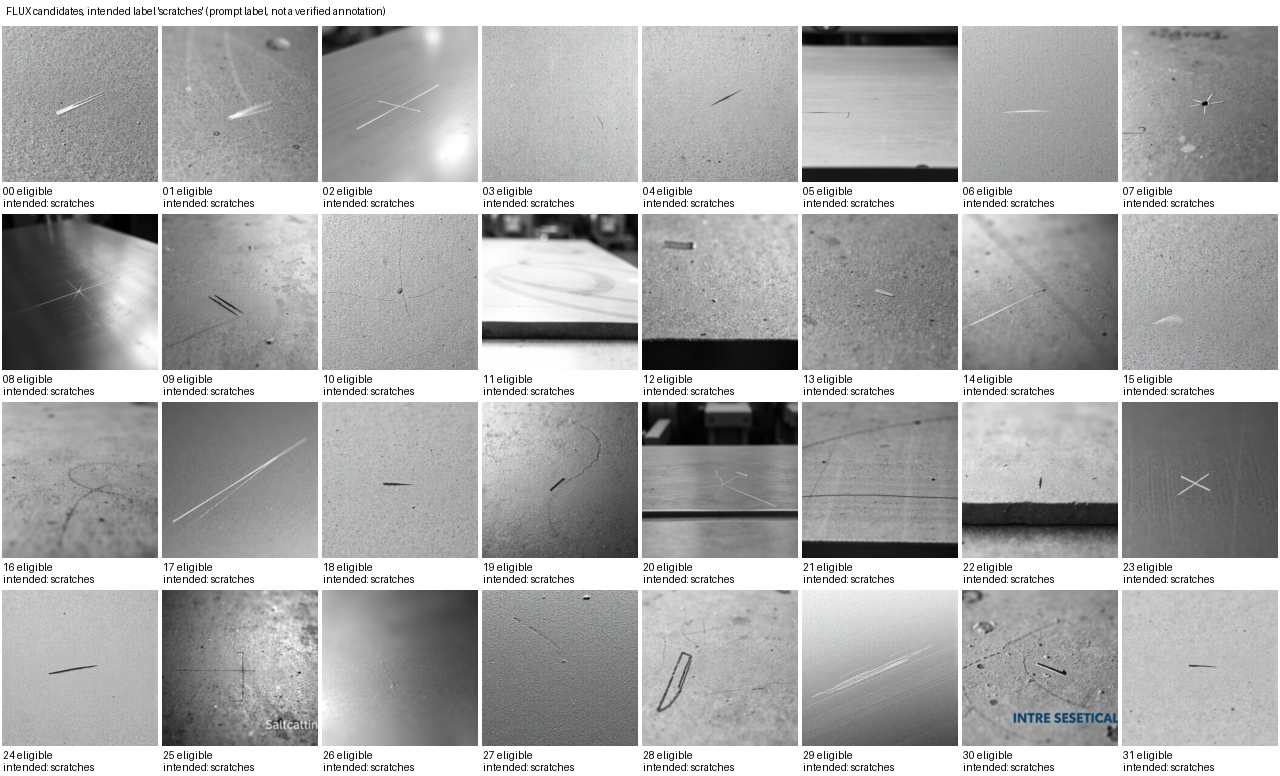

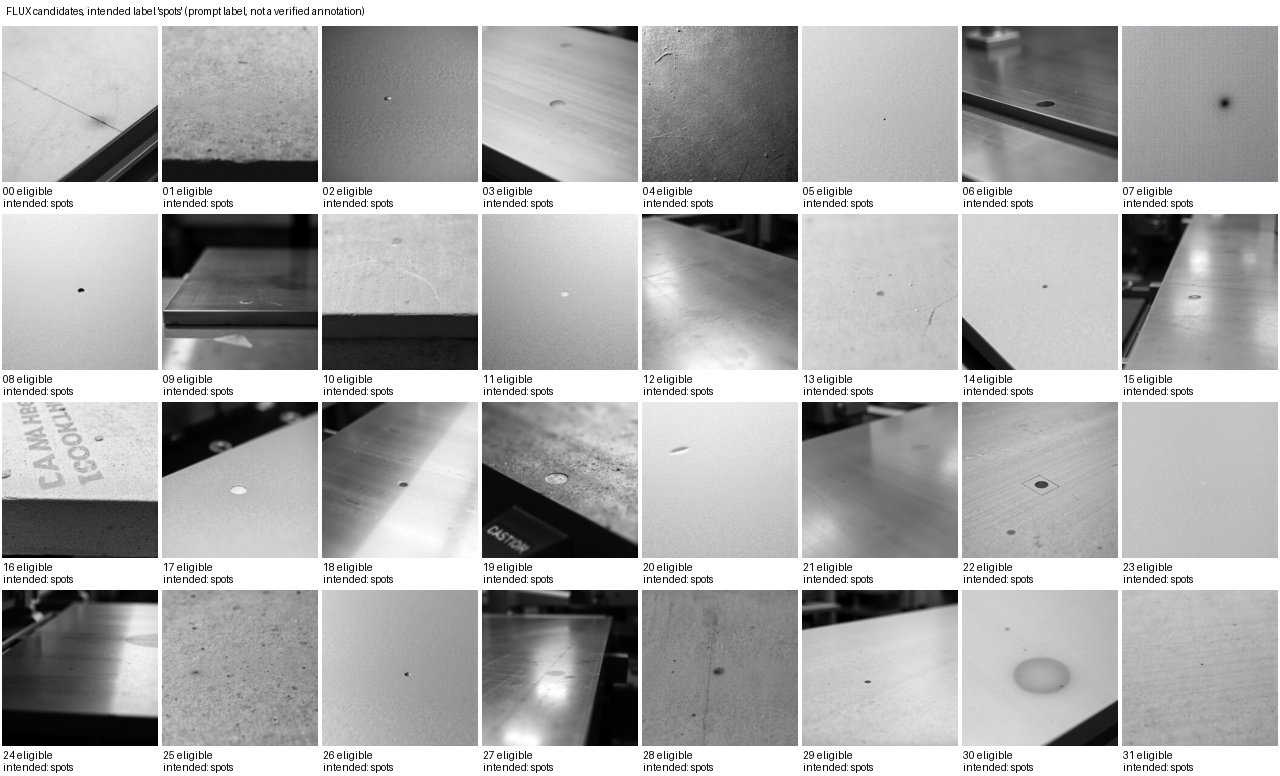

In [29]:
run_stage('flux', 'lab', 'stage_flux.py')
GEN = load('generation_manifest.jsonl')
STATUS = load('generation_status.json')
print('usable candidates per class:', STATUS['usable'], '| complete:', STATUS['complete'], '|', '; '.join(STATUS['shortfall']) or 'no shortfall')
table(['status', 'reason', 'count'], [[s, r or '', sum(1 for g in GEN if g['status'] == s and g['reason'] == r)] for s, r in sorted({(g['status'], g['reason']) for g in GEN})])
for label in order[1:]:
    show(f'generated_{label}.png')


**What to notice, and questions to answer while looking (execution does not pause):**

1. Do the candidates share the Bosch images' horizontal banding, grain and lighting, or do they look like a generic "metal surface"? This gap between generated and real images is **domain mismatch**.
2. In how many `scratches` candidates can you actually see a scratch? A spot? Is any candidate plainly the wrong class, or defect-free?
3. The label under each thumbnail is the *intended* label. If you disagree with some, that is label noise the classifier will learn from in arm C.
4. Would you trust these images more if they looked more realistic? Why is realism not the same as usefulness?

An optional human-review extension (Section 13) lets you record accept / reject / uncertain for each candidate and run a separately identified experiment. It never changes the canonical results.


> **Check your reasoning.** Why does the notebook refuse to filter candidates by how confidently a classifier recognises them?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Filtering by classifier confidence keeps only the generated images that already look like what a classifier expects. That makes the synthetic pool easier and more similar to the real training data, and it uses a model's judgement where the experiment claims to be testing unfiltered generation. Tuned against validation or test scores, it would also leak held-out information into training. A fixed, minimal eligibility rule keeps the pool honest; human review is allowed only as a separately labelled extension.

</details>


## 7 · Synthetic features and the synthetic-to-training audit  <sub>(evaluation practice)</sub>

Each eligible candidate is converted to grayscale, letterboxed from 512 px to 224 px and passed through the same frozen ResNet-18, with four fixed augmented views, exactly as the real images were. Before any fitting, every candidate's thumbnail is compared with every **training-partition** image: a correlation of 0.98 or more would mean FLUX reproduced a real training photograph. Matches are reported, not used to filter.


In [30]:
run_stage('features_synthetic', 'lab', 'stage_features.py', '--part', 'synthetic')
AUDIT = load('synthetic_training_overlap.json')
print(f"highest candidate-to-training correlation: {fmt(AUDIT['max_correlation'])}; flagged at >= {AUDIT['threshold']}: {len(AUDIT['flagged'])}")


synthetic pool: 64 eligible candidates (converted to grayscale, letterboxed from 512 px)
synthetic-to-training audit: max correlation 0.9660395383834839, 0 flagged at >= 0.98
{"device":"cuda","seconds":7.1,"synthetic":64}

[features_synthetic] 8.6 s | peak child RSS 1071 MiB | peak GPU in use 841 MiB | lowest host memory available 9233 MiB | disk free 187.1 GB
highest candidate-to-training correlation: 0.966; flagged at >= 0.98: 0


**What to notice.** A text-to-image model that never saw these photographs is not expected to reproduce one, so the highest correlation should sit well below 0.98. It is still worth checking, because a generator trained on web images may have seen public datasets; the notebook cannot rule out pretraining overlap for Phi-4, FLUX or ResNet-18.


## 8 · Three matched arms, validation selection and a frozen experiment  <sub>(evaluation practice)</sub>

This is the controlled comparison. For each seed (17, 29, 43), `slot_schedule` (core section *Matched training schedule*) draws every random number the three arms need **once**: 30 epochs × 32 updates × 32 slots = 30,720 training slots, each batch holding 11 / 11 / 10 slots of the three classes, rotating which class gets 10. Every slot has a class, a real-image index, a view index, a coin and a synthetic-image index. The arms then differ only in where a slot's features come from:

- **A** uses the real image's deterministic features;
- **B** uses one of the real image's four fixed augmented views;
- **C** does the same as B, except that a **defect** slot whose coin is below 0.5 uses a synthetic candidate's view instead. Normal slots are always real.

So every arm sees the same number of updates, the same class balance and the same head initialisation per seed. C does not get more training; it gets a different distribution of defect examples. The head is fitted with AdamW (learning rate 0.001, weight decay 0.0001), batch 32, on the CPU with deterministic algorithms. After each epoch it is scored on **validation**; the epoch with the highest validation macro-F1 is kept (the earlier epoch wins a tie). Among the arms fitted with the canonical seed 17, the one with the highest validation macro-F1 is chosen for export (ties go to A, then B, then C).

Then the experiment is **frozen**: `experiment_config.json` records every setting and the SHA-256 of every input (split, prompts, generation manifest, features, heads, the thumbnail signatures used by the overlap audit) and of the code that defines preprocessing, fitting, evaluation and export (the shared core and every stage script). The test, export and reload stages refuse to run if any of them changes, and every held-out image is re-checked against its recorded digests before it is scored.

**Predict first:** on validation, will C beat B for every seed, some seeds, or none?


The next three cells save the stages that run **after** the freeze: the test stage (Section 9), the export stage and the fresh-process reload stage (Section 11). They are saved here, before the fit, so that the freeze binds their code together with the core, the data, feature and fitting stages: changing any of them afterwards makes the test, export and reload stages refuse to run. The test stage starts by verifying the frozen record and re-checking every test image against its recorded digests.


In [31]:
%%writefile work/sdi_capstone/stage_evaluate.py
"""Stage 7 (lab environment): verify the frozen experiment, then score every arm and seed once on the test partition."""
# ruff: noqa: E501
from __future__ import annotations

import csv
import sys
import time
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402
import stage_features as sf  # noqa: E402


def main(cfg_path: str) -> None:
    cfg = core.read_json(cfg_path)
    base, work, out = Path(cfg["base_dir"]), Path(cfg["work_dir"]), Path(cfg["out_dir"])
    started = time.time()
    record = core.verify_frozen(out / "experiment_config.json", base)
    print(f"frozen record verified ({len(record['frozen_files'])} inputs unchanged); scoring the test partition once")
    import torch
    from PIL import Image
    from safetensors.numpy import load_file

    order, seeds, arms = record["class_order"], record["seeds"], record["arms_run"]
    k = len(order)
    rows = core.read_split_manifest(out / "split_manifest.csv")
    data_root = work / "data" / ("sdi" if cfg["data_source"] == "bosch" else "byod")
    test = sorted((r for r in rows if r["split"] == "test"), key=lambda r: r["image_id"])
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = sf.build_backbone(sf.stage_backbone(work), device)
    # Each test image is re-verified against the frozen manifest's file and pixel digests before it is scored.
    x = sf.embed(model, [core.load_verified_gray(data_root / r["relpath"], r) for r in test], device)
    y = np.array([order.index(r["label"]) for r in test])
    groups = [r["group_id"] for r in test]

    predictions, scores, per_run = {}, {}, {}
    majority = order.index(record["majority_class"])
    for seed in seeds:
        predictions[("majority", seed)] = np.full_like(y, majority)
        scores[("majority", seed)] = np.eye(k, dtype=np.float32)[np.full_like(y, majority)]
        for arm in arms:
            head = load_file(str(base / record["validation"][arm][str(seed)]["head"]))
            logits = core.head_logits(x, head["weight"], head["bias"])
            predictions[(arm, seed)] = logits.argmax(1)
            scores[(arm, seed)] = core.softmax(logits)
    for (arm, seed), pred in predictions.items():
        per_run.setdefault(arm, {})[str(seed)] = core.metrics_from_confusion(core.confusion_matrix(y, pred, k), order)
    summary = {}
    for arm, runs in per_run.items():
        summary[arm] = {m: {"mean": float(np.mean([r[m] for r in runs.values()])), "min": float(np.min([r[m] for r in runs.values()])), "max": float(np.max([r[m] for r in runs.values()])), "per_seed": {s: r[m] for s, r in runs.items()}} for m in ("macro_f1", "balanced_accuracy", "accuracy")}
    contrasts = {}
    if "C" in arms:
        contrasts["C - B"] = core.paired_contrast(predictions, y, groups, arm="C", reference="B", seeds=seeds, k=k)
    contrasts["B - A"] = core.paired_contrast(predictions, y, groups, arm="B", reference="A", seeds=seeds, k=k)

    # Held-out overlap audit, run only now that everything is frozen. A consequential match is reported, not removed.
    sig = np.load(work / "audit" / "signatures.npz")
    split_of = {r["image_id"]: r["split"] for r in rows}
    held = np.array([split_of.get(i) in ("val", "test") for i in sig["image_id"]])
    generated = [r for r in core.read_jsonl(out / "generation_manifest.jsonl") if r["status"] == "eligible"]
    synth_sigs = np.stack([core.signature(Image.open(out / r["file"]).convert("L")) for r in generated]) if generated else np.zeros((0, core.SIGNATURE_SIDE**2), np.float32)
    best, where = core.max_similarity(synth_sigs, sig["signature"][held].astype(np.float32))
    held_ids = sig["image_id"][held]
    flagged = [{"candidate_id": generated[n]["candidate_id"], "closest_heldout_image": str(held_ids[where[n]]), "correlation": round(float(best[n]), 4)} for n in np.nonzero(best >= core.NEAR_DUPLICATE_THRESHOLD)[0]]
    pixel_split: dict = {}
    for r in rows:
        if r["split"] in ("train", "val", "test"):
            pixel_split.setdefault(r["pixel_sha256"], set()).add(r["split"])
    cross_pixels = sum(1 for s in pixel_split.values() if len(s) > 1)
    overlap = {"synthetic_vs_heldout": {"max_correlation": float(best.max()) if len(best) else None, "flagged": flagged}, "exact_pixel_duplicates_across_partitions": cross_pixels}
    valid = not flagged and cross_pixels == 0
    metrics = {
        "evidence": f"tutorial evidence from one grouped split ({core.read_json(out / 'data_manifest.json')['experiment_scope']}) and one generated pool; not factory-level or production performance",
        "test_counts": {c: int((y == i).sum()) for i, c in enumerate(order)},
        "arms": {a: core.ARM_NAMES[a] for a in per_run},
        "per_run": per_run, "summary": summary, "contrasts": contrasts,
        "interval_note": "approximate 95% percentile interval from 1,000 class-stratified group bootstrap resamples of the test partition, paired across arms; conditional on this split and generated pool; it does not include training or generation variability",
        "decision_rule": "argmax of the linear head's logits (no threshold tuning); scores are softmax of uncalibrated logits, not calibrated probabilities",
        "overlap_audit": overlap, "comparison_valid": valid,
        "validity_note": "" if valid else "a held-out overlap was found after freezing; the comparison is reported as invalid rather than repaired",
        "generation_complete": record["generation_status"]["complete"], "smoke_run": record["smoke_run"],
        "frozen_record_sha256": record["record_sha256"], "seconds": round(time.time() - started, 1),
    }
    core.write_json(out / "metrics.json", metrics)
    with open(out / "predictions.csv", "w", encoding="utf-8", newline="") as handle:
        writer = csv.writer(handle, lineterminator="\n")
        writer.writerow(["arm", "seed", "image_id", "group_id", "true_label", "predicted_label", *[f"score_{c}" for c in order]])
        for (arm, seed), pred in sorted(predictions.items(), key=lambda kv: (["majority", *core.ARMS].index(kv[0][0]), kv[0][1])):
            for n, r in enumerate(test):
                writer.writerow([arm, seed, r["image_id"], r["group_id"], r["label"], order[pred[n]], *[f"{v:.6f}" for v in scores[(arm, seed)][n]]])

    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    figures = out / "figures"
    shown = ["majority", *arms]
    fig, axes = plt.subplots(len(shown), len(seeds), figsize=(3.1 * len(seeds), 2.9 * len(shown)), squeeze=False)
    for i, arm in enumerate(shown):
        for j, seed in enumerate(seeds):
            cm = np.array(per_run[arm][str(seed)]["confusion"])
            ax = axes[i][j]
            ax.imshow(np.log1p(cm), cmap="Blues")
            for (a, b), v in np.ndenumerate(cm):
                ax.text(b, a, str(v), ha="center", va="center", fontsize=9)
            ax.set_xticks(range(k), order, fontsize=7)
            ax.set_yticks(range(k), order, fontsize=7)
            ax.set_title(f"{core.ARM_NAMES[arm]}\nseed {seed}, macro-F1 {per_run[arm][str(seed)]['macro_f1']:.3f}", fontsize=8)
            ax.set_xlabel("predicted", fontsize=7)
            ax.set_ylabel("true", fontsize=7)
    fig.tight_layout()
    fig.savefig(figures / "confusion_matrices.png", dpi=110)
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    for i, arm in enumerate(shown):
        values = [per_run[arm][str(s)]["macro_f1"] for s in seeds]
        ax.scatter([i] * len(values), values, color="0.2", zorder=3)
        ax.hlines(np.mean(values), i - 0.25, i + 0.25, color="tab:blue")
    ax.set_xticks(range(len(shown)), [core.ARM_NAMES[a] for a in shown], fontsize=7)
    ax.set_ylabel("test macro-F1")
    ax.set_title("Each dot is one seed; the bar is the mean", fontsize=9)
    fig.tight_layout()
    fig.savefig(figures / "macro_f1_by_arm.png", dpi=110)
    plt.close(fig)
    # Error gallery for the canonical seed (test images may be viewed now that the experiment is frozen).
    canon = record["selection"]["seed"]
    items = []
    for arm in [a for a in ("B", "C") if a in arms]:
        wrong = [n for n in range(len(test)) if predictions[(arm, canon)][n] != y[n] and y[n] != majority][:6] + [n for n in range(len(test)) if predictions[(arm, canon)][n] != y[n] and y[n] == majority][:2]
        items += [(core.load_verified_gray(data_root / test[n]["relpath"], test[n]), f"{arm}: true {order[y[n]]}\npred {order[predictions[(arm, canon)][n]]}") for n in wrong]
    if items:
        core.contact_sheet(items, title=f"Misclassified TEST images, seed {canon} (arm: true -> predicted)").save(figures / "error_gallery.png")
    print(core.canonical_json({"macro_f1_mean": {a: round(s["macro_f1"]["mean"], 4) for a, s in summary.items()}, "contrasts": {c: [round(v["mean_difference"], 4), [round(z, 4) for z in v["interval_95"]]] for c, v in contrasts.items()}, "comparison_valid": valid}))


if __name__ == "__main__":
    core.run_main(main, sys.argv[1])


Writing work/sdi_capstone/stage_evaluate.py


In [32]:
%%writefile work/sdi_capstone/stage_export.py
"""Stage 8 (lab environment): export the validation-selected canonical-seed classifier and its reference logits."""
# ruff: noqa: E501
from __future__ import annotations

import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402
import stage_features as sf  # noqa: E402

REFERENCE_PER_CLASS = 3


def reference_rows(rows: list[dict], order: list[str]) -> list[dict]:
    """Fixed real examples for the reload check: the first three test images of each class by image id."""
    test = sorted((r for r in rows if r["split"] == "test"), key=lambda r: r["image_id"])
    return [r for label in order for r in [x for x in test if x["label"] == label][:REFERENCE_PER_CLASS]]


def main(cfg_path: str) -> None:
    cfg = core.read_json(cfg_path)
    base, work, out = Path(cfg["base_dir"]), Path(cfg["work_dir"]), Path(cfg["out_dir"])
    record = core.verify_frozen(out / "experiment_config.json", base)
    from safetensors.numpy import load_file

    selection, order = record["selection"], record["class_order"]
    head = load_file(str(base / record["validation"][selection["arm"]][str(selection["seed"])]["head"]))
    manifest = {
        "classes": order,
        "class_index": {c: i for i, c in enumerate(order)},
        "decision_rule": core.DECISION_RULE,
        "backbone": sf.BACKBONE,
        "preprocessing": core.PREPROCESSING,
        "selection": {**selection, "arm_name": core.ARM_NAMES[selection["arm"]]},
        "experiment_record_sha256": record["record_sha256"],
        "training_data": "no images or features are embedded; the head was fitted on features of the selected training budget (and, for arm C, generated images)",
        "intended_use": "tutorial reconstruction and inference on product-A-like surface images; not a production inspection system",
    }
    rows = core.read_split_manifest(out / "split_manifest.csv")
    ref = reference_rows(rows, order)
    data_root = work / "data" / ("sdi" if cfg["data_source"] == "bosch" else "byod")
    model = sf.build_backbone(sf.stage_backbone(work), "cpu")  # CPU on both sides of the reload check
    feats = sf.embed(model, [core.load_verified_gray(data_root / r["relpath"], r) for r in ref], "cpu")
    logits = core.head_logits(feats, head["weight"], head["bias"])
    # Expected decisions are named with the frozen experiment's class order, not the artifact's own list.
    core.write_json(out / "reload_reference.json", {"device": "cpu", "tolerance": core.PARITY_TOLERANCE, "examples": [{"image_id": r["image_id"], "relpath": r["relpath"], "label": r["label"], "expected_prediction": order[int(logits[n].argmax())], "logits": [float(v) for v in logits[n]]} for n, r in enumerate(ref)]})
    manifest["reload_reference_sha256"] = core.sha256_file(out / "reload_reference.json")
    written = core.write_artifact(out / "classifier", head["weight"], head["bias"], manifest)
    core.check_artifact_semantics(written, record=record, preprocessing=core.PREPROCESSING, backbone=sf.BACKBONE)
    print(core.canonical_json({"exported": written["selection"], "head_sha256": written["files"][core.ARTIFACT_WEIGHTS]["sha256"], "reference_examples": len(ref)}))


if __name__ == "__main__":
    core.run_main(main, sys.argv[1])


Writing work/sdi_capstone/stage_export.py


In [33]:
%%writefile work/sdi_capstone/stage_reload.py
"""Stage 9 (fresh lab process): rebuild inference from the exported files alone, check logit parity, then score new images.

Nothing from the training process is imported or unpickled: the head comes from safetensors, the backbone from its
digest-verified safetensors file, and preprocessing from the definition in sdi_core.
"""
# ruff: noqa: E501
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path(__file__).resolve().parent))
import sdi_core as core  # noqa: E402
import stage_features as sf  # noqa: E402

NEW_PER_CLASS = 2


def main(cfg_path: str) -> None:
    cfg = core.read_json(cfg_path)
    base, work, out = Path(cfg["base_dir"]), Path(cfg["work_dir"]), Path(cfg["out_dir"])
    weight, bias, manifest = core.load_artifact(out / "classifier")
    # Meaning before numbers: the artifact must name the frozen experiment, its class order and indices, decision
    # rule, preprocessing, backbone and selected head. A relabelled class list would leave every logit unchanged.
    record = core.verify_frozen(out / "experiment_config.json", base)
    core.check_artifact_semantics(manifest, record=record, preprocessing=core.PREPROCESSING, backbone=sf.BACKBONE)
    reference_path = out / "reload_reference.json"
    if core.sha256_file(reference_path) != manifest.get("reload_reference_sha256"):
        raise core.ContractError("reload_reference.json differs from the reference recorded in the artifact manifest")
    model = sf.build_backbone(sf.stage_backbone(work), "cpu")
    data_root = work / "data" / ("sdi" if cfg["data_source"] == "bosch" else "byod")
    rows = core.read_split_manifest(out / "split_manifest.csv")
    by_id = {r["image_id"]: r for r in rows}
    reference = core.read_json(reference_path)
    feats = sf.embed(model, [core.load_verified_gray(data_root / e["relpath"], by_id[e["image_id"]]) for e in reference["examples"]], "cpu")
    order = manifest["classes"]
    expected = np.array([e["logits"] for e in reference["examples"]], dtype=np.float32)
    parity = core.replay_check(core.head_logits(feats, weight, bias), expected, [e["expected_prediction"] for e in reference["examples"]], order)
    parity["semantic_checks"] = "classes, class_index, decision rule, preprocessing, backbone, experiment record and selected head match the frozen experiment"
    print(f"semantic checks: PASS ({parity['semantic_checks']})")
    print(f"reload parity: max |logit difference| = {parity['max_abs_logit_difference']:.2e} (tolerance {core.PARITY_TOLERANCE:.0e}); replayed decisions identical: {parity['same_predictions']} -> {'PASS' if parity['passed'] else 'FAIL'}")
    if not parity["passed"]:
        core.write_json(out / "reload_parity.json", parity)
        raise core.ContractError("the reloaded classifier does not reproduce the exported logits and decisions; the artifact is not trustworthy")

    # New-image inference: training-partition images never used for fitting, captioning or generation, plus any
    # images in NEW_IMAGE_DIR. Unknown labels stay empty. An empty cohort is recorded as not run, never as run.
    unused = [r for r in rows if r["split"] == "train" and not r["selected"]]
    chosen = []
    for label in order:
        pool = sorted((r for r in unused if r["label"] == label), key=lambda r: core.sha256_bytes(f"new|{r['file_sha256']}".encode()))
        chosen += [(r["image_id"], data_root / r["relpath"], label, "unused training-partition image", r) for r in pool[:NEW_PER_CLASS]]
    new_dir = cfg.get("new_image_dir") or ""
    rejected = []
    if new_dir:
        for p in sorted(Path(new_dir).iterdir()):
            if p.suffix.lower() in core.IMAGE_SUFFIXES and p.is_file():
                chosen.append((p.stem, p, "", "NEW_IMAGE_DIR", None))
    results = []
    for image_id, path, label, source, row in chosen:
        info = core.inspect_image(path)
        if not info["decode_ok"]:
            rejected.append({"image": str(path), "reason": info["error"]})
            continue
        image, mode = (core.load_verified_gray(path, row), info["mode"]) if row is not None else core.load_gray(path)
        score = core.softmax(core.head_logits(sf.embed(model, [image], "cpu"), weight, bias))[0]
        results.append({"image_id": image_id, "source": source, "known_label": label, "input_mode": mode, "input_size": f"{info['width']}x{info['height']}", "predicted_label": order[int(score.argmax())], **{f"score_{c}": round(float(score[i]), 6) for i, c in enumerate(order)}})
    core.write_new_predictions(out / "new_image_predictions.csv", results, order)
    status = "ran" if results else ("not_run_all_inputs_rejected" if chosen else "not_run_no_inputs")
    parity["new_image_inference"] = {"status": status, "scored": len(results), "candidates": len(chosen), "rejected": rejected}
    core.write_json(out / "reload_parity.json", parity)
    for r in results:
        print(f"{r['image_id']:<22} known={r['known_label'] or '?':<10} predicted={r['predicted_label']:<10} " + " ".join(f"{c}={r['score_' + c]:.3f}" for c in order))
    if rejected:
        print(f"rejected {len(rejected)} new image(s): {rejected}")
    if not results:
        print(f"new-image inference NOT RUN ({status}): no unused training-partition images and no usable NEW_IMAGE_DIR images. "
              "The export and reload checks above still stand; set NEW_IMAGE_DIR to score your own images.")


if __name__ == "__main__":
    core.run_main(main, sys.argv[1])


Writing work/sdi_capstone/stage_reload.py


In [34]:
run_stage('fit', 'lab', 'stage_fit.py')
RECORD = load('experiment_config.json')
table(['arm', 'seed', 'kept epoch', 'val macro-F1', 'val balanced acc.', 'synthetic share of defect slots'],
      [[a, s, r['selected_epoch'], fmt(r['val']['macro_f1']), fmt(r['val']['balanced_accuracy']), fmt(r['synthetic_share_of_defect_slots'], 2)]
       for a in RECORD['arms_run'] for s, r in RECORD['validation'][a].items()])
print('export choice:', RECORD['selection'])
print(f"frozen: {len(RECORD['frozen_files'])} inputs pinned, record SHA-256 {RECORD['record_sha256'][:16]}...; smoke run: {RECORD['smoke_run']}")


seed 17 arm A: epoch 26 val macro-F1 0.6393 (synthetic share of defect slots 0.000)
seed 17 arm B: epoch 29 val macro-F1 0.6376 (synthetic share of defect slots 0.000)
seed 17 arm C: epoch 29 val macro-F1 0.6624 (synthetic share of defect slots 0.503)
seed 29 arm A: epoch 13 val macro-F1 0.6295 (synthetic share of defect slots 0.000)
seed 29 arm B: epoch 29 val macro-F1 0.6240 (synthetic share of defect slots 0.000)
seed 29 arm C: epoch  2 val macro-F1 0.6662 (synthetic share of defect slots 0.504)
seed 43 arm A: epoch 20 val macro-F1 0.6349 (synthetic share of defect slots 0.000)
seed 43 arm B: epoch 20 val macro-F1 0.6288 (synthetic share of defect slots 0.000)
seed 43 arm C: epoch 25 val macro-F1 0.6617 (synthetic share of defect slots 0.503)
experiment frozen: record SHA-256 1faf8309451942a9..., 32 inputs pinned; export choice {'seed': 17, 'arm': 'C', 'val_macro_f1': 0.6624085603728312, 'epoch': 29, 'rule': 'canonical seed; highest validation macro-F1; ties favour A, then B, then C

| arm | seed | kept epoch | val macro-F1 | val balanced acc. | synthetic share of defect slots |
|---|---|---|---|---|---|
| A | 17 | 26 | 0.639 | 0.810 | 0.00 |
| A | 29 | 13 | 0.630 | 0.781 | 0.00 |
| A | 43 | 20 | 0.635 | 0.795 | 0.00 |
| B | 17 | 29 | 0.638 | 0.805 | 0.00 |
| B | 29 | 29 | 0.624 | 0.783 | 0.00 |
| B | 43 | 20 | 0.629 | 0.784 | 0.00 |
| C | 17 | 29 | 0.662 | 0.786 | 0.50 |
| C | 29 | 2 | 0.666 | 0.756 | 0.50 |
| C | 43 | 25 | 0.662 | 0.786 | 0.50 |

export choice: {'arm': 'C', 'epoch': 29, 'rule': 'canonical seed; highest validation macro-F1; ties favour A, then B, then C', 'seed': 17, 'val_macro_f1': 0.6624085603728312}
frozen: 32 inputs pinned, record SHA-256 1faf8309451942a9...; smoke run: False


**What to notice.** About half of the defect slots in arm C are synthetic, as designed; A and B have none. Kept epochs vary by arm and seed. Validation scores were used to choose epochs and the export, so they are slightly optimistic and are *not* the evidence for the question; the test set is. If generation fell short, arm C is absent and the notebook says so instead of comparing.


> **Check your reasoning.** Why not simply add the 64 synthetic images to the training set of arm B and train for the same number of epochs?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Adding images changes several things at once: the number of defect examples, the class balance, and (with a fixed number of epochs) the number of updates. Any difference in the result could come from any of these. Substituting synthetic images into a fixed slot schedule keeps updates, batch composition, class prior and random draws identical, so a difference between C and B can be attributed to the change in the defect-image distribution.

</details>


## 9 · One final comparison on real test photographs  <sub>(evaluation practice)</sub>

The test stage first verifies the frozen record, then extracts features for the test partition (never seen until now), scores every arm and seed once, and computes:

- **macro-F1** (primary), balanced accuracy, accuracy, and per-class precision, recall, F1 and support for each arm and seed;
- the **C − B** contrast (primary) and **B − A** (context): the mean over seeds of the macro-F1 difference, with an approximate 95% interval from 1,000 **paired, class-stratified group bootstrap** resamples of the test set (every arm is scored on the same resamples; groups, not images, are resampled);
- after freezing, an **overlap audit** of every synthetic candidate against validation and test images and a check that no exact duplicate crosses partitions. A consequential match marks the comparison invalid; it is never quietly removed.

The decision rule is argmax over the head's logits. Softmax scores in `predictions.csv` are uncalibrated and are not probabilities of a defect.

Scoring the test set again after changing something, and picking the better result, would turn it into a second validation set. The notebook therefore scores it once.


frozen record verified (32 inputs unchanged); scoring the test partition once
{"comparison_valid":true,"contrasts":{"B - A":[-0.0045,[-0.0244,0.0161]],"C - B":[0.0443,[0.0193,0.0671]]},"macro_f1_mean":{"A":0.6472,"B":0.6427,"C":0.687,"majority":0.3219}}

[evaluate] 20.4 s | peak child RSS 1312 MiB | peak GPU in use 841 MiB | lowest host memory available 9011 MiB | disk free 187.1 GB
test counts: {'normal': 1237, 'scratches': 67, 'spots': 21} | comparison valid: True 


| arm | macro-F1 seed 17 | macro-F1 seed 29 | macro-F1 seed 43 | mean | range | balanced acc. (mean) | accuracy (mean) |
|---|---|---|---|---|---|---|---|
| A: real-only | 0.651 | 0.641 | 0.650 | 0.647 | 0.641–0.651 | 0.830 | 0.913 |
| B: conventional augmentation | 0.645 | 0.639 | 0.644 | 0.643 | 0.639–0.645 | 0.837 | 0.911 |
| C: synthetic augmentation | 0.687 | 0.695 | 0.679 | 0.687 | 0.679–0.695 | 0.833 | 0.931 |
| majority baseline | 0.322 | 0.322 | 0.322 | 0.322 | 0.322–0.322 | 0.333 | 0.934 |

B - A: mean difference -0.0045 (per seed -0.0060, -0.0015, -0.0059); approximate 95% interval [-0.0244, +0.0161] -> the interval includes zero: no clear difference in this run
C - B: mean difference +0.0443 (per seed +0.0415, +0.0559, +0.0355); approximate 95% interval [+0.0193, +0.0671] -> the interval is above zero


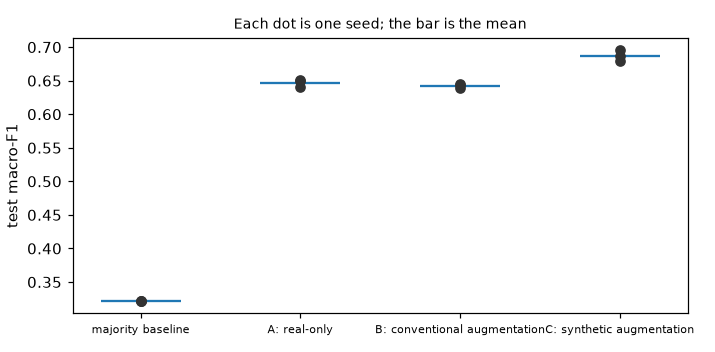

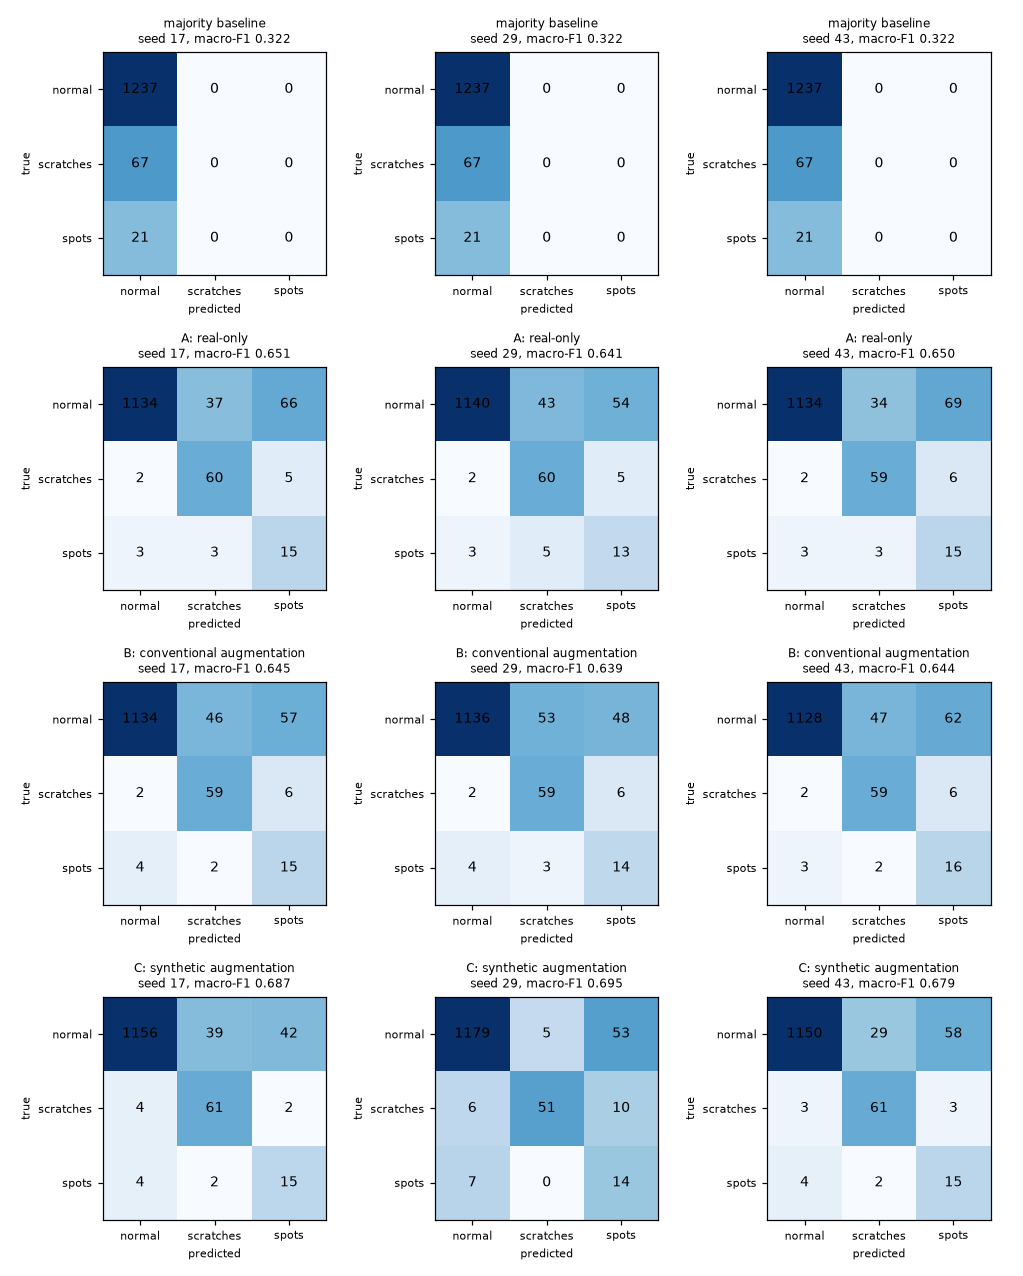

In [35]:
run_stage('evaluate', 'lab', 'stage_evaluate.py')
METRICS = load('metrics.json')
print('test counts:', METRICS['test_counts'], '| comparison valid:', METRICS['comparison_valid'], METRICS['validity_note'])
rows = []
for arm, summ in METRICS['summary'].items():
    rows.append([METRICS['arms'][arm], *[fmt(summ['macro_f1']['per_seed'][str(s)]) for s in RECORD['seeds']], fmt(summ['macro_f1']['mean']),
                 f"{fmt(summ['macro_f1']['min'])}–{fmt(summ['macro_f1']['max'])}", fmt(summ['balanced_accuracy']['mean']), fmt(summ['accuracy']['mean'])])
table(['arm', *[f'macro-F1 seed {s}' for s in RECORD['seeds']], 'mean', 'range', 'balanced acc. (mean)', 'accuracy (mean)'], rows)
for name, c in METRICS['contrasts'].items():
    lo, hi = c['interval_95']
    verdict = 'the interval includes zero: no clear difference in this run' if lo <= 0 <= hi else ('the interval is above zero' if lo > 0 else 'the interval is below zero')
    print(f"{name}: mean difference {c['mean_difference']:+.4f} (per seed {', '.join(f'{v:+.4f}' for v in c['per_seed'].values())}); "
          f"approximate 95% interval [{lo:+.4f}, {hi:+.4f}] -> {verdict}")
show('macro_f1_by_arm.png')
show('confusion_matrices.png')


**What to notice.** Read the per-seed columns before the mean: if the sign of C − B changes between seeds, the mean hides disagreement. Compare the interval's width with the difference itself. The interval is **conditional on this split and this generated pool**: it reflects which test groups happened to be drawn, not what would happen with a different split, a new set of 64 generated images or another factory. In the confusion matrices, look at where each arm's errors go: false alarms on `normal`, missed defects, or scratch/spot confusion.


> **Check your reasoning.** Why does the bootstrap resample groups rather than individual images, and why are the arms scored on the same resamples?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Images in one group are near-copies, so they are not independent evidence; resampling them one by one would pretend there is more independent data than there is and make the interval too narrow. Scoring every arm on the same resample pairs the comparison: the difference C − B is computed on identical test images each time, so variation that affects both arms equally (an unusually hard set of spot images) cancels out instead of widening the interval.

</details>


## 10 · Error analysis, uncertainty and a bounded conclusion  <sub>(interpretation)</sub>

Now that the experiment is frozen, test images may be inspected. The gallery shows misclassified test images for the canonical seed in arms B and C.


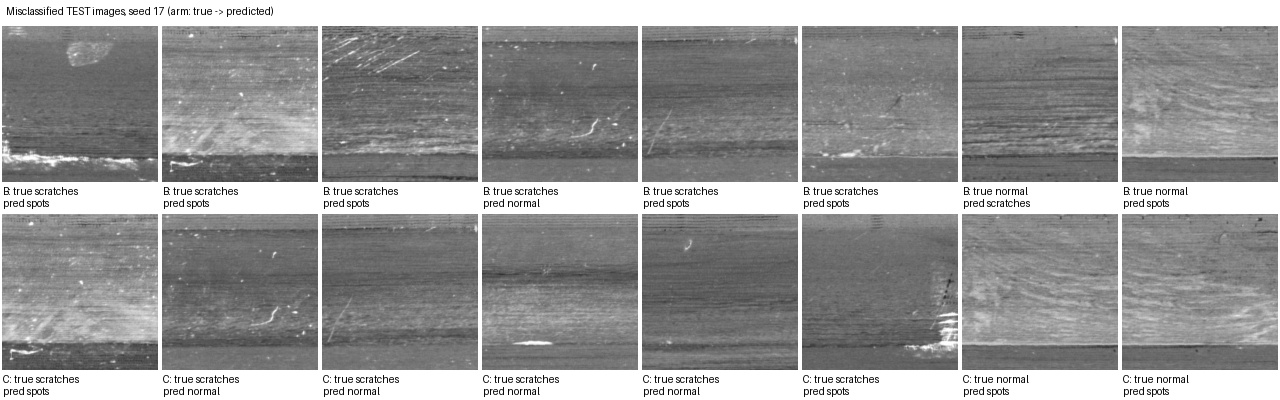

| arm (canonical seed) | class | precision | recall | F1 | support | predicted |
|---|---|---|---|---|---|---|
| A | normal | 0.996 | 0.917 | 0.955 | 1237 | 1139 |
| A | scratches | 0.600 | 0.896 | 0.719 | 67 | 100 |
| A | spots | 0.174 | 0.714 | 0.280 | 21 | 86 |
| B | normal | 0.995 | 0.917 | 0.954 | 1237 | 1140 |
| B | scratches | 0.551 | 0.881 | 0.678 | 67 | 107 |
| B | spots | 0.192 | 0.714 | 0.303 | 21 | 78 |
| C | normal | 0.993 | 0.935 | 0.963 | 1237 | 1164 |
| C | scratches | 0.598 | 0.910 | 0.722 | 67 | 102 |
| C | spots | 0.254 | 0.714 | 0.375 | 21 | 59 |
| majority | normal | 0.934 | 1.000 | 0.966 | 1237 | 1325 |
| majority | scratches | — | 0.000 | 0.000 | 67 | 0 |
| majority | spots | — | 0.000 | 0.000 | 21 | 0 |

undefined metrics (no predictions of that class): {'majority': ['scratches.precision', 'spots.precision']}


In [36]:
show('error_gallery.png')
rows = []
for arm in METRICS['per_run']:
    r = METRICS['per_run'][arm][str(RECORD['selection']['seed'])]
    for c in order:
        pc = r['per_class'][c]
        rows.append([arm, c, fmt(pc['precision']), fmt(pc['recall']), fmt(pc['f1']), pc['support'], pc['predicted']])
table(['arm (canonical seed)', 'class', 'precision', 'recall', 'F1', 'support', 'predicted'], rows)
undefined = {a: r[str(RECORD['selection']['seed'])]['undefined'] for a, r in METRICS['per_run'].items() if r[str(RECORD['selection']['seed'])]['undefined']}
print('undefined metrics (no predictions of that class):', undefined or 'none')


**What to notice.** Precision for the majority baseline's defect classes is undefined (it never predicts them) and is reported as such, not as zero. A change of one or two spot predictions moves spot recall by about 0.05, because the test set has about 21 spots.

> **Check your reasoning.** Suppose C − B is +0.02 with an interval of [−0.01, +0.05]. Your manager asks: 'So synthetic defects work?' What do you answer?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Not established. On this split and this generated pool, the average difference favours synthetic substitution slightly, but the interval includes zero and the result may reverse with other test groups; it says nothing about other generated pools, other products or production. The honest statement is that this run found no clear evidence either way, and the next step is repeating the experiment with independently generated pools and another product (the P1 items in Section 13).

</details>

### Write your conclusion

Complete these sentences in your own words, using only numbers printed above:

1. **Task:** *On product A of the Bosch SDI dataset (or: on my own dataset, described by its source and classes), with 128 / 64 / 32 real training images and a frozen ResNet-18 with a linear head, we compared …*
2. **Principal result:** *Mean test macro-F1 was … for A, … for B and … for C; C − B was … (approximate 95% interval …), with per-seed differences of …*
3. **Baseline / reference:** *The majority baseline scored accuracy … but macro-F1 …*
4. **Important failure mode or uncertainty:** *Most remaining errors were …; the spot class rests on … test images; …*
5. **Limitations:** *One grouped split of one product without specimen metadata; one generated pool with intended, unverified labels; frozen models in 4-bit; no calibration; …*
6. **What would change my mind:** *…*

Your prediction from the start: was it right? What in the evidence would have to differ for the opposite conclusion?


## 11 · Export, fresh-process reload and new-image inference  <sub>(engineering)</sub>

The exported classifier is the validation-selected arm for the predeclared canonical seed 17, chosen from validation scores only. The artifact in `classifier/` contains `head.safetensors` (weight 3 × 512 and bias, float32) and `manifest.json` (format, class order and indices, decision rule, backbone identity with revision and SHA-256, preprocessing definition, selection record, file digests). No images or features are embedded.

The export stage also computes reference logits and the decisions they imply for nine fixed real test images on the CPU. The reload stage is a **new process** that imports nothing from training. It checks the manifest, the file set and every digest; checks the artifact's **meaning** against the frozen experiment (class names, order and indices, decision rule, preprocessing, backbone, the selected head and the experiment record); loads the head with `safetensors` (plain arrays; nothing is unpickled); rebuilds ResNet-18 from its verified weights; re-verifies each reference image against its recorded digests; recomputes the nine logits; and requires them to match within an absolute tolerance of 1e-5 **and** to name the same class for every example. It then scores new images: up to six unused training-partition images (two per class) that were never used for fitting, captioning or generation, plus any images in `NEW_IMAGE_DIR`. If your data has no spare training images and `NEW_IMAGE_DIR` is empty, this step is recorded as not run and the CSV has only its header.


In [37]:
run_stage('export', 'lab', 'stage_export.py')
run_stage('reload', 'lab', 'stage_reload.py')
PARITY = load('reload_parity.json')
print(f"reload parity: max |logit difference| {PARITY['max_abs_logit_difference']:.2e} <= {PARITY['tolerance']:.0e}; replayed decisions identical: {PARITY['same_predictions']} -> {PARITY['passed']}")
NEW = PARITY['new_image_inference']
print(f"new-image inference: {NEW['status']} ({NEW['scored']} scored of {NEW['candidates']} candidates, {len(NEW['rejected'])} rejected)")


{"exported":{"arm":"C","arm_name":"C: synthetic augmentation","epoch":29,"rule":"canonical seed; highest validation macro-F1; ties favour A, then B, then C","seed":17,"val_macro_f1":0.6624085603728312},"head_sha256":"b6df42478a81abc4612038375a048237a6bca4737dea4689fd710faa6b4fdd0c","reference_examples":9}

[export] 5.2 s | peak child RSS 780 MiB | peak GPU in use 0 MiB | lowest host memory available 9469 MiB | disk free 187.1 GB
semantic checks: PASS (classes, class_index, decision rule, preprocessing, backbone, experiment record and selected head match the frozen experiment)
reload parity: max |logit difference| = 0.00e+00 (tolerance 1e-05); replayed decisions identical: True -> PASS
A_ok_05010             known=normal     predicted=normal     normal=0.992 scratches=0.005 spots=0.003
A_ok_05488             known=normal     predicted=normal     normal=1.000 scratches=0.000 spots=0.000
A_sc_train_00062       known=scratches  predicted=scratches  normal=0.000 scratches=0.996 spots=0.004


**What to notice.** Parity compares numbers, not just file loading. The new-image table has one row per image with a known label where available, the predicted class and one uncalibrated score per class in the artifact's class order. Unused training-partition images are distinct from the fitted images but come from the same partition; they are an inference demonstration, not additional evidence.


> **Check your reasoning.** The reload stage loaded the files without error. Why is that not enough, and what does the parity check add?

<details><summary><b>Sample answer (open after you have answered)</b></summary>

Loading proves that files parse, not that they reproduce the classifier that was evaluated. Two different checks are needed. Numbers: recomputing logits for fixed real images in a new process and requiring agreement within 1e-5 shows the tensors, the pinned backbone file and the preprocessing code reproduce the exported outputs. Meaning: a reversed class list would leave every logit identical while swapping what the columns are called, so numeric parity cannot catch it. The reload stage therefore also checks the manifest against the frozen experiment (class order and indices, decision rule, preprocessing, backbone, selected head, experiment record) and requires every replayed decision to name the same class. What neither check covers: whether the preprocessing is right for new kinds of images, or whether the scores are calibrated.

</details>


## 12 · Records: environment, run summary, limitations and attribution  <sub>(engineering)</sub>

The last default cell writes the remaining records and prints a terminal summary. `run_summary.json` holds stage times, peak child memory, peak GPU memory in use, the lowest available host memory and disk use for every stage, measured in this runtime; they are measurements of this run, not guarantees for another.


In [38]:
# @title Write environment, run summary, limitations and attribution records
FLUX_STATE = json.loads((WORK / 'state' / 'flux_stage.json').read_text())
PHI4_STATE = json.loads((WORK / 'state' / 'phi4_stage.json').read_text())
FEATURE_STATE = json.loads((WORK / 'state' / 'features_stage.json').read_text())
environment = {'runtime': RUNTIME, 'environments': ENVIRONMENTS, 'uv': UV_VERSION,
               'notebook': {'name': 'DIMER_Bosch_Synthetic_Defect_Augmentation_Capstone.ipynb', 'profile': 'E2E', 'mode': 'GUIDED', 'notebook_spec': '2.2'},
               'models': {'phi4': PHI4_STATE['model'], 'flux': FLUX_STATE['model'], 'backbone': FEATURE_STATE['backbone']},
               'precision': {'phi4': 'nf4 weights, float16 compute', 'flux': FLUX_STATE['precision'], 'backbone': 'float32', 'head': 'float32 on CPU, deterministic algorithms'}}
(OUT / 'environment.json').write_text(json.dumps(environment, indent=2))
download_bytes = {'dataset': DATA['acquisition'].get('download', {}).get('downloaded_bytes'), 'phi4': PHI4_STATE['staging']['downloaded_bytes'], 'flux': FLUX_STATE['staging']['downloaded_bytes']}
C_B = METRICS['contrasts'].get('C - B')
summary = {
    'question': RECORD['question'], 'data_source': DATA_SOURCE, 'seeds': RECORD['seeds'], 'smoke_run': RECORD['smoke_run'],
    'split_sha256': DATA['split']['manifest_sha256'], 'split_matches_reference': DATA['split']['matches_reference'],
    'generation': STATUS, 'phi4_guided_prompts': sum(p['phi4_guided'] for p in PROMPTS), 'prompts': len(PROMPTS),
    'test_macro_f1_mean': {a: s['macro_f1']['mean'] for a, s in METRICS['summary'].items()},
    'contrasts': {k: {'mean_difference': v['mean_difference'], 'interval_95': v['interval_95'], 'per_seed': v['per_seed']} for k, v in METRICS['contrasts'].items()},
    'comparison_valid': METRICS['comparison_valid'], 'exported': RECORD['selection'], 'reload_parity': PARITY,
    'frozen_record_sha256': RECORD['record_sha256'], 'stages': STAGE_LOG, 'download_bytes': download_bytes,
    'peak_gpu_allocated_gib': {'phi4': PHI4_STATE['peak_gpu_allocated_gib'], 'flux_encoders': FLUX_STATE['encoder_peak_gpu_gib'], 'flux_transformer': FLUX_STATE['transformer_peak_gpu_gib']},
    'model_time_seconds_excluding_installs': round(sum(r['seconds'] for r in STAGE_LOG.values()), 1),
    'wall_seconds_since_configuration': round(time.time() - NOTEBOOK_STARTED, 1),
    'evidence': 'tutorial evidence from one grouped split and one generated pool; not a benchmark or production result',
}
(OUT / 'run_summary.json').write_text(json.dumps(summary, indent=2))
G = DATA['grouping']
if DATA_SOURCE == 'bosch':
    scope_line = '- One custom, deterministic 60/20/20 grouped split of product A. Groups come from exact and perceptual duplicates only; the source supplies no specimen or session identifiers, so this is an exploratory image-group benchmark, not evidence about independent physical specimens.'
else:
    declared = DATA['inventory'].get('declared_groups', 0)
    scope_line = (f"- One deterministic 60/20/20 grouped split of the user-supplied dataset ({DATA['inventory']['entries']} images). "
                  + (f'{declared} images carried a declared group; groups were also merged by exact and perceptual duplicates.' if declared else 'No groups were declared, so groups come from exact and perceptual duplicates only and the evaluation is an exploratory image-group benchmark.'))
limitations = [
    '# Limitations of this run', '',
    scope_line,
    f"- The test partition holds {METRICS['test_counts']} images; per-class metrics for the rarest class rest on few images.",
    '- One generated pool of 32 candidates per defect class from fixed seeds. Generated labels are the prompt\'s intended labels and were not validated by anyone. Results may differ for another pool.',
    '- Phi-4 and FLUX run frozen in 4-bit (NF4); every number is the 4-bit models\'. ' + ('Pretraining overlap of Phi-4, FLUX or ResNet-18 with this public dataset cannot be excluded.' if DATA_SOURCE == 'bosch' else 'If your images are, or resemble, publicly available images, pretraining overlap of Phi-4, FLUX or ResNet-18 with them cannot be excluded.'),
    '- The bootstrap interval is approximate and conditional on this split and pool; it does not include training or generation variability.',
    '- Scores are softmax of uncalibrated logits under an argmax rule; no deployment threshold was chosen or validated.',
    *(['- Documented dataset counts differ from the measured archive for normal images.'] if DATA_SOURCE == 'bosch' else []),
    f"- {len(G['label_conflict_images'])} images in {G['label_conflict_groups']} label-conflict duplicate groups were excluded.",
    '- This is not a production inspection system and makes no claim about factory-level performance.',
]
if RECORD['smoke_run']:
    limitations.append('- Fewer than three seeds were run: this is a smoke run, not the canonical comparison.')
if not STATUS['complete']:
    limitations.append('- Generation fell short (' + '; '.join(STATUS['shortfall']) + '); no synthetic comparison is reported.')
if not METRICS['comparison_valid']:
    limitations.append('- ' + METRICS['validity_note'])
(OUT / 'limitations.md').write_text('\n'.join(limitations) + '\n')
if DATA_SOURCE == 'bosch':
    dataset_terms = ('`split_manifest.csv` and the figures that show dataset images are adapted dataset material: if you redistribute them, credit the source above and apply CC BY-SA 4.0.\n\n'
                     'Cite the dataset\'s accompanying paper: Wang, R., Hoppe, S., Monari, E., & Huber, M. F. (2023). Defect Transfer GAN: Diverse defect synthesis for data augmentation. https://doi.org/10.48550/arXiv.2302.08366')
    dataset_row = '| Dataset | Bosch Surface Defect Inspection dataset, https://github.com/boschresearch/The-Surface-Defect-Inspection-Dataset at commit c6e0afe66e9dbd9d99326c986ea884ddf2aad9f8, archive SHA-256 d33ea340151cdf909f3807a37e00d335c66eb8960b0c2eb568fd9fc75d96fa7c | CC BY-SA 4.0 (attribution; share-alike for adapted material) |'
else:
    dataset_terms = ('The dataset was supplied by the user. Its terms are set by its owner and are not determined by this notebook; `split_manifest.csv` and the figures '
                     'that show its images carry those terms. No Bosch dataset material was used in this run.')
    dataset_row = f"| Dataset | user-supplied BYOD zip, SHA-256 {DATA['acquisition'].get('byod_zip_sha256')} | set by the data owner; not determined by this notebook |"
attribution = f"""# Attribution and licence record

Each component keeps its own licence; they are not assumed to share one.

| Component | Identity | Licence |
|---|---|---|
{dataset_row}
| Description model | {PHI4_STATE['model']['id']} @ {PHI4_STATE['model']['revision']} | {PHI4_STATE['model']['license']} |
| Generator | {FLUX_STATE['model']['id']} @ {FLUX_STATE['model']['revision']}, bytes from {FLUX_STATE['model']['staging']['repo']} @ {FLUX_STATE['model']['staging']['revision']} | {FLUX_STATE['model']['license']} |
| Feature extractor | {FEATURE_STATE['backbone']['id']} @ {FEATURE_STATE['backbone']['revision']} | {FEATURE_STATE['backbone']['license']} |
| Notebook code | kurtvalcorza/flux-schnell-generation-pipeline | see the repository's LICENSE |

Changes made to dataset material in this run: {DATA['experiment_scope']}; {len(G['label_conflict_images'])} label-conflict duplicate images excluded; images converted to three-channel 224 x 224 letterboxed tensors for feature extraction; augmented views (horizontal flip, brightness and contrast within +/-10%).

{dataset_terms}

Generated images in `generated/` were produced by FLUX.1 [schnell] from prompts compiled from descriptions of the dataset images above. Their licensing depends on the model licence, the source images' terms and how you use them; this record does not decide that question for you.
"""
(OUT / 'ATTRIBUTION.md').write_text(attribution)
(OUT / 'completion_record_template.md').write_text('# Completion record (a learning aid, not a submission)\n\n- My prediction before running:\n- C - B (mean, interval, per seed):\n- What the majority baseline taught me:\n- One description claim that was guessed, not observed:\n- One generated candidate I would reject, and why:\n- My bounded conclusion:\n- What I would run next:\n')
print('=' * 100)
print(f"DATA        {DATA_SOURCE}: split {DATA['split']['manifest_sha256'][:12]}... (reference match: {DATA['split']['matches_reference']}), budget {DATA['selected']}")
print(f"PROMPTS     {summary['phi4_guided_prompts']} of {len(PROMPTS)} Phi-4-guided | GENERATION usable {STATUS['usable']} complete={STATUS['complete']}")
print('TEST MACRO-F1 (mean over seeds) ' + ', '.join(f'{a}={v:.4f}' for a, v in summary['test_macro_f1_mean'].items()))
for name, c in METRICS['contrasts'].items():
    print(f"CONTRAST    {name}: {c['mean_difference']:+.4f}, approx. 95% interval [{c['interval_95'][0]:+.4f}, {c['interval_95'][1]:+.4f}]")
print(f"VALIDITY    comparison valid: {METRICS['comparison_valid']} | smoke run: {RECORD['smoke_run']}")
print(f"EXPORT      arm {RECORD['selection']['arm']} seed {RECORD['selection']['seed']} | reload parity {PARITY['passed']} (max diff {PARITY['max_abs_logit_difference']:.1e}, same decisions {PARITY['same_predictions']}) | new-image inference {PARITY['new_image_inference']['status']}")
print(f"RESOURCES   model stages {summary['model_time_seconds_excluding_installs']} s; wall {summary['wall_seconds_since_configuration']} s; "
      f"peak GPU in use {max(r['peak_gpu_used_mib'] for r in STAGE_LOG.values())} MiB; peak child RSS {max(r['peak_child_rss_mib'] for r in STAGE_LOG.values())} MiB; "
      f"lowest host memory available {min(r['min_host_available_mib'] for r in STAGE_LOG.values() if r['min_host_available_mib'] is not None)} MiB")
print(f'OUTPUTS     {OUT}')
for path in sorted(p for p in OUT.rglob('*') if p.is_file() and 'generated' not in p.parts):
    print('   ', path.relative_to(OUT))
print('=' * 100)


DATA        bosch: split 8b5ef942a82b... (reference match: True), budget {'normal': 128, 'scratches': 64, 'spots': 32}
PROMPTS     4 of 6 Phi-4-guided | GENERATION usable {'scratches': 32, 'spots': 32} complete=True
TEST MACRO-F1 (mean over seeds) A=0.6472, B=0.6427, C=0.6870, majority=0.3219
CONTRAST    B - A: -0.0045, approx. 95% interval [-0.0244, +0.0161]
CONTRAST    C - B: +0.0443, approx. 95% interval [+0.0193, +0.0671]
VALIDITY    comparison valid: True | smoke run: False
EXPORT      arm C seed 17 | reload parity True (max diff 0.0e+00, same decisions True) | new-image inference ran
RESOURCES   model stages 2464.5 s; wall 2769.3 s; peak GPU in use 11529 MiB; peak child RSS 6485 MiB; lowest host memory available 6965 MiB
OUTPUTS     /content/outputs/bosch_sdi_capstone
    ATTRIBUTION.md
    augmentation_views.jsonl
    caption_records.jsonl
    classifier/head.safetensors
    classifier/manifest.json
    completion_record_template.md
    data_manifest.json
    environment.json
  

## 13 · Optional activities, troubleshooting and further exploration  <sub>(optional)</sub>

None of these is needed for the default path, and a failure here does not affect the results above. The synthetic-fraction activity (13.1) is switched on by default because it reuses the features already computed, touches only validation data and takes seconds; set `RUN_SYNTHETIC_FRACTION_EXERCISE = False` to skip it. Its results are written to `extensions/` and are not part of `run_summary.json`, which was completed in Section 12. Both 13.1 and 13.2 are skipped with an explanation when the canonical arm C was not run.

### 13.1 Change one thing: the synthetic fraction (Predict → Change → Run → Observe → Explain)

**Predict:** if each defect slot in arm C used a synthetic image with probability 0.25 instead of 0.5, would validation macro-F1 go up or down? **Change:** set `EXERCISE_SYNTHETIC_PROBABILITY` in the configuration cell (default 0.25; try 0.75 or 1.0). **Run** the next cell. **Observe** the per-seed validation macro-F1 against the canonical C. **Explain** the pattern in terms of domain mismatch and label noise.

This activity uses **validation only** and only after the canonical result exists. Re-scoring the test set for each variant would turn repeated inspection of one test set into model selection; any such result would be exploratory, not new confirmatory evidence.


In [39]:
if RUN_SYNTHETIC_FRACTION_EXERCISE and 'C' not in RECORD['arms_run']:
    print('Skipped: the canonical arm C was not run (' + '; '.join(RECORD['generation_status']['shortfall']) + '), so there is no canonical C to compare with. '
          'Fitting an exploratory C here would be a redesigned study, not a completion of the omitted condition.')
elif RUN_SYNTHETIC_FRACTION_EXERCISE:
    p = float(EXERCISE_SYNTHETIC_PROBABILITY)
    if not 0.0 <= p <= 1.0:
        raise ValueError('EXERCISE_SYNTHETIC_PROBABILITY must be between 0 and 1')
    tag = f'exercise_p{p:g}'
    run_stage(tag, 'lab', 'stage_fit.py', '--synthetic-probability', p, '--tag', tag)
    EXERCISE = load(f'extensions/{tag}.json')
    table(['seed', 'C at p=0.5 (canonical, validation)', f'C at p={p:g} (validation)', 'B (validation)'],
          [[s, fmt(RECORD['validation']['C'][s]['val']['macro_f1']), fmt(r['val']['macro_f1']), fmt(RECORD['validation']['B'][s]['val']['macro_f1'])] for s, r in EXERCISE['results']['C'].items()])
else:
    print('RUN_SYNTHETIC_FRACTION_EXERCISE is False; skipped.')


seed 17 arm C: epoch 16 val macro-F1 0.6346 (synthetic share of defect slots 0.248)
seed 29 arm C: epoch 13 val macro-F1 0.6376 (synthetic share of defect slots 0.256)
seed 43 arm C: epoch 20 val macro-F1 0.6308 (synthetic share of defect slots 0.249)
{"majority_val_macro_f1":0.3218839448347645,"tag":"exercise_p0.25","val_macro_f1":{"C":{"17":0.634648274432992,"29":0.6375632613422261,"43":0.6308255294212358}}}

[exercise_p0.25] 6.7 s | peak child RSS 932 MiB | peak GPU in use 105 MiB | lowest host memory available 9397 MiB | disk free 187.1 GB


| seed | C at p=0.5 (canonical, validation) | C at p=0.25 (validation) | B (validation) |
|---|---|---|---|
| 17 | 0.662 | 0.635 | 0.638 |
| 29 | 0.666 | 0.638 | 0.624 |
| 43 | 0.662 | 0.631 | 0.629 |

### 13.2 Optional human review of generated candidates

`outputs/.../human_review_template.csv` lists every candidate. Fill `decision` with `accept`, `reject` or `uncertain` and give a short `reason`, upload the file, set `HUMAN_REVIEW_CSV` to its path and `RUN_HUMAN_REVIEW_EXTENSION = True`, then run the next cell. Only accepted candidates enter a separately identified arm C (tag `human_review`), scored on validation only. The canonical frozen results are untouched. Ask yourself whether your decisions were independent of anything you saw in Sections 9–10.


In [40]:
if RUN_HUMAN_REVIEW_EXTENSION and 'C' not in RECORD['arms_run']:
    print('Skipped: the canonical arm C was not run (generation shortfall), so a human-reviewed C has no canonical counterpart.')
elif RUN_HUMAN_REVIEW_EXTENSION:
    if not HUMAN_REVIEW_CSV or not Path(HUMAN_REVIEW_CSV).is_file():
        print(f"Set HUMAN_REVIEW_CSV to a completed copy of {OUT / 'human_review_template.csv'}")
    else:
        run_stage('human_review', 'lab', 'stage_fit.py', '--review', HUMAN_REVIEW_CSV, '--tag', 'human_review')
        REVIEW = load('extensions/human_review.json')
        table(['seed', 'canonical C (validation)', 'human-reviewed C (validation)'], [[s, fmt(RECORD['validation']['C'][s]['val']['macro_f1']), fmt(r['val']['macro_f1'])] for s, r in REVIEW['results']['C'].items()])
else:
    print('RUN_HUMAN_REVIEW_EXTENSION is False; skipped.')


RUN_HUMAN_REVIEW_EXTENSION is False; skipped.


### 13.3 Bring your own data

The BYOD path runs the **whole** experiment on your images, not just inference: validation, grouping and split, the budget, Phi-4 descriptions, prompts using your defect class names, FLUX generation, the three arms, validation selection, freezing, one test evaluation, export and reload. The contract is in Section 1. To check a zip first without running any model, set `BYOD_CHECK_ZIP` to its path and run the next cell; it applies the same extraction, manifest, image, grouping, split and budget rules and reports the first broken rule. To run the experiment, set `DATA_SOURCE = 'byod'` and `BYOD_ZIP_PATH` (or leave the path empty to get an upload dialog), then Run all. Outputs go to `outputs/byod_capstone/`. If your manifest has no `group` column, grouping falls back to duplicate detection and the same limited interpretation applies as for Bosch.


In [41]:
if BYOD_CHECK_ZIP:
    try:
        run_stage('byod_check', 'lab', 'stage_data.py', '--check-byod', BYOD_CHECK_ZIP)
    except RuntimeError as exc:
        print(f'BYOD check did not pass: {exc}')
else:
    print('BYOD_CHECK_ZIP is empty; skipped.')


BYOD_CHECK_ZIP is empty; skipped.


### 13.4 Troubleshooting

| Symptom | Likely cause | What to do |
|---|---|---|
| Runtime check: no GPU or < 15 GB | CPU or small-GPU runtime | Runtime → Change runtime type → T4 GPU, then Run all |
| Runtime check: not enough disk | a previous run's files, or a small disk | Runtime → Disconnect and delete runtime, then Run all; keep `DELETE_MODEL_WEIGHTS_AFTER_USE = True` |
| Environment "cannot see the GPU" | driver older than the CUDA 12 wheels need | record the driver shown by the runtime check and report it; do not switch to unpinned packages |
| `uv` or package download errors | transient network or index outage | re-run the environment cell; completed environments are reused via their lock digest |
| `download ... did not complete` | the dataset host timed out | re-run the data cell; completed bytes are resumed. A timeout is an access problem, not evidence of corrupt data |
| `CONTRACT FAILURE: ... digest` | a corrupted or substituted file | delete the named file under `work/sdi_capstone/` and re-run; never skip the check |
| exit code -9 or "Killed" during a model load | host memory exhausted | note `lowest host memory available` from the stage log; use a high-RAM runtime; the notebook does not silently change precision or sizes |
| CUDA out of memory | another process holds GPU memory | Runtime → Restart session, then Run all |
| `generation shortfall` | fewer than 24 usable candidates in a class | a reportable result: the synthetic comparison is not presented. Do not increase the sample count to get past it |
| `frozen input ... changed` | a file changed after freezing | re-run from Section 8; do not edit outputs by hand |
| `reload parity ... FAIL` | the artifact or backbone file differs | re-run Section 11; if it persists, the export is not trustworthy |
| BYOD `CONTRACT FAILURE` | the manifest or images break the contract | the message names the line, column, class, group or limit; fix the zip and use the BYOD check cell |
| HF warning about `HF_TOKEN` | unauthenticated downloads | harmless: every model used here is ungated, and the notebook removes tokens from child processes |

### 13.5 Further exploration

- **P1:** repeat the experiment with independently generated pools (new seed bases) and with products B and C; does C − B keep its sign?
- **P1:** run the human-reviewed arm and compare it with the canonical arm on validation.
- **P2:** train on product A and test on product B; does synthetic augmentation change the transfer gap?
- Apply the protocol to another inspection dataset with specimen identifiers, so groups mean physical parts.


## AI assistance disclosure

This notebook's code and text were developed with generative AI assistance for code development and technical writing under maintainer direction. The maintainer is responsible for reviewing the implementation, validating results and making release decisions. AI assistance is not independent verification, provider endorsement or release approval.

## References

Abouelenin, A., Ashfaq, A., Atkinson, A., Awadalla, H., Bach, N., et al. (2025). *Phi-4-Mini technical report: Compact yet powerful multimodal language models via mixture-of-LoRAs*. arXiv. https://doi.org/10.48550/arXiv.2503.01743

Black Forest Labs. (2024). *FLUX.1 [schnell]* [Model card]. Hugging Face. https://huggingface.co/black-forest-labs/FLUX.1-schnell

Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K., & Fei-Fei, L. (2009). ImageNet: A large-scale hierarchical image database. In *2009 IEEE Conference on Computer Vision and Pattern Recognition* (pp. 248–255). https://doi.org/10.1109/CVPR.2009.5206848

Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023). *QLoRA: Efficient finetuning of quantized LLMs*. arXiv. https://doi.org/10.48550/arXiv.2305.14314

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC. https://doi.org/10.1201/9780429246593

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In *2016 IEEE Conference on Computer Vision and Pattern Recognition* (pp. 770–778). https://doi.org/10.1109/CVPR.2016.90

Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

Trabucco, B., Doherty, K., Gurinas, M., & Salakhutdinov, R. (2023). *Effective data augmentation with diffusion models*. arXiv. https://doi.org/10.48550/arXiv.2302.07944

Wang, R., Hoppe, S., Monari, E., & Huber, M. F. (2023). *Defect Transfer GAN: Diverse defect synthesis for data augmentation*. arXiv. https://doi.org/10.48550/arXiv.2302.08366
